In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

# Reading in data

In [2]:
#Raw Data

MCSLC_data = pd.read_excel("data/MCSLC.xlsx")
SPD_Calls_data = pd.read_excel("data/2015-2025 SPD Calls for Service.xlsx")
SPD_Responding_data = pd.read_excel("data/2015-2025 SPD Responding Units.xlsx")
SPD_Full = pd.read_excel("data/SPD_FULL.xlsx")

In [3]:
#CAD data

CAD_2015 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2015noloc.csv")
CAD_2016 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2016noloc.csv")
CAD_2017 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2017noloc.csv")
CAD_2018 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2018noloc.csv")
CAD_2019 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2019noloc.csv")
CAD_2020 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2020noloc.csv")
CAD_2021 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2021noloc.csv", low_memory=False)
CAD_2022 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2022noloc.csv")
CAD_2023 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2023noloc.csv")
CAD_2024 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2024noloc.csv")
CAD_2025 = pd.read_csv("data/Eugene_CAD_data_noloc/EugeneCAD2025noloc.csv", low_memory=False)


CAD_total = pd.concat([CAD_2015,
                       CAD_2016,
                       CAD_2017,
                       CAD_2018,
                       CAD_2019,
                       CAD_2020,
                       CAD_2021,
                       CAD_2022,
                       CAD_2023,
                       CAD_2024,
                       CAD_2025])

In [4]:
CAD_total.head()

,yr,agency,service,inci_id,calltime,case_id,callsource,nature,closecode,closed_as,secs_to_disp,secs_to_arrv,secs_to_close,disp,arrv,priority,primeunit,units_dispd,units_arrived,month
0,2015,EPD,LAW,15000001,2015-01-01 00:00:00.000,NaN,SELF,PERSON STOP,ASST,ASSISTED,0.0,0.0,217,1,1,6,_5E48,1,1,NaN
1,2015,EPD,LAW,15000002,2015-01-01 00:00:44.000,NaN,SELF,FIGHT,RSLV,RESOLVED,0.0,0.0,2114,1,1,P,_3F65,4,2,NaN
2,2015,EPD,LAW,15000003,2015-01-01 00:01:05.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,708.0,1094.0,1538,1,1,5,_3J79,1,1,NaN
3,2015,EPD,LAW,15000007,2015-01-01 00:03:16.000,NaN,W911,SHOTS FIRED,PCHK,PATROL CHECK,277.0,576.0,891,1,1,3,_5E48,2,2,NaN
4,2015,EPD,LAW,15000010,2015-01-01 00:03:34.000,NaN,SELF,ILLEGAL FIREWORKS,ADVI,ADVISED,0.0,0.0,150,1,1,5,_5K97,1,1,NaN


In [5]:
SPD_Full.head()

,Incident Number,Initial Call Type,Final Call Type,Responding Agency,Primary Responding Unit,Call Creation Time,First Dispatched Time,First Arrival Time,Clear Time,Priority,Call Creation Mechanism
0,15000074.0,ALMAUD,AUDIBLE ALARM,SPD,1S18,2015-01-01 01:16:21,2015-01-01 01:18:28,2015-01-01 01:21:13,2015-01-01 01:32:08,3,PHONE
1,15000083.0,TRFSTP,DWS,SPD,3D2,2015-01-01 01:22:29,2015-01-01 01:22:29,2015-01-01 01:22:29,2015-01-01 01:34:57,4,SELF
2,15000167.0,MVAUNK,MOTOR VEH ACC UNKNOWN INJ,SPD,,2015-01-01 03:15:28,NaT,NaT,NaT,3,E911
3,15000216.0,TRFSTP,DWS,SPD,1S22,2015-01-01 05:27:24,2015-01-01 05:27:24,2015-01-01 05:27:24,2015-01-01 05:38:53,4,SELF
4,15000222.0,SUSPVE,SUSPICIOUS VEHICLE,SPD,1S11,2015-01-01 05:52:53,2015-01-01 05:53:57,2015-01-01 05:56:21,2015-01-01 06:04:04,3,PHONE


In [6]:
MCSLC_data.head()

,ID,End Point of Dispatch,City,Dispatch Request Date & Time,Dispatch Date & Time,Arrival on Scene Date & Time,Engagement with Client Date & Time,MCIT Departure Date & Time,Reason for Dispatch #1,Reason for Dispatch #2,Reason for Dispatch #3,Reason for Dispatch #4,Reason for Dispatch #5,Disposition,Minutes: Request → Dispatch,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure
0,12236,Cancelled,Eugene,2025-05-12 13:29:00,2025-05-12 13:34:00,2025-05-12 00:00:00,2025-05-12 00:00:00,2025-05-12 14:03:00,Harm/risk of harm to self/others/property,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,Arrest,5.0,NaN,0.0,NaN
1,12574,Cancelled,Unknown,2025-12-05 17:41:00,2025-12-05 17:47:00,2025-12-05 18:06:00,NaT,2025-12-05 18:12:00,Agitation or disruptive behavior,NaN,NaN,NaN,NaN,Arrest,6.0,19.0,NaN,NaN
2,12888,Cancelled,Eugene,2025-07-25 21:10:00,2025-07-25 21:14:00,2025-07-25 21:28:00,2025-07-25 21:30:00,2025-07-25 21:36:00,Agitation or disruptive behavior,NaN,NaN,NaN,NaN,Arrest,4.0,14.0,2.0,8.0
3,10504,Engaged Client,Eugene,2025-03-29 22:29:00,2025-03-29 22:43:00,2025-03-29 23:21:00,2025-03-29 23:28:00,2025-03-29 23:58:00,Harm/risk of harm to self/others/property,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,Arrest,14.0,38.0,7.0,37.0
4,12220,Engaged Client,Eugene,2025-04-26 18:52:00,2025-04-26 18:54:00,2025-04-26 19:05:00,2025-04-26 19:07:00,2025-04-26 19:32:00,Disorganized behavior,Agitation or disruptive behavior,NaN,NaN,NaN,Arrest,2.0,11.0,2.0,27.0


# CLEANING/PROCESSING STAGE

## simplifying dates

In [7]:
#date that CAHOOTS ceased operation in Eugene

CAHOOTS_closure = dt.datetime(2025, 4, 7)

In [8]:
#Create a simplified date column for Eugene CAD data.

CAD_total["Date"] = pd.to_datetime(CAD_total["calltime"]).dt.strftime("%Y-%m")
CAD_total["Date"] = pd.to_datetime(CAD_total["Date"], format = "%Y-%m")

CAD_total["Day"] = pd.to_datetime(CAD_total["calltime"]).dt.strftime("%Y-%m-%d")
CAD_total["Day"] = pd.to_datetime(CAD_total["Date"], format = "%Y-%m-%d")

CAD_total["CAHOOTS_closed"] = np.where(CAD_total["Day"] > CAHOOTS_closure, True, False)


In [9]:
#Creating simplified date column for MCSLC data.

MCSLC_data["Date"] = MCSLC_data["Dispatch Request Date & Time"].dt.strftime("%Y-%m")
MCSLC_data["Date"] = pd.to_datetime(MCSLC_data["Date"], format = "%Y-%m")

MCSLC_data["Day"] = MCSLC_data["Dispatch Request Date & Time"].dt.strftime("%Y-%m-%d")
MCSLC_data["Day"] = pd.to_datetime(MCSLC_data["Date"], format = "%Y-%m-%d")

MCSLC_data["CAHOOTS_closed"] = np.where(MCSLC_data["Day"] > CAHOOTS_closure, True, False)

In [10]:
#Creating simplified date column for SPD data.

SPD_Full["Date"] = SPD_Full["Call Creation Time"].dt.strftime("%Y-%m")
SPD_Full["Date"] = pd.to_datetime(SPD_Full["Date"], format = "%Y-%m")

SPD_Full["Day"] = SPD_Full["Call Creation Time"].dt.strftime("%Y-%m-%d")
SPD_Full["Day"] = pd.to_datetime(SPD_Full["Date"], format = "%Y-%m-%d")

SPD_Full["CAHOOTS_closed"] = np.where(SPD_Full["Day"] > CAHOOTS_closure, True, False)

## Subsetting MCSLC data by city

In [11]:
#Subsetting MCSLC data by City

MCSLC_Eugene = MCSLC_data[MCSLC_data["City"] == 'Eugene'].reset_index()
MCSLC_Springfield = MCSLC_data[MCSLC_data["City"] == 'Springfield'].reset_index()

In [12]:
MCSLC_EUG = MCSLC_Eugene.copy()
MCSLC_SPR = MCSLC_Springfield.copy()

## Subsetting Eugene and Springfield data by agency

In [13]:
EUG_DATA = CAD_total.copy()
SPR_DATA = SPD_Full.copy()

In [14]:
#Known CAHOOTS unit codes

#Cahoots_codes1 = CAD_total[CAD_total["nature"] == "CHECK WELFARE, CAHOOTS"]["primeunit"].unique()
Cahoots_codes = np.array(['_CAHOT ', '_TESTCA', '_1J77  ', '_3J78  ', '_4J79  ', '_3J77  ', '_3J79  ',
                          '3J81  ', '3J76  ', '2J28  ', '2J29  ', 'CAHOOT  ', 'CAHOT  ', 'CAHO  '])

In [15]:
#Subsetting Eugene and Springfield call data by known CAHOOTS unit codes

EUG_DATA["agency"] = np.where(EUG_DATA["primeunit"].isin(Cahoots_codes), "CAHOOTS_EUG", "EPD")
SPR_DATA["Responding Agency"] = np.where(SPR_DATA["Primary Responding Unit"].isin(Cahoots_codes), "CAHOOTS_SPR", "SPD")

EPD = EUG_DATA[EUG_DATA["agency"] == "EPD"].reset_index()
CAHOOTS_EUG = EUG_DATA[EUG_DATA["agency"] == "CAHOOTS_EUG"].reset_index()

SPD = SPR_DATA[SPR_DATA["Responding Agency"] == "SPD"].reset_index()
CAHOOTS_SPR = SPR_DATA[SPR_DATA["Responding Agency"] == "CAHOOTS_SPR"].reset_index()

#CAHOOTS_EUG = CAD_total[CAD_total["primeunit"].isin(Cahoots_codes)].reset_index()
#EPD = CAD_total[~CAD_total["primeunit"].isin(Cahoots_codes)].reset_index()

#CAHOOTS_SPR = SPD_Full[SPD_Full["Primary Responding Unit"].isin(Cahoots_codes)].reset_index()
#SPD = SPD_Full[~SPD_Full["Primary Responding Unit"].isin(Cahoots_codes)].reset_index()


## Identifying most common CAHOOTS/MCSLC call types

In [16]:
#Identifying most common CAHOOTS call types in Eugene

Top_Cahoots_natures_EUG = CAHOOTS_EUG.groupby('nature')["yr"].count().sort_values(ascending=False)
Top_Cahoots_natures_EUG[:25]

nature
ASSIST PUBLIC- POLICE           39540
CHECK WELFARE                   35105
TRANSPORT                       25035
PUBLIC ASSIST, CAHOOTS          19173
CHECK WELFARE, CAHOOTS          15793
SUICIDAL SUBJECT                 6132
TRANSPORT, CAHOOTS               4751
SUICIDAL SUBJECT, CAHOOTS        4344
INTOXICATED SUBJECT              2476
ASSIST PD, CAHOOTS               2175
INFO / ATL, CAHOOTS              1938
FOUND SYRINGE                    1860
DISORDERLY SUBJECT               1666
TRAFFIC HAZARD                   1654
ASSIST FIRE DEPARTMENT           1229
DISORDERLY SUBJECT, CAHOOTS      1184
TRAFFIC HAZARD, CAHOOTS          1053
DISORIENTED SUBJECT               727
ASSIST FD, CAHOOTS                681
INTOXICATED SUBJECT, CAHOOTS      657
CRIMINAL TRESPASS                 593
DISORIENTED SUBJECT, CAHOOTS      580
SUBJECT DOWN                      495
FOUND SYRINGE, CAHOOTS            473
CITIZEN CONTACT                   464
Name: yr, dtype: int64

In [17]:
#Identifying most common CAHOOTS call types in Springfield

Top_Cahoots_natures_SPR = CAHOOTS_SPR.groupby("Final Call Type")['Incident Number'].count().sort_values(ascending=False)

Top_Cahoots_natures_SPR[:25]

Final Call Type
CHECK WELFARE             18126
ASSIST PUBLIC- POLICE     16656
SUICIDAL SUBJECT           1975
INTOXICATED SUBJECT        1161
DISORDERLY SUBJECT          662
FOUND SYRINGE               619
TRANSPORT                   544
CRIMINAL TRESPASS           405
TRAFFIC HAZARD              357
ASSIST FIRE DEPARTMENT      345
DISORDERLY JUVENILES        332
SUBJECT DOWN                299
FLAGGED DOWN                228
SUSPICIOUS CONDITIONS       227
DISORIENTED SUBJECT         202
DISPUTE                     196
SUSPICIOUS SUBJECT          175
PERSON STOP                 161
DETOXIFICATION              138
UNKNOWN PROBLEM             126
OVERDOSE                     96
FOLLOW UP                    89
SUBJECT SCREAMING            88
ILLEGAL CAMPING              80
ASSIST OUTSIDE AGENCY        71
Name: Incident Number, dtype: int64

In [18]:
#Identifying most common MCSLC call types

Top_MCSLC_natures = MCSLC_data.groupby("Reason for Dispatch #1")["ID"].count().sort_values(ascending=False)
Top_MCSLC_natures

Reason for Dispatch #1
Agitation or disruptive behavior             1492
Suicidality or suicide attempt                681
Disorganized behavior                         654
Needing social/mental health services         528
Difficulty functioning                        409
Harm/risk of harm to self/others/property     330
Paranoia                                      116
Substance use                                 115
Adult Social/interpersonal problems           114
Other                                          50
Trauma                                         35
Running away                                   18
Concerns about treatment engagement            15
Name: ID, dtype: int64

## Subsetting by call type

In [19]:
#EPD/SPD call type codes
#Welfare check
EPD_welfare_check_codes = ["CHECK WELFARE", "CHECK WELFARE, CAHOOTS"]

EPD_welfare = EPD[EPD["nature"].isin(EPD_welfare_check_codes)].reset_index()
SPD_welfare = SPD[SPD["Final Call Type"].isin(EPD_welfare_check_codes)].reset_index()

#Transport
EPD_transport_codes = ["TRANSPORT"]

EPD_transport = EPD[EPD["nature"].isin(EPD_transport_codes)].reset_index()
SPD_transport = SPD[SPD["Final Call Type"].isin(EPD_transport_codes)].reset_index()

#Intoxicated subject
EPD_intoxicated_codes = ["INTOXICATED SUBJECT", "INTOXICATED SUBJECT, CAHOOTS"]

EPD_intoxicated = EPD[EPD["nature"].isin(EPD_intoxicated_codes)].reset_index()
SPD_intoxicated = SPD[SPD["Final Call Type"].isin(EPD_intoxicated_codes)].reset_index()

#Suicidal Subject
EPD_suicidal_codes = ["SUICIDAL SUBJECT"]

EPD_suicidal = EPD[EPD["nature"].isin(EPD_suicidal_codes)].reset_index()
SPD_suicidal = SPD[SPD["Final Call Type"].isin(EPD_suicidal_codes)].reset_index()

#public assist
EPD_public_assist_codes = ["ASSIST PUBLIC- POLICE", "PUBLIC ASSIST, CAHOOTS"]

EPD_public_assist = EPD[EPD["nature"].isin(EPD_public_assist_codes)].reset_index()
SPD_public_assist = SPD[SPD["Final Call Type"].isin(EPD_public_assist_codes)].reset_index()

In [20]:
#selected codes
call_types_eug_spr = ["CHECK WELFARE", "CHECK WELFARE, CAHOOTS",
                      "TRANSPORT", "TRANSPORT, CAHOOTS",
                      "INTOXICATED SUBJECT", "INTOXICATED SUBJECT, CAHOOTS",
                      "SUICIDAL SUBJECT", "SUICIDAL SUBJECT, CAHOOTS",
                      "ASSIST PUBLIC- POLICE", "PUBLIC ASSIST, CAHOOTS", "ASSIST PUBLIC"]

#Eugene
#EUG_TYPES = EUG_DATA[EUG_DATA["nature"].isin(call_types_eug_spr)]
EUG_TYPES = EUG_DATA.rename(columns = {"nature": "call type"})

#Springfield
#SPR_TYPES = SPR_DATA[SPR_DATA["Final Call Type"].isin(call_types_eug_spr)]
SPR_TYPES = SPR_DATA.rename(columns = {"Final Call Type": "call type"})
SPR_TYPES = SPR_TYPES.rename(columns = {"Responding Agency": "agency"})

In [21]:
#MCLSC
MCSLC_EUG = MCSLC_EUG.rename(columns = {"Reason for Dispatch #1": "call type"})
MCSLC_SPR = MCSLC_SPR.rename(columns = {"Reason for Dispatch #1": "call type"})

In [22]:
#Renaming Eugene and Springfield call types
EUG_TYPES["call type"] = EUG_TYPES["call type"].replace(["CHECK WELFARE", "CHECK WELFARE, CAHOOTS"], "CHECK WELFARE")
EUG_TYPES["call type"] = EUG_TYPES["call type"].replace(["TRANSPORT", "TRANSPORT, CAHOOTS"], "TRANSPORT")
EUG_TYPES["call type"] = EUG_TYPES["call type"].replace(["INTOXICATED SUBJECT", "INTOXICATED SUBJECT, CAHOOTS"], "INTOXICATED SUBJECT")
EUG_TYPES["call type"] = EUG_TYPES["call type"].replace(["SUICIDAL SUBJECT", "SUICIDAL SUBJECT, CAHOOTS"], "SUICIDAL SUBJECT")
EUG_TYPES["call type"] = EUG_TYPES["call type"].replace(["ASSIST PUBLIC- POLICE", "PUBLIC ASSIST, CAHOOTS"], "ASSIST PUBLIC")
EUG_TYPES['call type'] = np.where(EUG_TYPES['call type'].isin(call_types_eug_spr), EUG_TYPES['call type'], 'OTHER')


SPR_TYPES["call type"] = SPR_TYPES["call type"].replace(["CHECK WELFARE", "CHECK WELFARE, CAHOOTS"], "CHECK WELFARE")
SPR_TYPES["call type"] = SPR_TYPES["call type"].replace(["TRANSPORT", "TRANSPORT, CAHOOTS"], "TRANSPORT")
SPR_TYPES["call type"] = SPR_TYPES["call type"].replace(["INTOXICATED SUBJECT", "INTOXICATED SUBJECT, CAHOOTS"], "INTOXICATED SUBJECT")
SPR_TYPES["call type"] = SPR_TYPES["call type"].replace(["SUICIDAL SUBJECT", "SUICIDAL SUBJECT, CAHOOTS"], "SUICIDAL SUBJECT")
SPR_TYPES["call type"] = SPR_TYPES["call type"].replace(["ASSIST PUBLIC- POLICE", "PUBLIC ASSIST, CAHOOTS"], "ASSIST PUBLIC")
SPR_TYPES['call type'] = np.where(SPR_TYPES['call type'].isin(call_types_eug_spr), SPR_TYPES['call type'], 'OTHER')

In [23]:
MCSLC_EUG["call type"].unique()

array(['Harm/risk of harm to self/others/property',
       'Agitation or disruptive behavior', 'Disorganized behavior', nan,
       'Difficulty functioning', 'Needing social/mental health services',
       'Substance use', 'Adult Social/interpersonal problems',
       'Suicidality or suicide attempt', 'Trauma', 'Other', 'Paranoia',
       'Concerns about treatment engagement', 'Running away'],
      dtype=object)

In [24]:
call_types_MCSLC =   ['Substance use', "INTOXICATED SUBJECT",
                      'Suicidality or suicide attempt', "SUICIDAL SUBJECT"]

In [25]:
MCSLC_data["Reason for Dispatch #1"].unique()

array(['Harm/risk of harm to self/others/property',
       'Agitation or disruptive behavior', 'Disorganized behavior', nan,
       'Difficulty functioning', 'Needing social/mental health services',
       'Substance use', 'Adult Social/interpersonal problems',
       'Suicidality or suicide attempt', 'Trauma', 'Running away',
       'Other', 'Paranoia', 'Concerns about treatment engagement'],
      dtype=object)

In [26]:
#Renaming MCSLC call types
MCSLC_EUG["call type"] = MCSLC_EUG["call type"].replace(["Substance use"], "INTOXICATED SUBJECT")
MCSLC_EUG["call type"] = MCSLC_EUG["call type"].replace(["Suicidality or suicide attempt"], "SUICIDAL SUBJECT")
MCSLC_EUG['call type'] = np.where(MCSLC_EUG['call type'].isin(call_types_MCSLC), MCSLC_EUG['call type'], 'OTHER')
MCSLC_EUG["agency"] = "MCSLC_EUG"

MCSLC_SPR["call type"] = MCSLC_SPR["call type"].replace(["Substance use"], "INTOXICATED SUBJECT")
MCSLC_SPR["call type"] = MCSLC_SPR["call type"].replace(["Suicidality or suicide attempt"], "SUICIDAL SUBJECT")
MCSLC_SPR['call type'] = np.where(MCSLC_SPR['call type'].isin(call_types_MCSLC), MCSLC_SPR['call type'], 'OTHER')
MCSLC_SPR["agency"] = "MCSLC_SPR"

In [27]:
MCSLC_EUG["call type"].unique()

array(['OTHER', 'INTOXICATED SUBJECT', 'SUICIDAL SUBJECT'], dtype=object)

In [28]:
EUG_TYPES["call type"].unique()

array(['OTHER', 'CHECK WELFARE', 'INTOXICATED SUBJECT', 'ASSIST PUBLIC',
       'SUICIDAL SUBJECT', 'TRANSPORT'], dtype=object)

## Creating total call volume dataframes

In [29]:
#Monthly call volume data frames for CAHOOTS, EPD, and SPD data

CAHOOTS_EUG_VOLUME = CAHOOTS_EUG.groupby("Date")["inci_id"].count().reset_index().rename(columns = {"inci_id": "CH_EUG_CALLS"})
CAHOOTS_EUG_VOLUME = CAHOOTS_EUG_VOLUME.rename(columns = {"inci_id": "CH_EUG_CALLS"})

CAHOOTS_SPR_VOLUME = CAHOOTS_SPR.groupby("Date")["Incident Number"].count().reset_index()
CAHOOTS_SPR_VOLUME = CAHOOTS_SPR_VOLUME.rename(columns = {"Incident Number": "CH_SPR_CALLS"})

EPD_VOLUME = EPD.groupby("Date")["inci_id"].count().reset_index()
EPD_VOLUME = EPD_VOLUME.rename(columns = {"inci_id": "EPD_CALLS"})

SPD_VOLUME = SPD.groupby("Date")["Incident Number"].count().reset_index()
SPD_VOLUME = SPD_VOLUME.rename(columns = {"Incident Number": "SPD_CALLS"})

#Monthly call volume data frame for MCSLSC
MCSLC_EUG_VOLUME = MCSLC_Eugene.groupby("Date")["ID"].count().reset_index()
MCSLC_EUG_VOLUME = MCSLC_EUG_VOLUME.rename(columns = {"ID": "MCSLC_EUG_CALLS"})

MCSLC_SPR_VOLUME = MCSLC_Springfield.groupby("Date")["ID"].count().reset_index()
MCSLC_SPR_VOLUME = MCSLC_SPR_VOLUME.rename(columns = {"ID": "MCSLC_SPR_CALLS"})

#Total Eugene call volumes
TOTAL_EUG_VOLUME = EPD_VOLUME.merge(CAHOOTS_EUG_VOLUME, how = "left", on = "Date")
TOTAL_EUG_VOLUME = TOTAL_EUG_VOLUME.merge(MCSLC_EUG_VOLUME, how = "left", on = "Date")
TOTAL_EUG_VOLUME = TOTAL_EUG_VOLUME.fillna(0)

#Total Springfield call volumes
TOTAL_SPR_VOLUME = SPD_VOLUME.merge(CAHOOTS_SPR_VOLUME, on = "Date")
TOTAL_SPR_VOLUME = TOTAL_SPR_VOLUME.merge(MCSLC_SPR_VOLUME, how = "left", on = "Date")
TOTAL_SPR_VOLUME = TOTAL_SPR_VOLUME.fillna(0)

In [30]:
TOTAL_SPR_VOLUME

,Date,SPD_CALLS,CH_SPR_CALLS,MCSLC_SPR_CALLS
0,2015-01-01,4703,63,0.0
1,2015-02-01,4245,123,0.0
2,2015-03-01,4529,127,0.0
3,2015-04-01,4496,109,0.0
4,2015-05-01,4493,135,0.0
...,...,...,...,...
127,2025-08-01,3523,175,37.0
128,2025-09-01,3242,144,35.0
129,2025-10-01,3440,139,33.0
130,2025-11-01,2996,174,34.0


In [31]:
SPR_TYPES

,Incident Number,Initial Call Type,call type,agency,Primary Responding Unit,Call Creation Time,First Dispatched Time,First Arrival Time,Clear Time,Priority,Call Creation Mechanism,Date,Day,CAHOOTS_closed
0,15000074.0,ALMAUD,OTHER,SPD,1S18,2015-01-01 01:16:21,2015-01-01 01:18:28,2015-01-01 01:21:13,2015-01-01 01:32:08,3,PHONE,2015-01-01,2015-01-01,False
1,15000083.0,TRFSTP,OTHER,SPD,3D2,2015-01-01 01:22:29,2015-01-01 01:22:29,2015-01-01 01:22:29,2015-01-01 01:34:57,4,SELF,2015-01-01,2015-01-01,False
2,15000167.0,MVAUNK,OTHER,SPD,,2015-01-01 03:15:28,NaT,NaT,NaT,3,E911,2015-01-01,2015-01-01,False
3,15000216.0,TRFSTP,OTHER,SPD,1S22,2015-01-01 05:27:24,2015-01-01 05:27:24,2015-01-01 05:27:24,2015-01-01 05:38:53,4,SELF,2015-01-01,2015-01-01,False
4,15000222.0,SUSPVE,OTHER,SPD,1S11,2015-01-01 05:52:53,2015-01-01 05:53:57,2015-01-01 05:56:21,2015-01-01 06:04:04,3,PHONE,2015-01-01,2015-01-01,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567660,25326475.0,DISVEH,OTHER,SPD,1S23,2025-12-30 21:15:10,2025-12-30 21:15:10,2025-12-30 21:15:10,2025-12-30 21:17:20,4,SELF,2025-12-01,2025-12-01,True
567661,25326480.0,TRFSTP,OTHER,SPD,1S23,2025-12-30 21:25:51,2025-12-30 21:25:51,2025-12-30 21:25:51,2025-12-30 21:30:21,6,SELF,2025-12-01,2025-12-01,True
567662,25326519.0,CHKWLF,CHECK WELFARE,CAHOOTS_SPR,3J81,2025-12-30 22:24:34,2025-12-30 22:25:32,2025-12-30 22:31:12,2025-12-30 22:47:29,7,PHONE,2025-12-01,2025-12-01,True
567663,25326528.0,ALMAUD,OTHER,SPD,1S21,2025-12-30 22:34:54,2025-12-30 22:41:36,2025-12-30 22:44:28,2025-12-30 22:48:25,3,PHONE,2025-12-01,2025-12-01,True


In [32]:
#joining EPD/SPD and MCSLC
MCSLC_EUG = MCSLC_EUG.rename(columns={"ID": "inci_id"})
MCSLC_SPR = MCSLC_SPR.rename(columns={"ID": "Incident Number"})

EUG_TYPES = pd.concat([EUG_TYPES, MCSLC_EUG])

SPR_TYPES = pd.concat([SPR_TYPES, MCSLC_SPR])

In [33]:
#CALL TYPE VOLUMES
EUG_TYPES_VOLUME = EUG_TYPES.groupby(["Date", "call type", "agency"])["inci_id"].count().reset_index()
EUG_TYPES_VOLUME = EUG_TYPES_VOLUME.rename(columns={"inci_id": "calls"})
EUG_TYPES_VOLUME["treated"] = 1

SPR_TYPES_VOLUME = SPR_TYPES.groupby(["Date", "call type", "agency"])["Incident Number"].count().reset_index()
SPR_TYPES_VOLUME = SPR_TYPES_VOLUME.rename(columns={"Incident Number": "calls"})
SPR_TYPES_VOLUME["treated"] = 0

EUG_SPR_TYPES_VOLUME = pd.concat([EUG_TYPES_VOLUME, SPR_TYPES_VOLUME])
EUG_SPR_TYPES_VOLUME["call type"].unique()

array(['ASSIST PUBLIC', 'CHECK WELFARE', 'INTOXICATED SUBJECT', 'OTHER',
       'SUICIDAL SUBJECT', 'TRANSPORT'], dtype=object)

In [34]:
EUG_SPR_TYPES_VOLUME

,Date,call type,agency,calls,treated
0,2015-01-01,ASSIST PUBLIC,CAHOOTS_EUG,262,1
1,2015-01-01,ASSIST PUBLIC,EPD,167,1
2,2015-01-01,CHECK WELFARE,CAHOOTS_EUG,138,1
3,2015-01-01,CHECK WELFARE,EPD,191,1
4,2015-01-01,INTOXICATED SUBJECT,CAHOOTS_EUG,31,1
...,...,...,...,...,...
1581,2025-12-01,SUICIDAL SUBJECT,CAHOOTS_SPR,7,0
1582,2025-12-01,SUICIDAL SUBJECT,MCSLC_SPR,1,0
1583,2025-12-01,SUICIDAL SUBJECT,SPD,21,0
1584,2025-12-01,TRANSPORT,CAHOOTS_SPR,1,0


## Creating call type specific call volume dataframes

## Calculating call proportions by agency

In [35]:
#Eugene call proportions
TOTAL_EUG_VOLUME["PROP_EPD"] = TOTAL_EUG_VOLUME["EPD_CALLS"] / (TOTAL_EUG_VOLUME["EPD_CALLS"] + TOTAL_EUG_VOLUME["CH_EUG_CALLS"] + TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"])
TOTAL_EUG_VOLUME["PROP_CAHOOTS_EUG"] = TOTAL_EUG_VOLUME["CH_EUG_CALLS"] / (TOTAL_EUG_VOLUME["EPD_CALLS"] + TOTAL_EUG_VOLUME["CH_EUG_CALLS"] + TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"])
TOTAL_EUG_VOLUME["PROP_MCSLC_EUG"] = TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"] / (TOTAL_EUG_VOLUME["EPD_CALLS"] + TOTAL_EUG_VOLUME["CH_EUG_CALLS"] + TOTAL_EUG_VOLUME["MCSLC_EUG_CALLS"])

#Spriungfield call proportions
TOTAL_SPR_VOLUME["PROP_SPD"] = TOTAL_SPR_VOLUME["SPD_CALLS"] / (TOTAL_SPR_VOLUME["SPD_CALLS"] + TOTAL_SPR_VOLUME["CH_SPR_CALLS"] + TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"])
TOTAL_SPR_VOLUME["PROP_CAHOOTS_SPR"] = TOTAL_SPR_VOLUME["CH_SPR_CALLS"] / (TOTAL_SPR_VOLUME["SPD_CALLS"] + TOTAL_SPR_VOLUME["CH_SPR_CALLS"] + TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"])
TOTAL_SPR_VOLUME["PROP_MCSLC_SPR"] = TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"] / (TOTAL_SPR_VOLUME["SPD_CALLS"] + TOTAL_SPR_VOLUME["CH_SPR_CALLS"] + TOTAL_SPR_VOLUME["MCSLC_SPR_CALLS"])

In [36]:
TOTAL_EUG_VOLUME

,Date,EPD_CALLS,CH_EUG_CALLS,MCSLC_EUG_CALLS,PROP_EPD,PROP_CAHOOTS_EUG,PROP_MCSLC_EUG
0,2015-01-01,9223,880.0,0.0,0.912897,0.087103,0.000000
1,2015-02-01,8809,810.0,0.0,0.915792,0.084208,0.000000
2,2015-03-01,9663,910.0,0.0,0.913932,0.086068,0.000000
3,2015-04-01,9395,860.0,0.0,0.916138,0.083862,0.000000
4,2015-05-01,9432,859.0,0.0,0.916529,0.083471,0.000000
...,...,...,...,...,...,...,...
127,2025-08-01,10246,0.0,385.0,0.963785,0.000000,0.036215
128,2025-09-01,9773,0.0,370.0,0.963522,0.000000,0.036478
129,2025-10-01,9365,0.0,365.0,0.962487,0.000000,0.037513
130,2025-11-01,8396,0.0,333.0,0.961851,0.000000,0.038149


---

# Initial Vizualizations

In [37]:
sns.set_style('whitegrid')

### OVERALL CALL VOLUMES AND PROPORTIONS

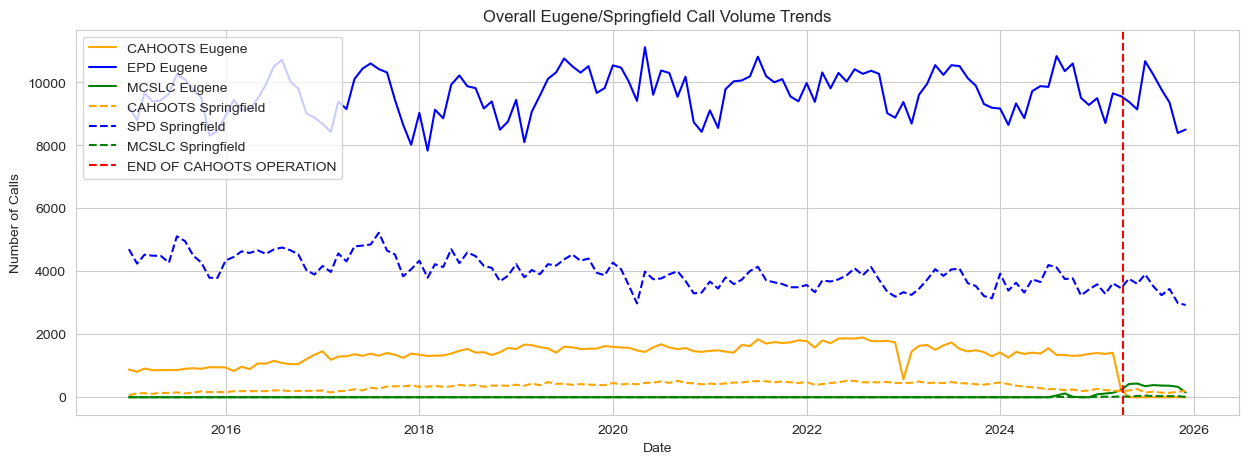

In [38]:
#ALL RAW CALL VOLUME DATA

plt.figure(figsize=(15,5))

#Eugene Data
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "CH_EUG_CALLS", label = "CAHOOTS Eugene", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "EPD_CALLS", label = "EPD Eugene", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "MCSLC_EUG_CALLS", label = "MCSLC Eugene", color = "green")

#Springfield Data
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "CH_SPR_CALLS", label = "CAHOOTS Springfield", linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "SPD_CALLS", label = "SPD Springfield", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "MCSLC_SPR_CALLS", label = "MCSLC Springfield", linestyle = "--", color = "green")

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

plt.title("Overall Eugene/Springfield Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.legend(loc = "upper left")

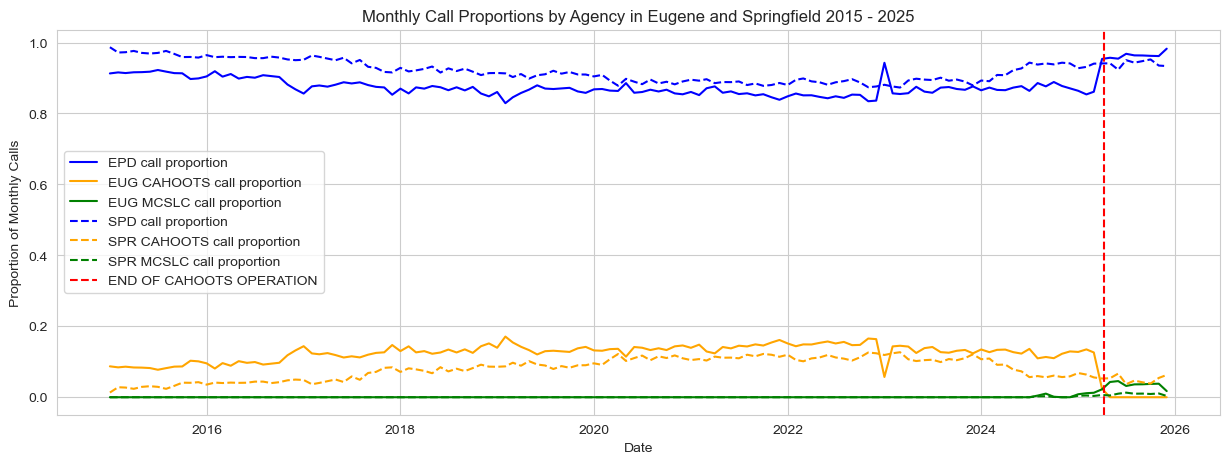

In [39]:
#OVERALL CALL PROPORTIONS

plt.figure(figsize=(15,5))

#Eugene
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_EPD", label = "EPD call proportion", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_CAHOOTS_EUG", label = "EUG CAHOOTS call proportion", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_MCSLC_EUG", label = "EUG MCSLC call proportion", color = 'green')


#Springfield
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_SPD", label = "SPD call proportion", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_CAHOOTS_SPR", label = "SPR CAHOOTS call proportion",linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_MCSLC_SPR", label = "SPR MCSLC call proportion", linestyle = "--", color = 'green')

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

plt.title("Monthly Call Proportions by Agency in Eugene and Springfield 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
plt.legend()

### TOTAL EUGENE CALL VOLUMES AND PROPORTIONS

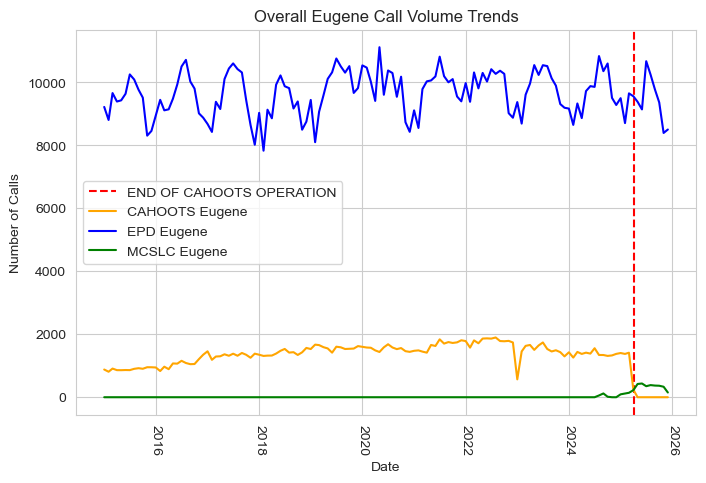

In [40]:
#Overall Eugene Call Volume Trends

plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "CH_EUG_CALLS", label = "CAHOOTS Eugene", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "EPD_CALLS", label = "EPD Eugene", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "MCSLC_EUG_CALLS", label = "MCSLC Eugene", color = "green")
plt.title("Overall Eugene Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")

plt.xticks(rotation = -90);

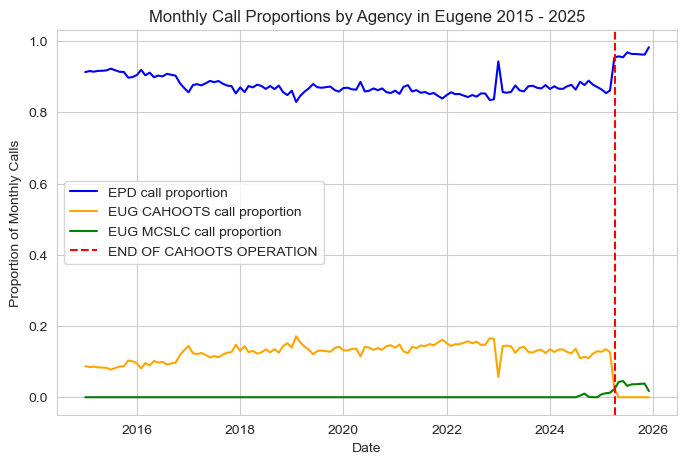

In [41]:
plt.figure(figsize=(8,5))

#Eugene
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_EPD", label = "EPD call proportion", color = 'blue')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_CAHOOTS_EUG", label = "EUG CAHOOTS call proportion", color = 'orange')
sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date",  y = "PROP_MCSLC_EUG", label = "EUG MCSLC call proportion", color = 'green')

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

plt.title("Monthly Call Proportions by Agency in Eugene 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
plt.legend()

### TOTAL SPRINGFIELD CALL VOLUMES AND PROPORTIONS

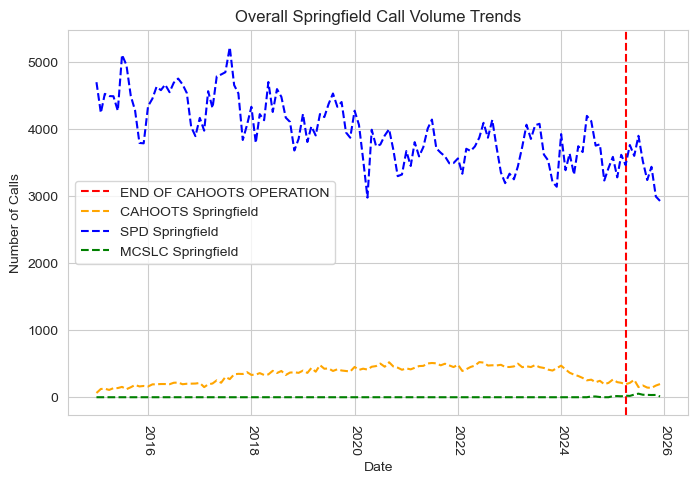

In [42]:
#Overall Springfield Call Volume Trends

plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "CH_SPR_CALLS", label = "CAHOOTS Springfield", linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "SPD_CALLS", label = "SPD Springfield", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "MCSLC_SPR_CALLS", label = "MCSLC Springfield", linestyle = "--", color = "green")
plt.title("Overall Springfield Call Volume Trends")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation = -90);

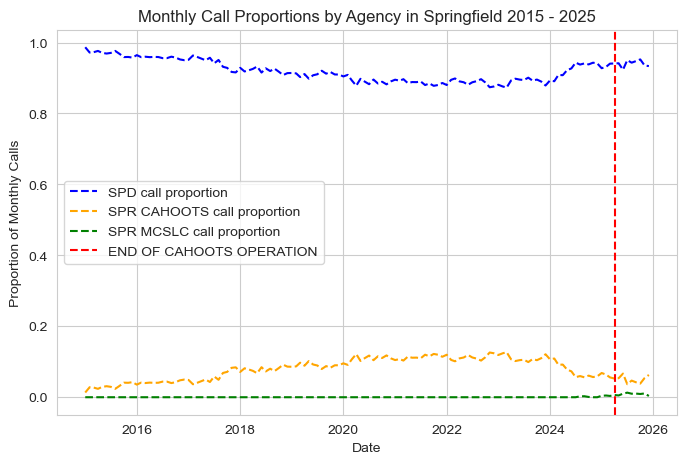

In [43]:
#Springfield

plt.figure(figsize=(8,5))

sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_SPD", label = "SPD call proportion", linestyle = "--", color = 'blue')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_CAHOOTS_SPR", label = "SPR CAHOOTS call proportion",linestyle = "--", color = 'orange')
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date",  y = "PROP_MCSLC_SPR", label = "SPR MCSLC call proportion", linestyle = "--", color = 'green')

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

plt.title("Monthly Call Proportions by Agency in Springfield 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
plt.legend()

---

### AGENCY SPECIFIC CALL VOLUMES AND PROPORTIONS

Text(0, 0.5, 'Number of Calls')

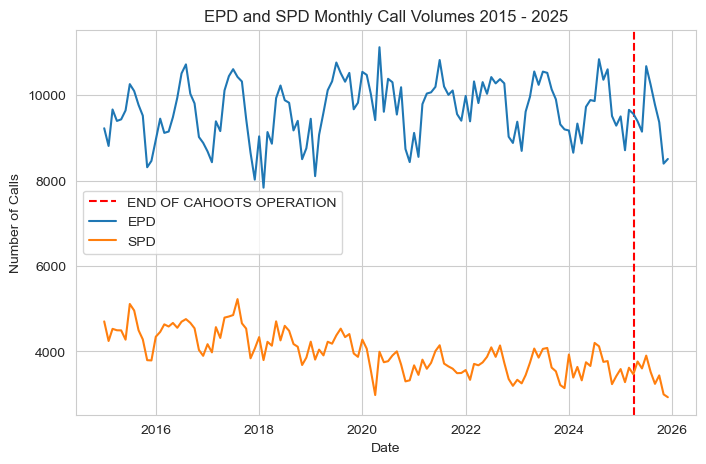

In [44]:
#EPD vs SPD trends

plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

#sns.lineplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 1, 1)], x = "Date", y = "EPD_CALLS", label = "EPD")
#sns.lineplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 1, 1)], x = "Date", y = "SPD_CALLS", label = "SPD")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "EPD_CALLS", label = "EPD")
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "SPD_CALLS", label = "SPD")

plt.title("EPD and SPD Monthly Call Volumes 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
#plt.xticks(rotation = -90);

Text(0, 0.5, 'Proportion of Monthly Calls')

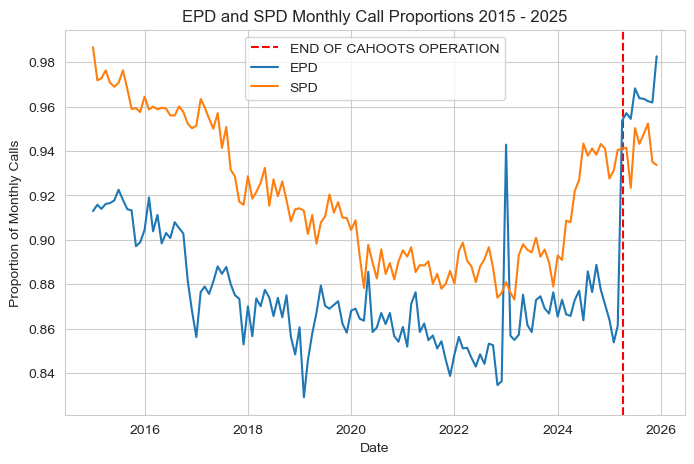

In [45]:
#EPD and SPD Call Proportions
plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "PROP_EPD", label = "EPD")
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "PROP_SPD", label = "SPD")

plt.title("EPD and SPD Monthly Call Proportions 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
#plt.xticks(rotation = -90);


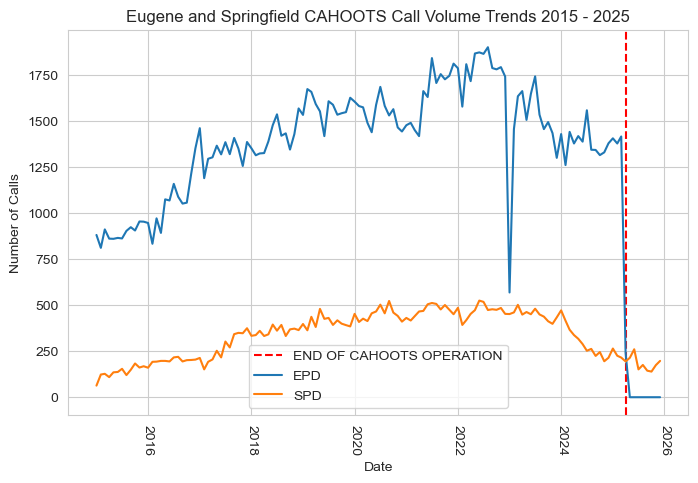

In [46]:
#Eugene vs Springfield CAHOOTS Call Volume Trends

plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "CH_EUG_CALLS", label = "EPD")
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "CH_SPR_CALLS", label = "SPD")

plt.title("Eugene and Springfield CAHOOTS Call Volume Trends 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.xticks(rotation=-90);

Text(0, 0.5, 'Proportion of Monthly Calls')

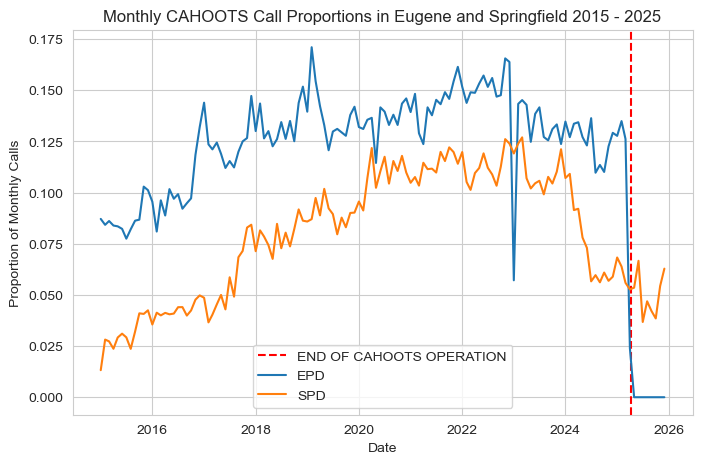

In [47]:
#Eugene and Springfield CAHOOTS Call Proportions
plt.figure(figsize=(8,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.lineplot(data = TOTAL_EUG_VOLUME, x = "Date", y = "PROP_CAHOOTS_EUG", label = "EPD")
sns.lineplot(data = TOTAL_SPR_VOLUME, x = "Date", y = "PROP_CAHOOTS_SPR", label = "SPD")

plt.title("Monthly CAHOOTS Call Proportions in Eugene and Springfield 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
#plt.xticks(rotation = -90);

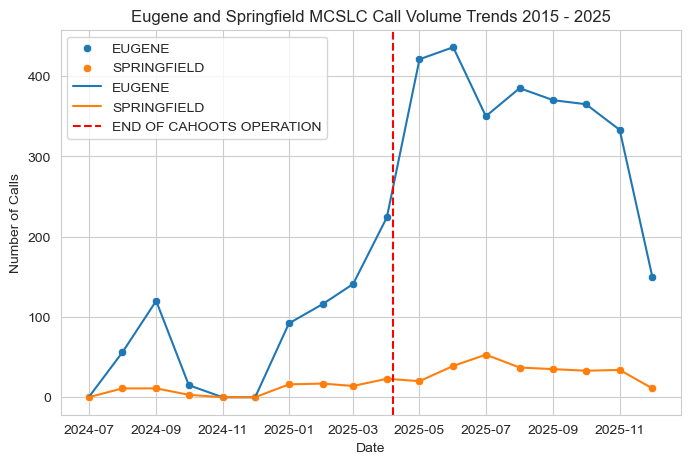

In [48]:
#Eugene vs Springfield MCSLC Call Volume Trends
plt.figure(figsize=(8,5))

sns.scatterplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "MCSLC_EUG_CALLS", label = "EUGENE")
sns.scatterplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "MCSLC_SPR_CALLS", label = "SPRINGFIELD")

sns.lineplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "MCSLC_EUG_CALLS", label = "EUGENE")
sns.lineplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "MCSLC_SPR_CALLS", label = "SPRINGFIELD")

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")



plt.title("Eugene and Springfield MCSLC Call Volume Trends 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Number of Calls")
plt.legend()
#plt.xticks(rotation=45);

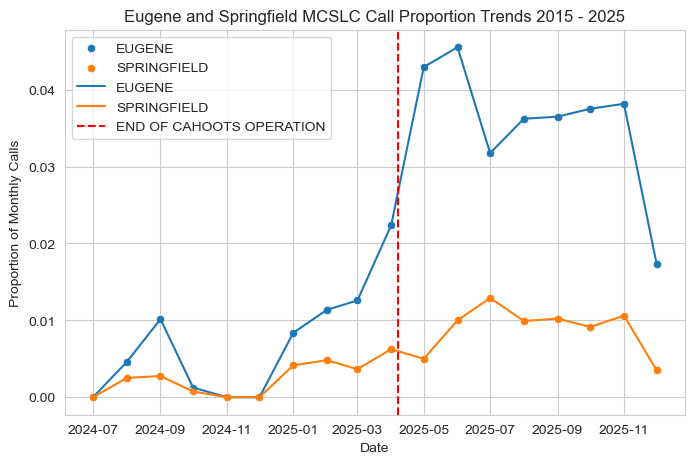

In [49]:
#Eugene vs Springfield MCSLC Call Volume Trends
plt.figure(figsize=(8,5))

sns.scatterplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "PROP_MCSLC_EUG", label = "EUGENE")
sns.scatterplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "PROP_MCSLC_SPR", label = "SPRINGFIELD")

sns.lineplot(data = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "PROP_MCSLC_EUG", label = "EUGENE")
sns.lineplot(data = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["Date"] > dt.datetime(2024, 6, 1)], x = "Date", y = "PROP_MCSLC_SPR", label = "SPRINGFIELD")

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")



plt.title("Eugene and Springfield MCSLC Call Proportion Trends 2015 - 2025")
plt.xlabel("Date")
plt.ylabel("Proportion of Monthly Calls")
plt.legend()
#plt.xticks(rotation=45);

# Call type Specific visualizations

---

## VOLUME

In [50]:
EPD_TYPES_VOLUME = EUG_TYPES_VOLUME[EUG_TYPES_VOLUME["agency"] == "EPD"]
SPD_TYPES_VOLUME =SPR_TYPES_VOLUME[SPR_TYPES_VOLUME["agency"] == "SPD"]

CAHOOTS_EUG_TYPES_VOLUME = EUG_TYPES_VOLUME[EUG_TYPES_VOLUME["agency"] == "CAHOOTS_EUG"]
CAHOOTS_SPR_TYPES_VOLUME =SPR_TYPES_VOLUME[SPR_TYPES_VOLUME["agency"] == "CAHOOTS_SPR"]

MCSLC_EUG_TYPES_VOLUME = EUG_TYPES_VOLUME[EUG_TYPES_VOLUME["agency"] == "MCSLC_EUG"]
MCSLC_SPR_TYPES_VOLUME = SPR_TYPES_VOLUME[SPR_TYPES_VOLUME["agency"] == "MCSLC_SPR"]

In [51]:
'''plt.figure(figsize=(10,5))

sns.lineplot(data = EUG_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'''

'plt.figure(figsize=(10,5))\n\nsns.lineplot(data = EUG_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'

In [52]:
'''plt.figure(figsize=(10,5))

sns.lineplot(data = SPR_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'''

'plt.figure(figsize=(10,5))\n\nsns.lineplot(data = SPR_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'

In [53]:
'''plt.figure(figsize=(10,5))

sns.lineplot(data = SPD_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'''

'plt.figure(figsize=(10,5))\n\nsns.lineplot(data = SPD_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'

In [54]:
'''plt.figure(figsize=(10,5))

sns.lineplot(data = EPD_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'''

'plt.figure(figsize=(10,5))\n\nsns.lineplot(data = EPD_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'

In [55]:
'''plt.figure(figsize=(10,5))

sns.lineplot(data = CAHOOTS_EUG_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'''

'plt.figure(figsize=(10,5))\n\nsns.lineplot(data = CAHOOTS_EUG_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'

In [56]:
'''plt.figure(figsize=(10,5))

sns.lineplot(data = CAHOOTS_SPR_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'''

'plt.figure(figsize=(10,5))\n\nsns.lineplot(data = CAHOOTS_SPR_TYPES_VOLUME, x = "Date", y = "calls", hue = "call type")'

---

In [57]:
'''for i in EPD_TYPES_VOLUME["call type"].unique():
    plt.figure(figsize=(10,5))
    plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")
    sns.lineplot(data = EPD_TYPES_VOLUME[EPD_TYPES_VOLUME["call type"] == i], x = "Date", y = "calls")
    sns.lineplot(data = SPD_TYPES_VOLUME[SPD_TYPES_VOLUME["call type"] == i], x = "Date", y = "calls")
    plt.title(i)'''

'for i in EPD_TYPES_VOLUME["call type"].unique():\n    plt.figure(figsize=(10,5))\n    plt.axvline(dt.datetime(2025, 4, 7), color = \'red\', linestyle = "--", label = "END OF CAHOOTS OPERATION")\n    sns.lineplot(data = EPD_TYPES_VOLUME[EPD_TYPES_VOLUME["call type"] == i], x = "Date", y = "calls")\n    sns.lineplot(data = SPD_TYPES_VOLUME[SPD_TYPES_VOLUME["call type"] == i], x = "Date", y = "calls")\n    plt.title(i)'

In [58]:
'''#CAHOOTS CALL TYPE VOLUME

for i in CAHOOTS_EUG_TYPES_VOLUME["call type"].unique():
    plt.figure(figsize=(10,5))
    plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")
    sns.lineplot(data = CAHOOTS_EUG_TYPES_VOLUME[CAHOOTS_EUG_TYPES_VOLUME["call type"] == i], x = "Date", y = "calls")
    sns.lineplot(data = CAHOOTS_SPR_TYPES_VOLUME[CAHOOTS_SPR_TYPES_VOLUME["call type"] == i], x = "Date", y = "calls")
    plt.title(i)'''

'#CAHOOTS CALL TYPE VOLUME\n\nfor i in CAHOOTS_EUG_TYPES_VOLUME["call type"].unique():\n    plt.figure(figsize=(10,5))\n    plt.axvline(dt.datetime(2025, 4, 7), color = \'red\', linestyle = "--", label = "END OF CAHOOTS OPERATION")\n    sns.lineplot(data = CAHOOTS_EUG_TYPES_VOLUME[CAHOOTS_EUG_TYPES_VOLUME["call type"] == i], x = "Date", y = "calls")\n    sns.lineplot(data = CAHOOTS_SPR_TYPES_VOLUME[CAHOOTS_SPR_TYPES_VOLUME["call type"] == i], x = "Date", y = "calls")\n    plt.title(i)'

---

## Proportion

In [210]:
EUG_SPR_TYPES_PROP = EUG_SPR_TYPES_VOLUME.pivot_table(index = ["Date", "call type", "treated"], columns = ["agency"], values = ["calls"], aggfunc='sum').fillna(0)
EUG_SPR_TYPES_PROP

calls                      \
agency                                 CAHOOTS_EUG CAHOOTS_SPR     EPD   
Date       call type           treated                                   
2015-01-01 ASSIST PUBLIC       0               0.0         6.0     0.0   
                               1             262.0         0.0   167.0   
           CHECK WELFARE       0               0.0        24.0     0.0   
                               1             138.0         0.0   191.0   
           INTOXICATED SUBJECT 0               0.0         3.0     0.0   
...                                            ...         ...     ...   
2025-12-01 OTHER               1               0.0         0.0  7843.0   
           SUICIDAL SUBJECT    0               0.0         7.0     0.0   
                               1               0.0         0.0    89.0   
           TRANSPORT           0               0.0         1.0     0.0   
                               1               0.0         0.0     7.0   

                                                                  
agency                                 MCSLC_EUG MCSLC_SPR   SPD  
Date       call type           treated                            
2015-01-01 ASSIST PUBLIC       0             0.0       0.0  10.0  
                               1             0.0       0.0   0.0  
           CHECK WELFARE       0             0.0       0.0  95.0  
                               1             0.0       0.0   0.0  
           INTOXICATED SUBJECT 0             0.0       0.0  13.0  
...                                          ...       ...   ...  
2025-12-01 OTHER               1           138.0       0.0   0.0  
           SUICIDAL SUBJECT    0             0.0       1.0  21.0  
                               1            11.0       0.0   0.0  
           TRANSPORT           0             0.0       0.0  13.0  
                               1             0.0       0.0   0.0  

[1584 rows x 6 columns]

In [211]:
all_epd = EUG_SPR_TYPES_PROP["calls"]["EPD"]
all_spd = EUG_SPR_TYPES_PROP["calls"]["SPD"]
all_cahoots_eug = EUG_SPR_TYPES_PROP["calls"]["CAHOOTS_EUG"]
all_cahoots_spr = EUG_SPR_TYPES_PROP["calls"]["CAHOOTS_SPR"]
all_mcslc_eug = EUG_SPR_TYPES_PROP["calls"]["MCSLC_EUG"]
all_mcslc_spr = EUG_SPR_TYPES_PROP["calls"]["MCSLC_SPR"]

EUG_SPR_TYPES_PROP["CAHOOTS_EUG_PROP"] = all_cahoots_eug / (all_epd + all_cahoots_eug + all_mcslc_eug)
EUG_SPR_TYPES_PROP["CAHOOTS_SPR_PROP"] = all_cahoots_spr / (all_spd + all_cahoots_spr + all_mcslc_spr)
EUG_SPR_TYPES_PROP["EPD_PROP"] = all_epd / (all_epd + all_cahoots_eug + all_mcslc_eug)
EUG_SPR_TYPES_PROP["SPD_PROP"] = all_spd / (all_spd + all_cahoots_spr + all_mcslc_spr)
EUG_SPR_TYPES_PROP["MCSLC_EUG_PROP"] = all_mcslc_eug / (all_epd + all_cahoots_eug + all_mcslc_eug)
EUG_SPR_TYPES_PROP["MCSLC_SPR_PROP"] = all_mcslc_spr / (all_spd + all_cahoots_spr + all_mcslc_spr)


EUG_SPR_TYPES_PROP

calls                      \
agency                                 CAHOOTS_EUG CAHOOTS_SPR     EPD   
Date       call type           treated                                   
2015-01-01 ASSIST PUBLIC       0               0.0         6.0     0.0   
                               1             262.0         0.0   167.0   
           CHECK WELFARE       0               0.0        24.0     0.0   
                               1             138.0         0.0   191.0   
           INTOXICATED SUBJECT 0               0.0         3.0     0.0   
...                                            ...         ...     ...   
2025-12-01 OTHER               1               0.0         0.0  7843.0   
           SUICIDAL SUBJECT    0               0.0         7.0     0.0   
                               1               0.0         0.0    89.0   
           TRANSPORT           0               0.0         1.0     0.0   
                               1               0.0         0.0     7.0   

                                                                  \
agency                                 MCSLC_EUG MCSLC_SPR   SPD   
Date       call type           treated                             
2015-01-01 ASSIST PUBLIC       0             0.0       0.0  10.0   
                               1             0.0       0.0   0.0   
           CHECK WELFARE       0             0.0       0.0  95.0   
                               1             0.0       0.0   0.0   
           INTOXICATED SUBJECT 0             0.0       0.0  13.0   
...                                          ...       ...   ...   
2025-12-01 OTHER               1           138.0       0.0   0.0   
           SUICIDAL SUBJECT    0             0.0       1.0  21.0   
                               1            11.0       0.0   0.0   
           TRANSPORT           0             0.0       0.0  13.0   
                               1             0.0       0.0   0.0   

                                       CAHOOTS_EUG_PROP CAHOOTS_SPR_PROP  \
agency                                                                     
Date       call type           treated                                     
2015-01-01 ASSIST PUBLIC       0                    NaN         0.375000   
                               1               0.610723              NaN   
           CHECK WELFARE       0                    NaN         0.201681   
                               1               0.419453              NaN   
           INTOXICATED SUBJECT 0                    NaN         0.187500   
...                                                 ...              ...   
2025-12-01 OTHER               1               0.000000              NaN   
           SUICIDAL SUBJECT    0                    NaN         0.241379   
                               1               0.000000              NaN   
           TRANSPORT           0                    NaN         0.071429   
                               1               0.000000              NaN   

                                        EPD_PROP  SPD_PROP MCSLC_EUG_PROP  \
agency                                                                      
Date       call type           treated                                      
2015-01-01 ASSIST PUBLIC       0             NaN  0.625000            NaN   
                               1        0.389277       NaN       0.000000   
           CHECK WELFARE       0             NaN  0.798319            NaN   
                               1        0.580547       NaN       0.000000   
           INTOXICATED SUBJECT 0             NaN  0.812500            NaN   
...                                          ...       ...            ...   
2025-12-01 OTHER               1        0.982709       NaN       0.017291   
           SUICIDAL SUBJECT    0             NaN  0.724138            NaN   
                               1        0.890000       NaN       0.110000   
           TRANSPORT           0             NaN  0.928571        

In [212]:
EUG_SPR_TYPES_PROP['EPD_PROP'].reset_index()["call type"].unique()

array(['ASSIST PUBLIC', 'CHECK WELFARE', 'INTOXICATED SUBJECT', 'OTHER',
       'SUICIDAL SUBJECT', 'TRANSPORT'], dtype=object)

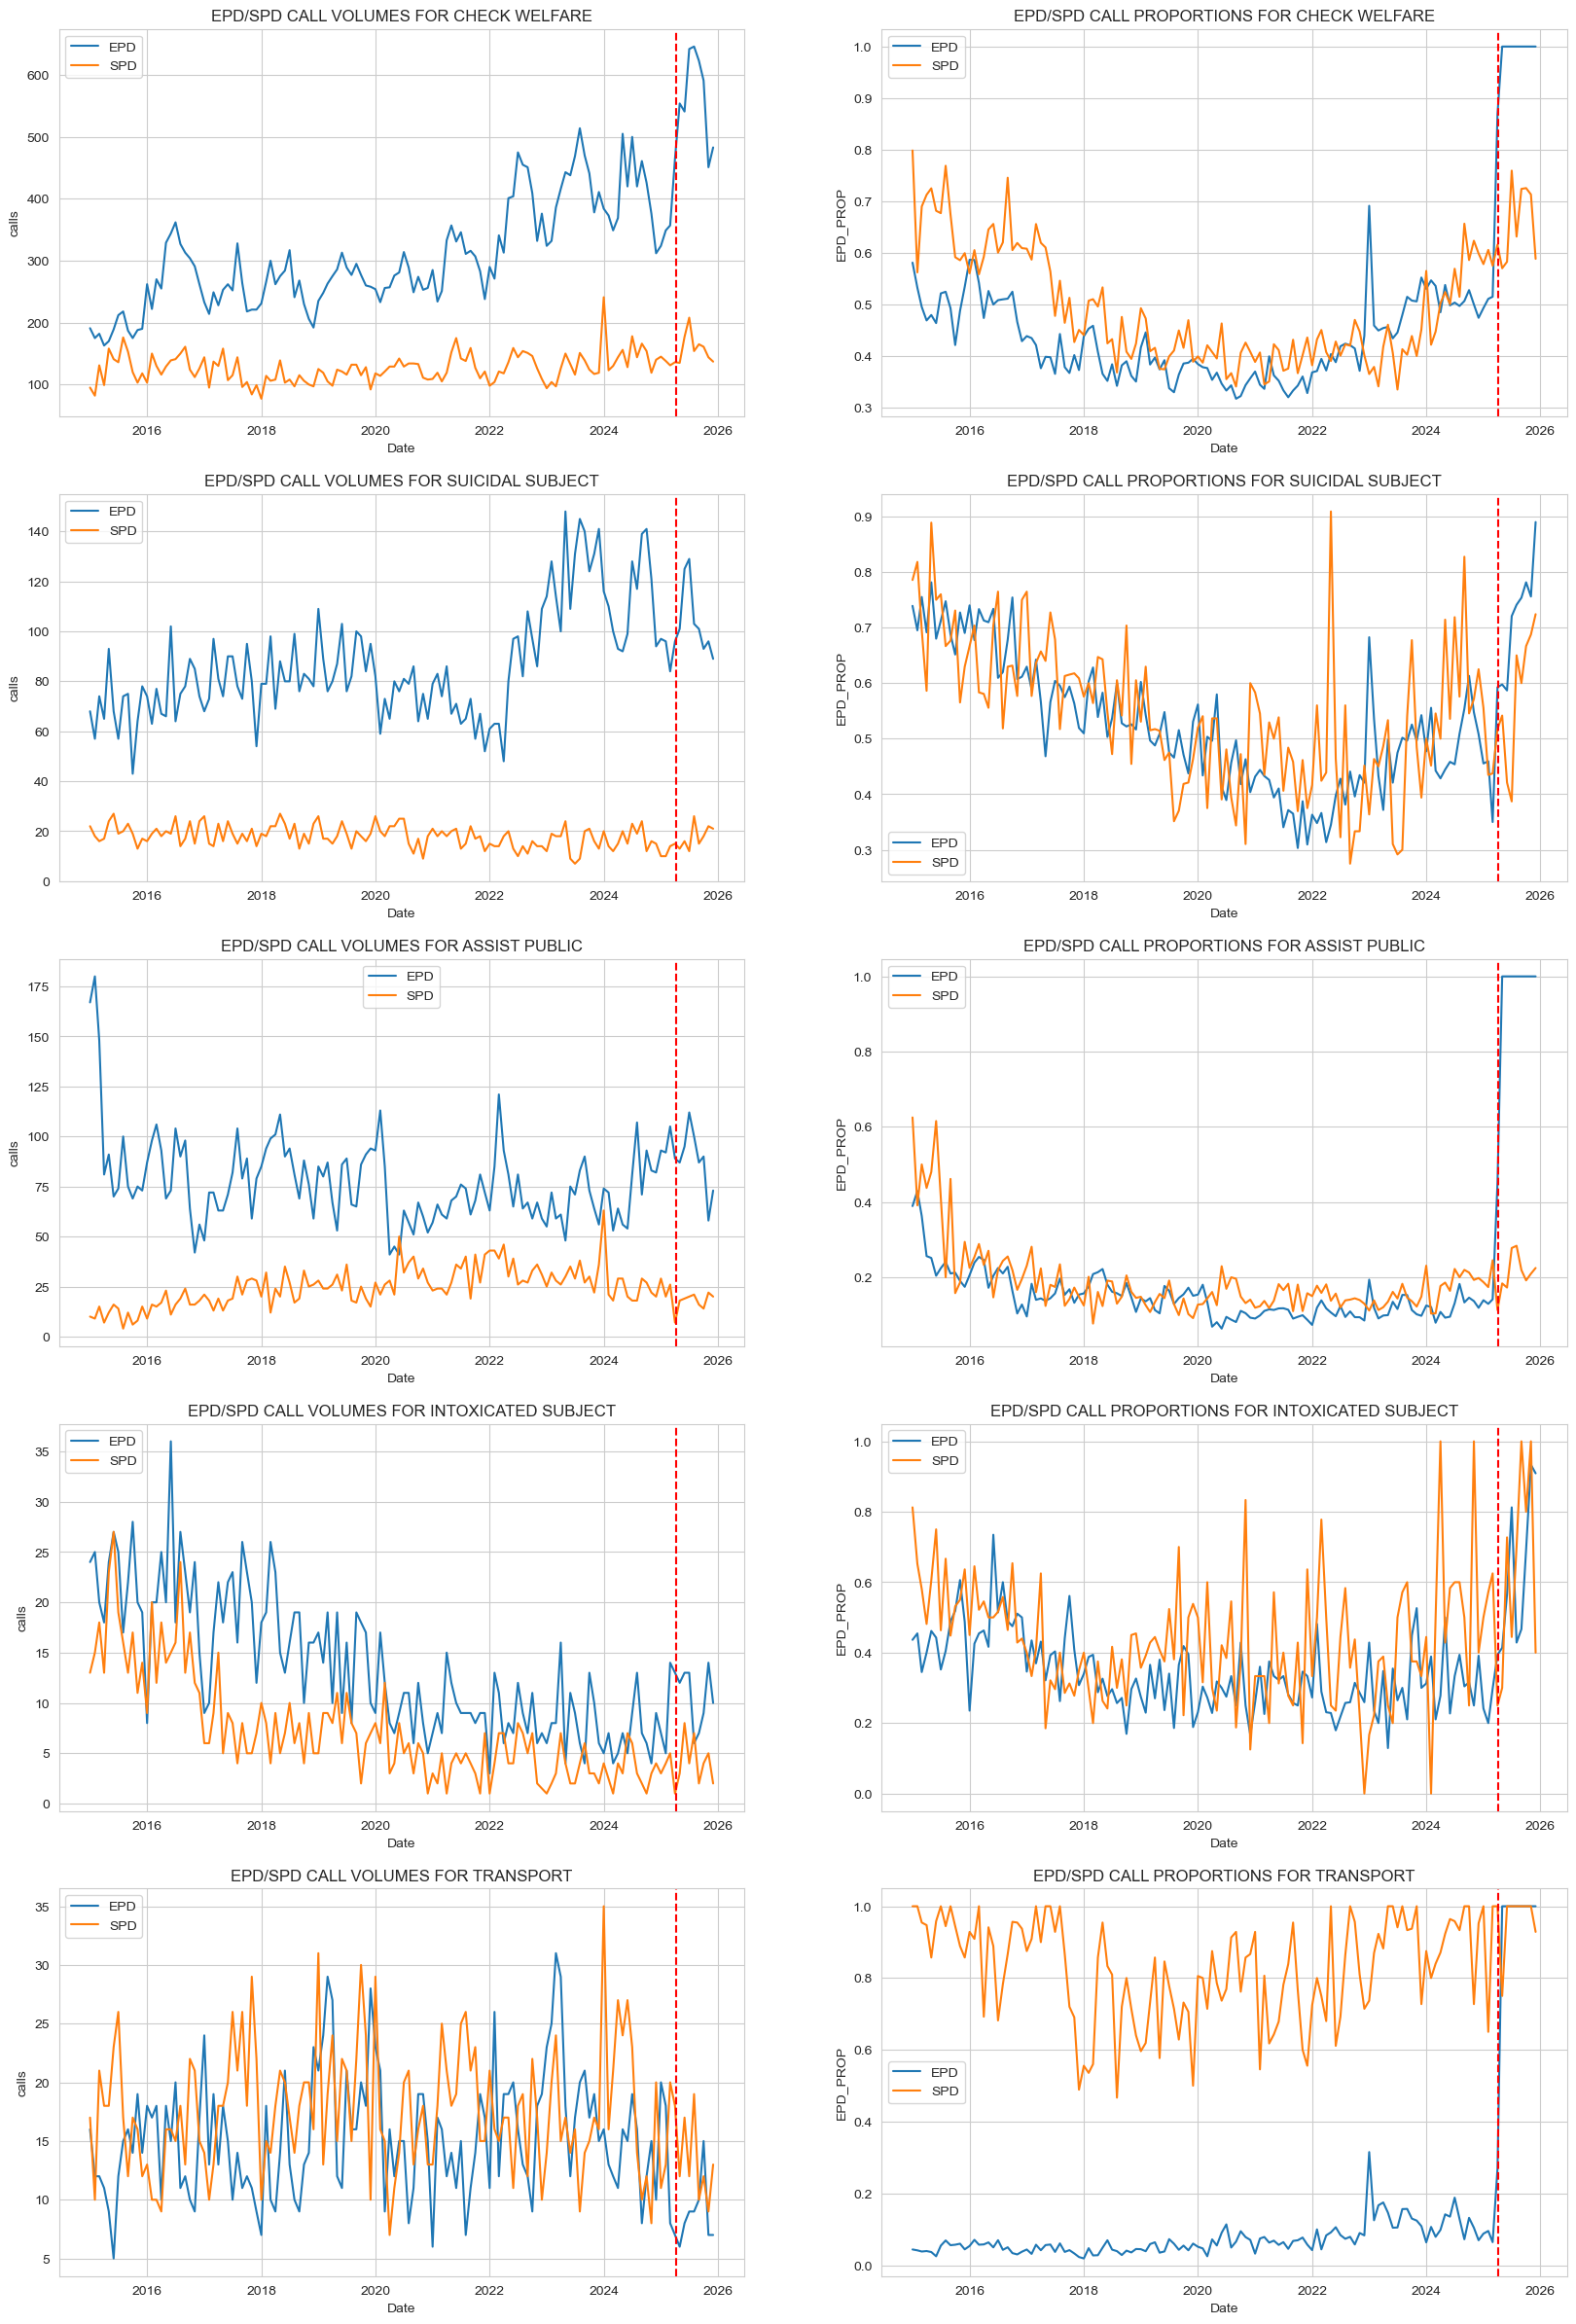

In [213]:
#EPD/SPD CALL TYPE VOLUMES AND_PROPORTIONS

fig, axes = plt.subplots(5, 2, figsize=(20, 30))

temp_eug = EUG_SPR_TYPES_PROP['EPD_PROP'].reset_index()
temp_spr = EUG_SPR_TYPES_PROP['SPD_PROP'].reset_index()

variables = np.array(["CHECK WELFARE", "SUICIDAL SUBJECT", "ASSIST PUBLIC", "INTOXICATED SUBJECT", "TRANSPORT"])

for i in range(len(variables)):
    var = variables[i]
    sns.lineplot(data = EPD_TYPES_VOLUME[EPD_TYPES_VOLUME["call type"] == var], x = "Date", y = "calls", label = "EPD", ax=axes[i,0])
    sns.lineplot(data = SPD_TYPES_VOLUME[SPD_TYPES_VOLUME["call type"] == var], x = "Date", y = "calls", label = "SPD", ax=axes[i,0])
    axes[i, 0].set_title(f"EPD/SPD CALL VOLUMES FOR {var}")
    axes[i, 0].axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

for i in range(len(variables)):
    var = variables[i]
    sns.lineplot(data = temp_eug[temp_eug["call type"] == var], x = "Date", y = "EPD_PROP", label = "EPD", ax=axes[i,1])
    sns.lineplot(data = temp_spr[temp_spr["call type"] == var], x = "Date", y = "SPD_PROP", label = "SPD", ax=axes[i,1])
    axes[i, 1].set_title(f"EPD/SPD CALL PROPORTIONS FOR {var}")
    axes[i, 1].axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")



## MCSLC

In [214]:
EUG_SPR_TYPES_PROP.head()

calls                     \
agency                                 CAHOOTS_EUG CAHOOTS_SPR    EPD   
Date       call type           treated                                  
2015-01-01 ASSIST PUBLIC       0               0.0         6.0    0.0   
                               1             262.0         0.0  167.0   
           CHECK WELFARE       0               0.0        24.0    0.0   
                               1             138.0         0.0  191.0   
           INTOXICATED SUBJECT 0               0.0         3.0    0.0   

                                                                  \
agency                                 MCSLC_EUG MCSLC_SPR   SPD   
Date       call type           treated                             
2015-01-01 ASSIST PUBLIC       0             0.0       0.0  10.0   
                               1             0.0       0.0   0.0   
           CHECK WELFARE       0             0.0       0.0  95.0   
                               1             0.0       0.0   0.0   
           INTOXICATED SUBJECT 0             0.0       0.0  13.0   

                                       CAHOOTS_EUG_PROP CAHOOTS_SPR_PROP  \
agency                                                                     
Date       call type           treated                                     
2015-01-01 ASSIST PUBLIC       0                    NaN         0.375000   
                               1               0.610723              NaN   
           CHECK WELFARE       0                    NaN         0.201681   
                               1               0.419453              NaN   
           INTOXICATED SUBJECT 0                    NaN         0.187500   

                                        EPD_PROP  SPD_PROP MCSLC_EUG_PROP  \
agency                                                                      
Date       call type           treated                                      
2015-01-01 ASSIST PUBLIC       0             NaN  0.625000            NaN   
                               1        0.389277       NaN            0.0   
           CHECK WELFARE       0             NaN  0.798319            NaN   
                               1        0.580547       NaN            0.0   
           INTOXICATED SUBJECT 0             NaN  0.812500            NaN   

                                       MCSLC_SPR_PROP  
agency                                                 
Date       call type           treated                 
2015-01-01 ASSIST PUBLIC       0                  0.0  
                               1                  NaN  
           CHECK WELFARE       0                  0.0  
                               1                  NaN  
           INTOXICATED SUBJECT 0                  0.0

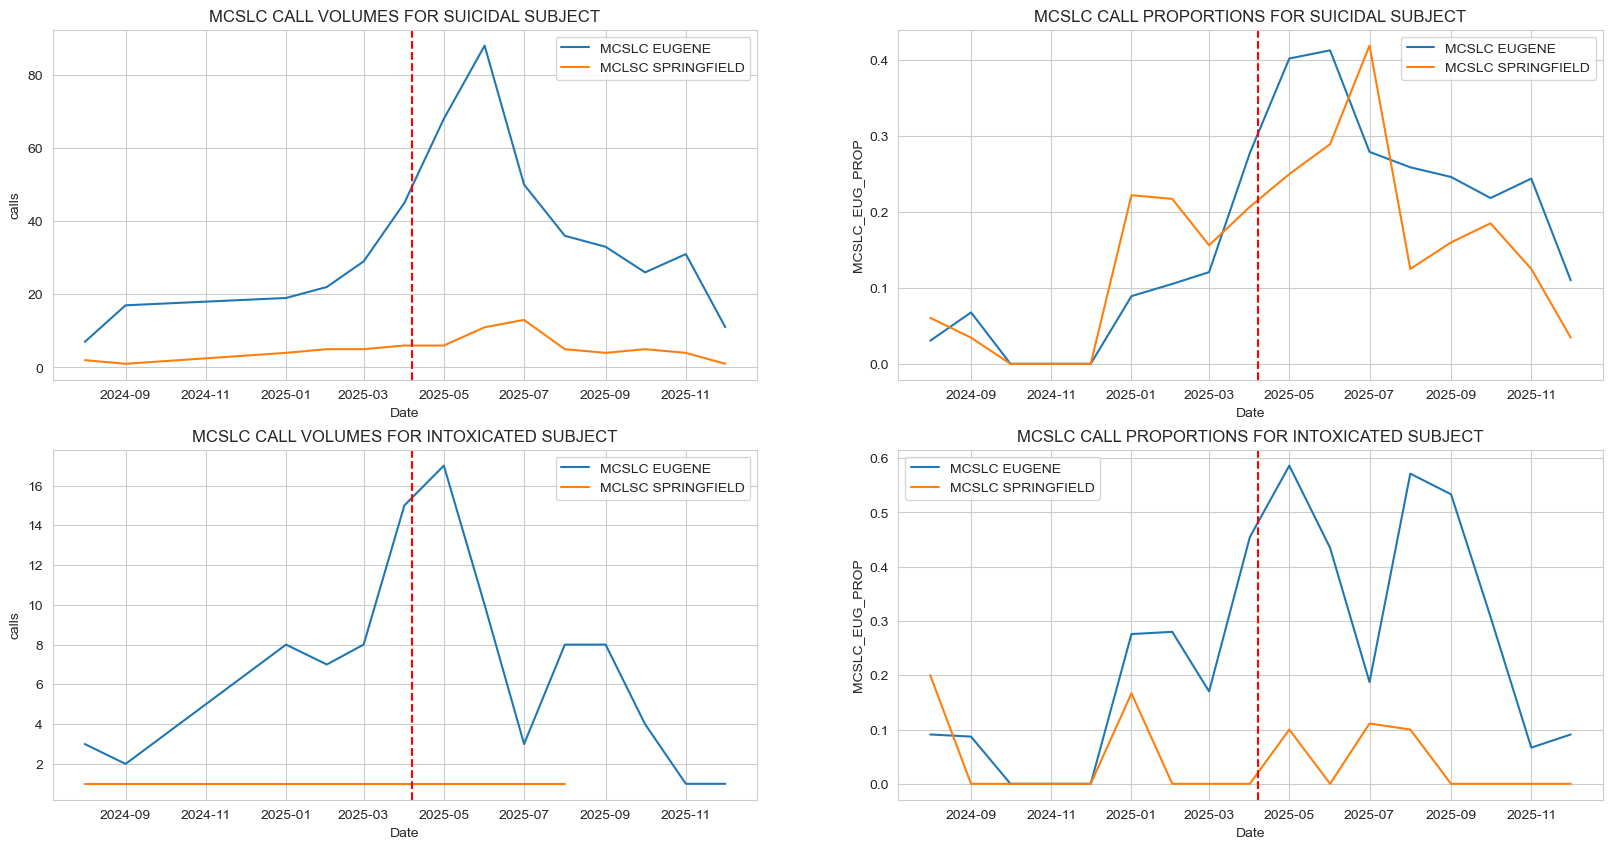

In [215]:
#MCSLC CALL TYPE VOLUMES AND_PROPORTIONS

fig, axes = plt.subplots(2, 2, figsize=(20, 10))

temp_eug = EUG_SPR_TYPES_PROP['MCSLC_EUG_PROP'].reset_index()
temp_spr = EUG_SPR_TYPES_PROP['MCSLC_SPR_PROP'].reset_index()

temp_eug = temp_eug[temp_eug["Date"] > dt.datetime(2024,7,1)]
temp_spr = temp_spr[temp_spr["Date"] > dt.datetime(2024,7,1)]

variables = np.array(["SUICIDAL SUBJECT", "INTOXICATED SUBJECT"])

for i in range(len(variables)):
    var = variables[i]
    sns.lineplot(data = MCSLC_EUG_TYPES_VOLUME[MCSLC_EUG_TYPES_VOLUME["call type"] == var], x = "Date", y = "calls", label = "MCSLC EUGENE", ax=axes[i,0])
    sns.lineplot(data = MCSLC_SPR_TYPES_VOLUME[MCSLC_SPR_TYPES_VOLUME["call type"] == var], x = "Date", y = "calls", label = "MCLSC SPRINGFIELD", ax=axes[i,0])
    axes[i, 0].set_title(f"MCSLC CALL VOLUMES FOR {var}")
    axes[i, 0].axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

for i in range(len(variables)):
    var = variables[i]
    sns.lineplot(data = temp_eug[temp_eug["call type"] == var], x = "Date", y = "MCSLC_EUG_PROP", label = "MCSLC EUGENE", ax=axes[i,1])
    sns.lineplot(data = temp_spr[temp_spr["call type"] == var], x = "Date", y = "MCSLC_SPR_PROP", label = "MCSLC SPRINGFIELD", ax=axes[i,1])
    axes[i, 1].set_title(f"MCSLC CALL PROPORTIONS FOR {var}")
    axes[i, 1].axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

---

# DiD ANALYSIS

In [216]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [217]:
def fit_model(y, x, summary = False):
    y_val = y
    X_val = sm.add_constant(x)

    model = sm.OLS(y_val, X_val).fit()

    if summary == True:
        print(model.summary())
    return model

def fit_DID(df, summary = False):
    model = smf.ols(
        "value ~ treated + post + treated:post",
         data = df
    ).fit()
    if summary == True:
        print(model.summary())
    return model

In [218]:
#Converting dates to numeric variables

import matplotlib.dates as mdates
TOTAL_EUG_VOLUME["Date_numeric"] = mdates.date2num(TOTAL_EUG_VOLUME["Date"])
TOTAL_SPR_VOLUME["Date_numeric"] = mdates.date2num(TOTAL_SPR_VOLUME["Date"])


In [219]:
#segmenting data by pre and post CAHOOTS closure
TOTAL_EUG_VOLUME["post"] = (TOTAL_EUG_VOLUME["Date"] > CAHOOTS_closure).astype(int)
TOTAL_EUG_VOLUME["treated"] = 1
TOTAL_SPR_VOLUME["post"] = (TOTAL_SPR_VOLUME["Date"] > CAHOOTS_closure).astype(int)
TOTAL_SPR_VOLUME["treated"] = 0

EUG_VOLUME_PRE = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["post"] == True]
EUG_VOLUME_POST = TOTAL_EUG_VOLUME[TOTAL_EUG_VOLUME["post"] == False]

SPR_VOLUME_PRE = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["post"] == True]
SPR_VOLUME_POST = TOTAL_SPR_VOLUME[TOTAL_SPR_VOLUME["post"] == False]

In [220]:
TOTAL_EUG_VOLUME_tidy = TOTAL_EUG_VOLUME.melt(id_vars = ["Date", "Date_numeric", "post", "treated"], value_vars = ["EPD_CALLS", "MCSLC_EUG_CALLS", "CH_EUG_CALLS"])
TOTAL_SPR_VOLUME_tidy = TOTAL_SPR_VOLUME.melt(id_vars = ["Date", "Date_numeric", "post", "treated"], value_vars = ["SPD_CALLS", "MCSLC_SPR_CALLS", "CH_SPR_CALLS"])


TOTAL_EUG_PROP_tidy = TOTAL_EUG_VOLUME.melt(id_vars = ["Date", "Date_numeric", "post", "treated"], value_vars = ["PROP_EPD", "PROP_CAHOOTS_EUG", "PROP_MCSLC_EUG"])
TOTAL_SPR_PROP_tidy = TOTAL_SPR_VOLUME.melt(id_vars = ["Date", "Date_numeric", "post", "treated"], value_vars = ["PROP_SPD", "PROP_CAHOOTS_SPR", "PROP_MCSLC_SPR"])

In [221]:
TOTAL_EUG_SPR_PROP = pd.concat([TOTAL_EUG_PROP_tidy, TOTAL_SPR_PROP_tidy])
#TOTAL_EUG_SPR_PROP

In [222]:
TOTAL_EUG_SPR_VOLUME = pd.concat([TOTAL_EUG_VOLUME_tidy, TOTAL_SPR_VOLUME_tidy])
#TOTAL_EUG_SPR_VOLUME

In [223]:
EPD_SPD_VOLUME = TOTAL_EUG_SPR_VOLUME[TOTAL_EUG_SPR_VOLUME["variable"].isin(["EPD_CALLS", "SPD_CALLS"])]
EPD_SPD_VOLUME

,Date,Date_numeric,post,treated,variable,value
0,2015-01-01,16436.0,0,1,EPD_CALLS,9223.0
1,2015-02-01,16467.0,0,1,EPD_CALLS,8809.0
2,2015-03-01,16495.0,0,1,EPD_CALLS,9663.0
3,2015-04-01,16526.0,0,1,EPD_CALLS,9395.0
4,2015-05-01,16556.0,0,1,EPD_CALLS,9432.0
...,...,...,...,...,...,...
127,2025-08-01,20301.0,1,0,SPD_CALLS,3523.0
128,2025-09-01,20332.0,1,0,SPD_CALLS,3242.0
129,2025-10-01,20362.0,1,0,SPD_CALLS,3440.0
130,2025-11-01,20393.0,1,0,SPD_CALLS,2996.0


In [224]:
#pre closure pd regression

EPD_VOLUME_PRE = EPD_SPD_VOLUME[EPD_SPD_VOLUME["treated"] == 1]
EPD_VOLUME_PRE = EPD_VOLUME_PRE[EPD_VOLUME_PRE["post"] == 0]

EPD_VOLUME_POST = EPD_SPD_VOLUME[EPD_SPD_VOLUME["treated"] == 1]
EPD_VOLUME_POST = EPD_VOLUME_POST[EPD_VOLUME_POST["post"] == 1]

SPD_VOLUME_PRE = EPD_SPD_VOLUME[EPD_SPD_VOLUME["treated"] == 0]
SPD_VOL_PRE = SPD_VOLUME_PRE[SPD_VOLUME_PRE["post"] == 0]

SPD_VOLUME_POST = EPD_SPD_VOLUME[EPD_SPD_VOLUME["treated"] == 0]
SPD_VOLUME_POST = SPD_VOLUME_POST[SPD_VOLUME_POST["post"] == 1]

In [225]:
#VOLUME REGRESSION MODELS
Model_EPD_PRE = fit_model(EPD_VOLUME_PRE["value"], EPD_VOLUME_PRE["Date_numeric"])
EPD_VOLUME_PRE["prediction"] = Model_EPD_PRE.predict()

Model_EPD_POST = fit_model(EPD_VOLUME_POST["value"], EPD_VOLUME_POST["Date_numeric"])
EPD_VOLUME_POST["prediction"] = Model_EPD_POST.predict()

Model_SPD_PRE = fit_model(SPD_VOLUME_PRE["value"], SPD_VOLUME_PRE["Date_numeric"])
SPD_VOLUME_PRE["prediction"] = Model_SPD_PRE.predict()

Model_SPD_POST = fit_model(SPD_VOLUME_POST["value"], SPD_VOLUME_POST["Date_numeric"])
SPD_VOLUME_POST["prediction"] = Model_SPD_POST.predict()

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/3624998873.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  SPD_VOLUME_PRE["prediction"] = Model_SPD_PRE.predict()


In [226]:
model_pd_vol = fit_DID(EPD_SPD_VOLUME, summary=True)
EPD_SPD_VOLUME["prediction"] = model_pd_vol.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.959
Model:                            OLS   Adj. R-squared:                  0.959
Method:                 Least Squares   F-statistic:                     2029.
Date:                Fri, 29 May 2026   Prob (F-statistic):          5.17e-180
Time:                        10:50:54   Log-Likelihood:                -2057.7
No. Observations:                 264   AIC:                             4123.
Df Residuals:                     260   BIC:                             4138.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     3999.0000     53.133     75.264   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/4239110583.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_VOLUME["prediction"] = model_pd_vol.predict()


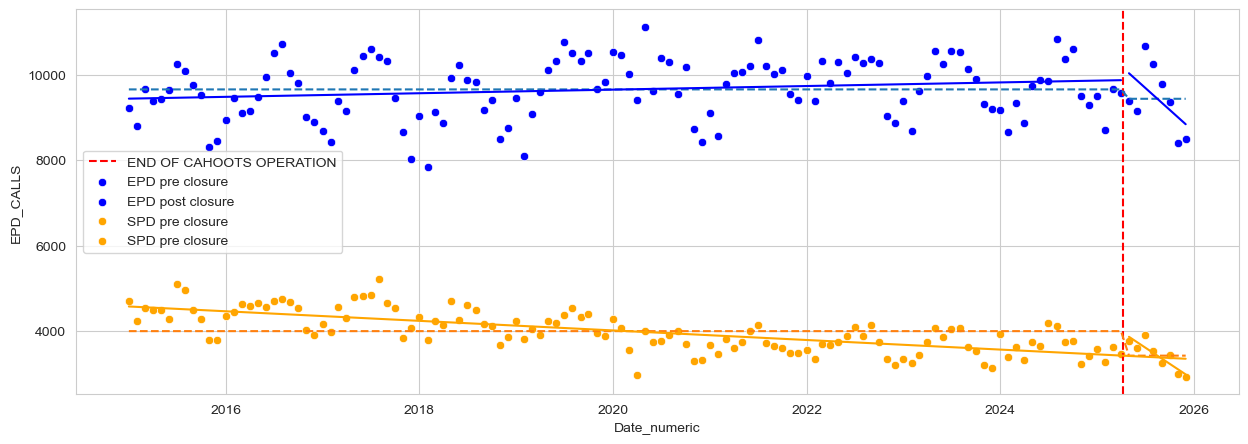

In [227]:
plt.figure(figsize=(15,5))

plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.scatterplot(data = EUG_VOLUME_PRE, x = "Date_numeric", y = "EPD_CALLS", label = "EPD pre closure", color = "blue")
sns.scatterplot(data = EUG_VOLUME_POST, x = "Date_numeric", y = "EPD_CALLS", label = "EPD post closure", color = "blue")

sns.scatterplot(data = SPR_VOLUME_PRE, x = "Date_numeric", y = "SPD_CALLS", label = "SPD pre closure", color = "orange")
sns.scatterplot(data = SPR_VOLUME_POST, x = "Date_numeric", y = "SPD_CALLS", label = "SPD pre closure", color = "orange")


plt.plot(EPD_SPD_VOLUME[EPD_SPD_VOLUME["variable"] == "EPD_CALLS"]["Date_numeric"], EPD_SPD_VOLUME[EPD_SPD_VOLUME["variable"] == "EPD_CALLS"]["prediction"], linestyle = "--")
plt.plot(EPD_SPD_VOLUME[EPD_SPD_VOLUME["variable"] == "SPD_CALLS"]["Date_numeric"], EPD_SPD_VOLUME[EPD_SPD_VOLUME["variable"] == "SPD_CALLS"]["prediction"], linestyle = "--")

plt.plot(EPD_VOLUME_PRE["Date_numeric"], EPD_VOLUME_PRE["prediction"], color = "blue")
plt.plot(EPD_VOLUME_POST["Date_numeric"], EPD_VOLUME_POST["prediction"], color = "blue")

plt.plot(SPD_VOLUME_PRE["Date_numeric"], SPD_VOLUME_PRE["prediction"], color = "orange")
plt.plot(SPD_VOLUME_POST["Date_numeric"], SPD_VOLUME_POST["prediction"], color = "orange")

In [228]:
EPD_SPD_VOLUME_RESULTS = EPD_SPD_VOLUME.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_VOLUME_RESULTS

,treated,post,variable,prediction
0,0,0,SPD_CALLS,3999.000000
1,0,1,SPD_CALLS,3425.125000
2,1,0,EPD_CALLS,9655.862903
3,1,1,EPD_CALLS,9436.375000


In [229]:
RES = EPD_SPD_VOLUME_RESULTS.pivot_table(index="variable", values = ["prediction"], columns=["post"])
RES["difference"] = RES["prediction"][0] - RES["prediction"][1]

In [230]:
RES

prediction            difference
post                 0         1            
variable                                    
EPD_CALLS  9655.862903  9436.375  219.487903
SPD_CALLS  3999.000000  3425.125  573.875000

<Axes: xlabel='variable', ylabel='prediction'>

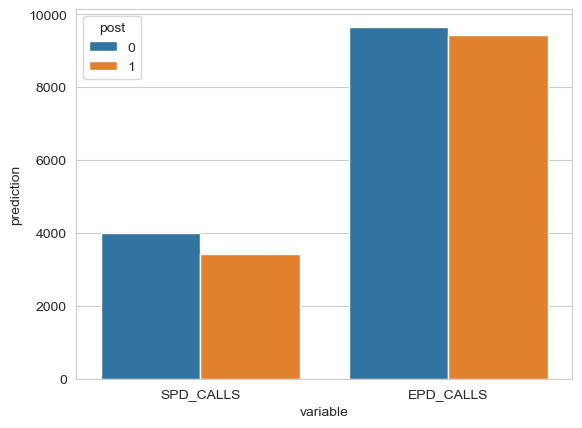

In [231]:
sns.barplot(data = EPD_SPD_VOLUME_RESULTS, x = "variable", y = "prediction", hue="post")

## EPD/SPD CALL PROPORTIONS

In [232]:
EPD_SPD_PROP = TOTAL_EUG_SPR_PROP[TOTAL_EUG_SPR_PROP["variable"].isin(["PROP_EPD", "PROP_SPD"])]

In [233]:
#pre closure pd regression

EPD_PROP_PRE = EPD_SPD_PROP[EPD_SPD_PROP["treated"] == 1]
EPD_PROP_PRE = EPD_PROP_PRE[EPD_PROP_PRE["post"] == 0]

EPD_PROP_POST = EPD_SPD_PROP[EPD_SPD_PROP["treated"] == 1]
EPD_PROP_POST = EPD_PROP_POST[EPD_PROP_POST["post"] == 1]

SPD_PROP_PRE = EPD_SPD_PROP[EPD_SPD_PROP["treated"] == 0]
SPD_PROP_PRE = SPD_PROP_PRE[SPD_PROP_PRE["post"] == 0]

SPD_PROP_POST = EPD_SPD_PROP[EPD_SPD_PROP["treated"] == 0]
SPD_PROP_POST = SPD_PROP_POST[SPD_PROP_POST["post"] == 1]

In [234]:
#Proportion OLS Model Fitting

Model_EPD_PRE = fit_model(EPD_PROP_PRE["value"], EPD_PROP_PRE["Date_numeric"])
EPD_PROP_PRE["prediction"] = Model_EPD_PRE.predict()

Model_EPD_POST = fit_model(EPD_PROP_POST["value"], EPD_PROP_POST["Date_numeric"])
EPD_PROP_POST["prediction"] = Model_EPD_POST.predict()

Model_SPD_PRE = fit_model(SPD_PROP_PRE["value"], SPD_PROP_PRE["Date_numeric"])
SPD_PROP_PRE["prediction"] = Model_SPD_PRE.predict()

Model_SPD_POST = fit_model(SPD_PROP_POST["value"], SPD_PROP_POST["Date_numeric"])
SPD_PROP_POST["prediction"] = Model_SPD_POST.predict()

In [235]:
#EPD/SPD DID

model_pd_prop = fit_DID(EPD_SPD_PROP, summary=True)
EPD_SPD_PROP["prediction"] = model_pd_prop.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.487
Method:                 Least Squares   F-statistic:                     84.20
Date:                Fri, 29 May 2026   Prob (F-statistic):           4.32e-38
Time:                        10:50:54   Log-Likelihood:                 586.54
No. Observations:                 264   AIC:                            -1165.
Df Residuals:                     260   BIC:                            -1151.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.9188      0.002    387.021   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/3684267554.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_PROP["prediction"] = model_pd_prop.predict()


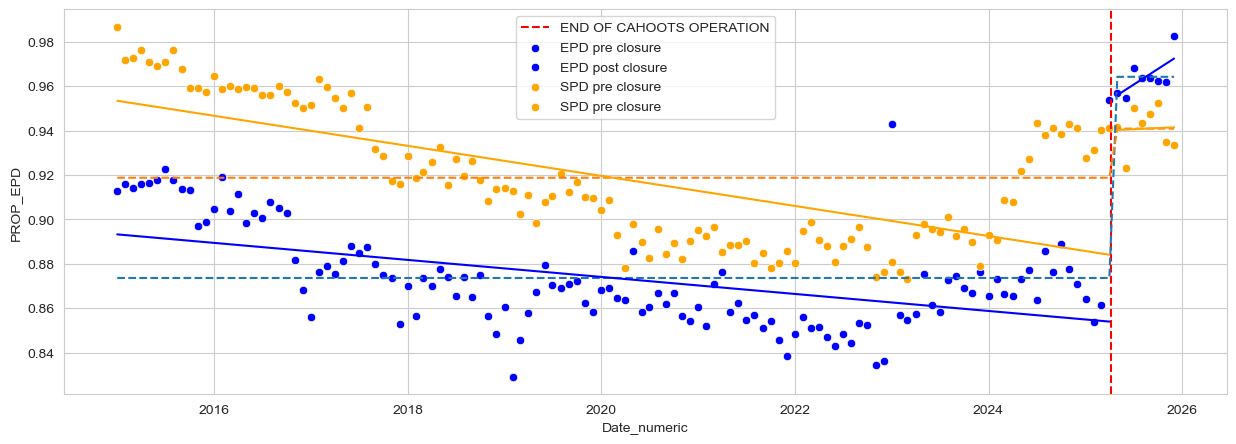

In [236]:
plt.figure(figsize=(15,5))


plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.scatterplot(data = EUG_VOLUME_PRE, x = "Date_numeric", y = "PROP_EPD", label = "EPD pre closure", color = "blue")
sns.scatterplot(data = EUG_VOLUME_POST, x = "Date_numeric", y = "PROP_EPD", label = "EPD post closure", color = "blue")

sns.scatterplot(data = SPR_VOLUME_PRE, x = "Date_numeric", y = "PROP_SPD", label = "SPD pre closure", color = "orange")
sns.scatterplot(data = SPR_VOLUME_POST, x = "Date_numeric", y = "PROP_SPD", label = "SPD pre closure", color = "orange")


#plt.plot(EPD_SPD_PROP["Date_numeric"], y_pred, label="Regression Line")
plt.plot(EPD_SPD_PROP[EPD_SPD_PROP["variable"] == "PROP_EPD"]["Date_numeric"], EPD_SPD_PROP[EPD_SPD_PROP["variable"] == "PROP_EPD"]["prediction"], linestyle = "--")
plt.plot(EPD_SPD_PROP[EPD_SPD_PROP["variable"] == "PROP_SPD"]["Date_numeric"], EPD_SPD_PROP[EPD_SPD_PROP["variable"] == "PROP_SPD"]["prediction"], linestyle = "--")

plt.plot(EPD_PROP_PRE["Date_numeric"], EPD_PROP_PRE["prediction"], color = "blue")
plt.plot(EPD_PROP_POST["Date_numeric"], EPD_PROP_POST["prediction"], color = "blue")

plt.plot(SPD_PROP_PRE["Date_numeric"], SPD_PROP_PRE["prediction"], color = "orange")
plt.plot(SPD_PROP_POST["Date_numeric"], SPD_PROP_POST["prediction"], color = "orange")

In [237]:
EPD_SPD_PROP_RESULTS = EPD_SPD_PROP.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_PROP_RESULTS

,treated,post,variable,prediction
0,0,0,PROP_SPD,0.918770
1,0,1,PROP_SPD,0.940907
2,1,0,PROP_EPD,0.873597
3,1,1,PROP_EPD,0.964266


In [446]:
RES = EPD_SPD_PROP_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
RES["difference"] = (RES[0] - RES[1]) * -1
RES

post,0,1,difference
variable,,,
PROP_EPD,0.873597,0.964266,0.090669
PROP_SPD,0.918770,0.940907,0.022138


<Axes: xlabel='variable', ylabel='prediction'>

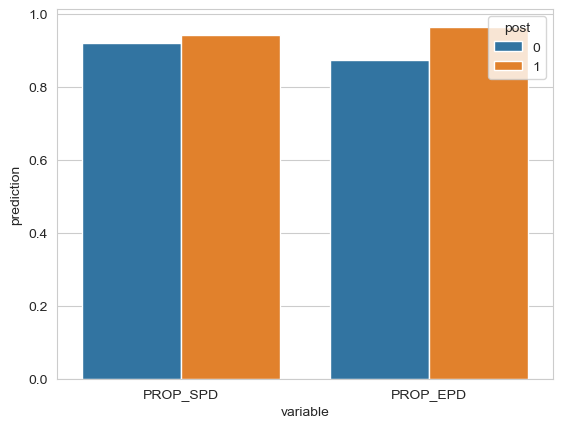

In [239]:
sns.barplot(data = EPD_SPD_PROP_RESULTS, x = "variable", y = "prediction", hue="post")

## MCSLC VOLUME DID

In [240]:
MCSLC_TOTAL_VOLUME = TOTAL_EUG_SPR_VOLUME[TOTAL_EUG_SPR_VOLUME["variable"].isin(["MCSLC_EUG_CALLS", "MCSLC_SPR_CALLS"])]
MCSLC_TOTAL_VOLUME = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["value"] > 0]
MCSLC_TOTAL_VOLUME = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["Date"] != dt.datetime(2025, 12, 1)]

In [241]:
#pre closure MCSLC regression

MCSLC_EUG_VOLUME_PRE = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["treated"] == 1]
MCSLC_EUG_VOLUME_PRE = MCSLC_EUG_VOLUME_PRE[MCSLC_EUG_VOLUME_PRE["post"] == 0]

MCSLC_EUG_VOLUME_POST = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["treated"] == 1]
MCSLC_EUG_VOLUME_POST = MCSLC_EUG_VOLUME_POST[MCSLC_EUG_VOLUME_POST["post"] == 1]

MCSLC_SPR_VOLUME_PRE = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["treated"] == 0]
MCSLC_SPR_VOLUME_PRE = MCSLC_SPR_VOLUME_PRE[MCSLC_SPR_VOLUME_PRE["post"] == 0]

MCSLC_SPR_VOLUME_POST = MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["treated"] == 0]
MCSLC_SPR_VOLUME_POST = MCSLC_SPR_VOLUME_POST[MCSLC_SPR_VOLUME_POST["post"] == 1]


In [242]:
#OLS models

Model_MCSLC_EUG_PRE = fit_model(MCSLC_EUG_VOLUME_PRE["value"], MCSLC_EUG_VOLUME_PRE["Date_numeric"])
MCSLC_EUG_VOLUME_PRE["prediction"] = Model_MCSLC_EUG_PRE.predict()

Model_MCSLC_EUG_POST = fit_model(MCSLC_EUG_VOLUME_POST["value"], MCSLC_EUG_VOLUME_POST["Date_numeric"])
MCSLC_EUG_VOLUME_POST["prediction"] = Model_MCSLC_EUG_POST.predict()

Model_MCLSC_SPR_PRE = fit_model(MCSLC_SPR_VOLUME_PRE["value"], MCSLC_SPR_VOLUME_PRE["Date_numeric"])
MCSLC_SPR_VOLUME_PRE["prediction"] = Model_MCLSC_SPR_PRE.predict()

Model_MCSLC_SPR_POST = fit_model(MCSLC_SPR_VOLUME_POST["value"], MCSLC_SPR_VOLUME_POST["Date_numeric"])
MCSLC_SPR_VOLUME_POST["prediction"] = Model_MCSLC_SPR_POST.predict()

In [243]:
#MCSLC DID model

Model_MCSLC_vol = fit_DID(MCSLC_TOTAL_VOLUME, summary=True)
MCSLC_TOTAL_VOLUME["prediction"] = Model_MCSLC_vol.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.944
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                     134.8
Date:                Fri, 29 May 2026   Prob (F-statistic):           3.76e-15
Time:                        10:50:55   Log-Likelihood:                -139.73
No. Observations:                  28   AIC:                             287.5
Df Residuals:                      24   BIC:                             292.8
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.5714     14.522      0.935   

In [244]:
MCSLC_TOTAL_VOLUME.head()

,Date,Date_numeric,post,treated,variable,value,prediction
247,2024-08-01,19936.0,0,1,MCSLC_EUG_CALLS,56.0,109.142857
248,2024-09-01,19967.0,0,1,MCSLC_EUG_CALLS,120.0,109.142857
249,2024-10-01,19997.0,0,1,MCSLC_EUG_CALLS,15.0,109.142857
252,2025-01-01,20089.0,0,1,MCSLC_EUG_CALLS,92.0,109.142857
253,2025-02-01,20120.0,0,1,MCSLC_EUG_CALLS,116.0,109.142857


In [245]:
MCSLC_EUG_VOLUME_PRE

,Date,Date_numeric,post,treated,variable,value,prediction
247,2024-08-01,19936.0,0,1,MCSLC_EUG_CALLS,56.0,44.267460
248,2024-09-01,19967.0,0,1,MCSLC_EUG_CALLS,120.0,60.192756
249,2024-10-01,19997.0,0,1,MCSLC_EUG_CALLS,15.0,75.604332
252,2025-01-01,20089.0,0,1,MCSLC_EUG_CALLS,92.0,122.866499
253,2025-02-01,20120.0,0,1,MCSLC_EUG_CALLS,116.0,138.791794
254,2025-03-01,20148.0,0,1,MCSLC_EUG_CALLS,141.0,153.175932
255,2025-04-01,20179.0,0,1,MCSLC_EUG_CALLS,224.0,169.101227


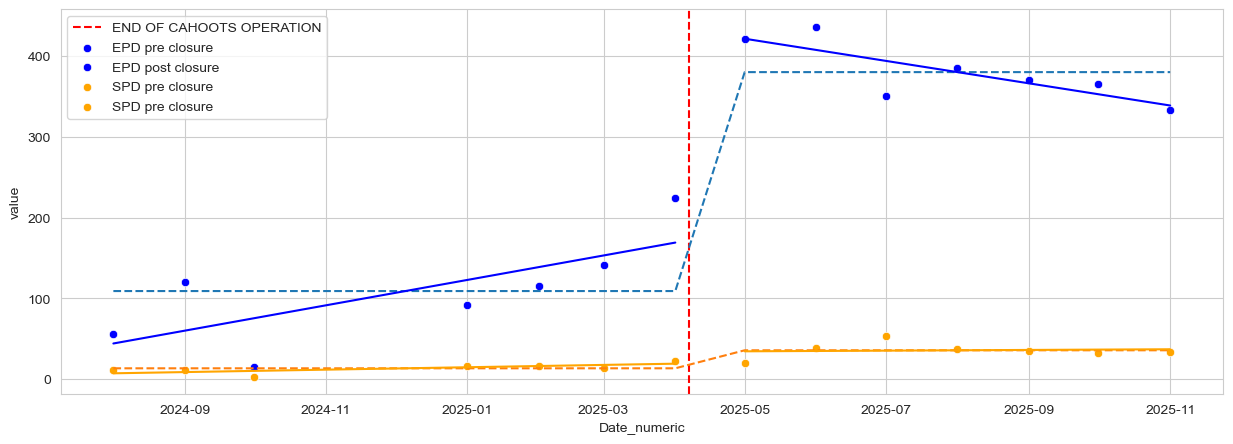

In [246]:
plt.figure(figsize=(15,5))


plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.scatterplot(data = MCSLC_EUG_VOLUME_PRE, x = "Date_numeric", y = "value", label = "EPD pre closure", color = "blue")
sns.scatterplot(data = MCSLC_EUG_VOLUME_POST, x = "Date_numeric", y = "value", label = "EPD post closure", color = "blue")

sns.scatterplot(data = MCSLC_SPR_VOLUME_PRE, x = "Date_numeric", y = "value", label = "SPD pre closure", color = "orange")
sns.scatterplot(data = MCSLC_SPR_VOLUME_POST, x = "Date_numeric", y = "value", label = "SPD pre closure", color = "orange")


#plt.plot(MCSLC_TOTAL_VOLUME["Date_numeric"], y_pred, label="Regression Line")
plt.plot(MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["variable"] == "MCSLC_EUG_CALLS"]["Date_numeric"], MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["variable"] == "MCSLC_EUG_CALLS"]["prediction"], linestyle = "--")
plt.plot(MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["variable"] == "MCSLC_SPR_CALLS"]["Date_numeric"], MCSLC_TOTAL_VOLUME[MCSLC_TOTAL_VOLUME["variable"] == "MCSLC_SPR_CALLS"]["prediction"], linestyle = "--")

plt.plot(MCSLC_EUG_VOLUME_PRE["Date_numeric"], MCSLC_EUG_VOLUME_PRE["prediction"], color = "blue")
plt.plot(MCSLC_SPR_VOLUME_POST["Date_numeric"], MCSLC_EUG_VOLUME_POST["prediction"], color = "blue")

plt.plot(MCSLC_SPR_VOLUME_PRE["Date_numeric"], MCSLC_SPR_VOLUME_PRE["prediction"], color = "orange")
plt.plot(MCSLC_SPR_VOLUME_POST["Date_numeric"], MCSLC_SPR_VOLUME_POST["prediction"], color = "orange")

In [247]:
MCSLC_VOLUME_RESULTS = MCSLC_TOTAL_VOLUME.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
MCSLC_VOLUME_RESULTS

,treated,post,variable,prediction
0,0,0,MCSLC_SPR_CALLS,13.571429
1,0,1,MCSLC_SPR_CALLS,35.857143
2,1,0,MCSLC_EUG_CALLS,109.142857
3,1,1,MCSLC_EUG_CALLS,380.000000


## MCSLC PROPORTION DID

In [248]:
MCSLC_TOTAL_PROP = TOTAL_EUG_SPR_PROP[TOTAL_EUG_SPR_PROP["variable"].isin(["PROP_MCSLC_EUG", "PROP_MCSLC_SPR"])]
MCSLC_TOTAL_PROP = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["value"] > 0]
MCSLC_TOTAL_PROP = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["Date"] != dt.datetime(2025, 12, 1)]

In [249]:
#pre closure MCSLC regression

MCSLC_EUG_PROP_PRE = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["treated"] == 1]
MCSLC_EUG_PROP_PRE = MCSLC_EUG_PROP_PRE[MCSLC_EUG_PROP_PRE["post"] == 0]

MCSLC_EUG_PROP_POST = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["treated"] == 1]
MCSLC_EUG_PROP_POST = MCSLC_EUG_PROP_POST[MCSLC_EUG_PROP_POST["post"] == 1]

MCSLC_SPR_PROP_PRE = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["treated"] == 0]
MCSLC_SPR_PROP_PRE = MCSLC_SPR_PROP_PRE[MCSLC_SPR_PROP_PRE["post"] == 0]

MCSLC_SPR_PROP_POST = MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["treated"] == 0]
MCSLC_SPR_PROP_POST = MCSLC_SPR_PROP_POST[MCSLC_SPR_PROP_POST["post"] == 1]


In [250]:
#OLS models

Model_MCSLC_EUG_PRE = fit_model(MCSLC_EUG_PROP_PRE["value"], MCSLC_EUG_PROP_PRE["Date_numeric"])
MCSLC_EUG_PROP_PRE["prediction"] = Model_MCSLC_EUG_PRE.predict()

Model_MCSLC_EUG_POST = fit_model(MCSLC_EUG_PROP_POST["value"], MCSLC_EUG_PROP_POST["Date_numeric"])
MCSLC_EUG_PROP_POST["prediction"] = Model_MCSLC_EUG_POST.predict()

Model_MCLSC_SPR_PRE = fit_model(MCSLC_SPR_PROP_PRE["value"], MCSLC_SPR_PROP_PRE["Date_numeric"])
MCSLC_SPR_PROP_PRE["prediction"] = Model_MCLSC_SPR_PRE.predict()

Model_MCSLC_SPR_POST = fit_model(MCSLC_SPR_PROP_POST["value"], MCSLC_SPR_PROP_POST["Date_numeric"])
MCSLC_SPR_PROP_POST["prediction"] = Model_MCSLC_SPR_POST.predict()

In [251]:
#MCSLC DID model

Model_MCSLC_prop = fit_DID(MCSLC_TOTAL_PROP, summary=True)
MCSLC_TOTAL_PROP["prediction"] = Model_MCSLC_prop.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                     91.32
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.89e-13
Time:                        10:50:55   Log-Likelihood:                 114.91
No. Observations:                  28   AIC:                            -221.8
Df Residuals:                      24   BIC:                            -216.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0035      0.002      2.177   

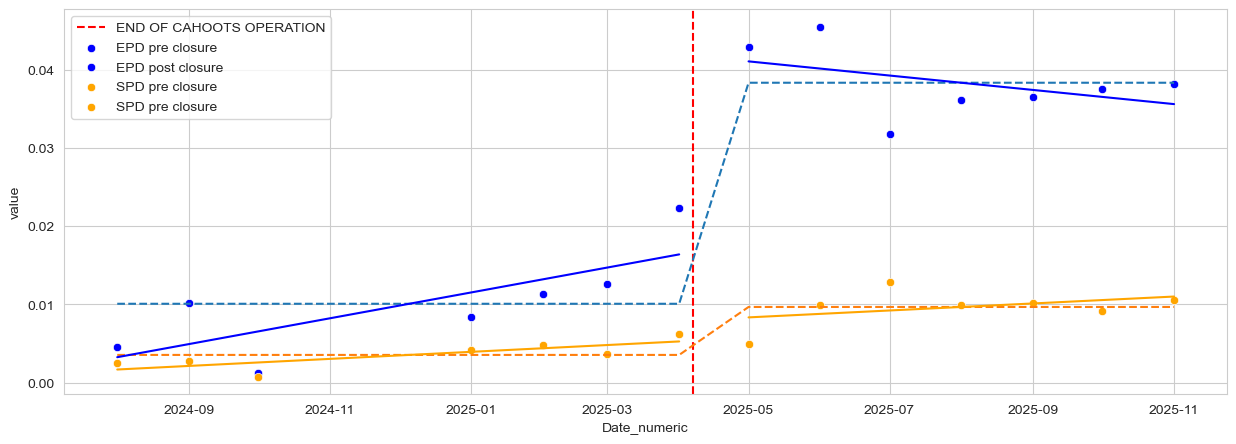

In [252]:
plt.figure(figsize=(15,5))


plt.axvline(dt.datetime(2025, 4, 7), color = 'red', linestyle = "--", label = "END OF CAHOOTS OPERATION")

sns.scatterplot(data = MCSLC_EUG_PROP_PRE, x = "Date_numeric", y = "value", label = "EPD pre closure", color = "blue")
sns.scatterplot(data = MCSLC_EUG_PROP_POST, x = "Date_numeric", y = "value", label = "EPD post closure", color = "blue")

sns.scatterplot(data = MCSLC_SPR_PROP_PRE, x = "Date_numeric", y = "value", label = "SPD pre closure", color = "orange")
sns.scatterplot(data = MCSLC_SPR_PROP_POST, x = "Date_numeric", y = "value", label = "SPD pre closure", color = "orange")


#plt.plot(MCSLC_TOTAL_PROP["Date_numeric"], y_pred, label="Regression Line")
plt.plot(MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["variable"] == "PROP_MCSLC_EUG"]["Date_numeric"], MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["variable"] == "PROP_MCSLC_EUG"]["prediction"], linestyle = "--")
plt.plot(MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["variable"] == "PROP_MCSLC_SPR"]["Date_numeric"], MCSLC_TOTAL_PROP[MCSLC_TOTAL_PROP["variable"] == "PROP_MCSLC_SPR"]["prediction"], linestyle = "--")

plt.plot(MCSLC_EUG_PROP_PRE["Date_numeric"], MCSLC_EUG_PROP_PRE["prediction"], color = "blue")
plt.plot(MCSLC_SPR_PROP_POST["Date_numeric"], MCSLC_EUG_PROP_POST["prediction"], color = "blue")

plt.plot(MCSLC_SPR_PROP_PRE["Date_numeric"], MCSLC_SPR_PROP_PRE["prediction"], color = "orange")
plt.plot(MCSLC_SPR_PROP_POST["Date_numeric"], MCSLC_SPR_PROP_POST["prediction"], color = "orange")

In [253]:
MCSLC_PROP_RESULTS = MCSLC_TOTAL_PROP.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
MCSLC_PROP_RESULTS

,treated,post,variable,prediction
0,0,0,PROP_MCSLC_SPR,0.003550
1,0,1,PROP_MCSLC_SPR,0.009684
2,1,0,PROP_MCSLC_EUG,0.010092
3,1,1,PROP_MCSLC_EUG,0.038363


In [453]:
OVERALL_PROP_RESULTS = pd.concat([EPD_SPD_PROP_RESULTS, MCSLC_PROP_RESULTS])
OVERALL_PROP_RESULTS = OVERALL_PROP_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
OVERALL_PROP_RESULTS["difference"] = (OVERALL_PROP_RESULTS[0] - OVERALL_PROP_RESULTS[1]) * -1
OVERALL_PROP_RESULTS = OVERALL_PROP_RESULTS.reset_index()

OVERALL_PROP_RESULTS

post,variable,0,1,difference
0,PROP_EPD,0.873597,0.964266,0.090669
1,PROP_MCSLC_EUG,0.010092,0.038363,0.028271
2,PROP_MCSLC_SPR,0.003550,0.009684,0.006134
3,PROP_SPD,0.918770,0.940907,0.022138


<Axes: xlabel='variable', ylabel='difference'>

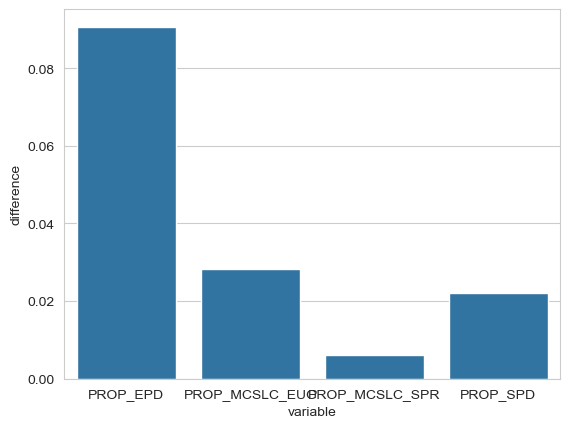

In [454]:
sns.barplot(data=OVERALL_PROP_RESULTS, x = "variable", y = "difference")

Text(0.5, 1.0, 'MCSLC PROPORTION')

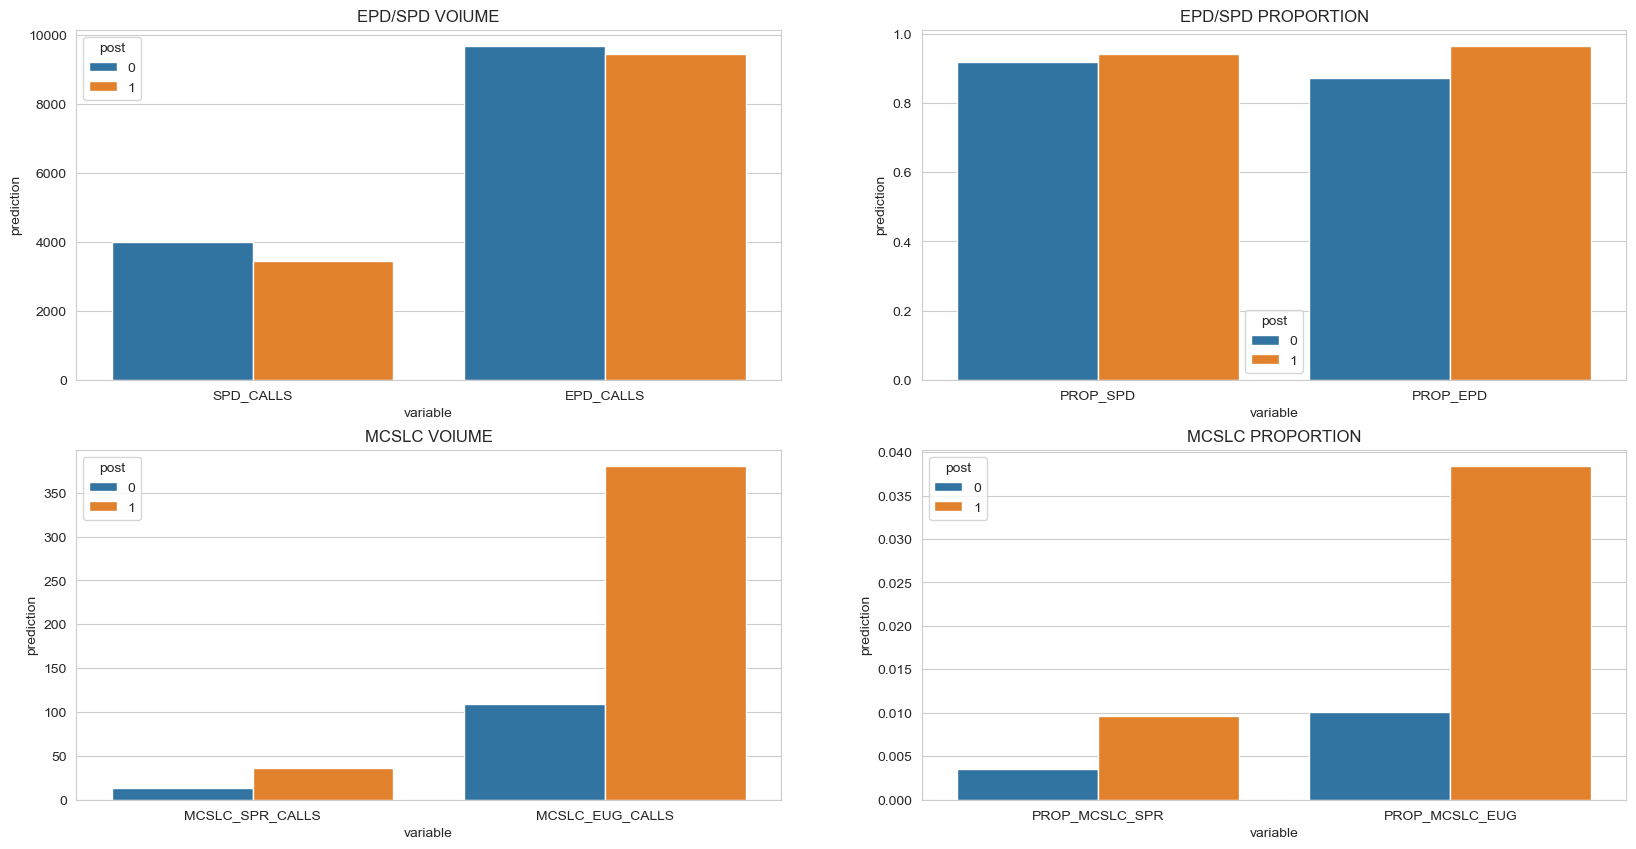

In [254]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))

sns.barplot(EPD_SPD_VOLUME_RESULTS, x = "variable", y = "prediction", hue = "post", ax=axes[0,0])
axes[0,0].set_title("EPD/SPD VOlUME")
sns.barplot(EPD_SPD_PROP_RESULTS, x = "variable", y = "prediction", hue = "post", ax=axes[0,1])
axes[0,1].set_title("EPD/SPD PROPORTION")
sns.barplot(MCSLC_VOLUME_RESULTS, x = "variable", y = "prediction", hue = "post", ax=axes[1,0])
axes[1,0].set_title("MCSLC VOlUME")
sns.barplot(MCSLC_PROP_RESULTS, x = "variable", y = "prediction", hue = "post", ax=axes[1,1])
axes[1,1].set_title("MCSLC PROPORTION")


---

# CALL TYPE DiD

In [255]:
# create numeric date columns

EUG_SPR_TYPES_PROP = EUG_SPR_TYPES_PROP.reset_index()
EUG_SPR_TYPES_PROP["Date_numeric"] = mdates.date2num(EUG_SPR_TYPES_PROP["Date"])


EUG_SPR_TYPES_PROP

Date            call type treated       calls              \
agency                                         CAHOOTS_EUG CAHOOTS_SPR   
0      2015-01-01        ASSIST PUBLIC       0         0.0         6.0   
1      2015-01-01        ASSIST PUBLIC       1       262.0         0.0   
2      2015-01-01        CHECK WELFARE       0         0.0        24.0   
3      2015-01-01        CHECK WELFARE       1       138.0         0.0   
4      2015-01-01  INTOXICATED SUBJECT       0         0.0         3.0   
...           ...                  ...     ...         ...         ...   
1579   2025-12-01                OTHER       1         0.0         0.0   
1580   2025-12-01     SUICIDAL SUBJECT       0         0.0         7.0   
1581   2025-12-01     SUICIDAL SUBJECT       1         0.0         0.0   
1582   2025-12-01            TRANSPORT       0         0.0         1.0   
1583   2025-12-01            TRANSPORT       1         0.0         0.0   

                                         CAHOOTS_EUG_PROP CAHOOTS_SPR_PROP  \
agency     EPD MCSLC_EUG MCSLC_SPR   SPD                                     
0          0.0       0.0       0.0  10.0              NaN         0.375000   
1        167.0       0.0       0.0   0.0         0.610723              NaN   
2          0.0       0.0       0.0  95.0              NaN         0.201681   
3        191.0       0.0       0.0   0.0         0.419453              NaN   
4          0.0       0.0       0.0  13.0              NaN         0.187500   
...        ...       ...       ...   ...              ...              ...   
1579    7843.0     138.0       0.0   0.0         0.000000              NaN   
1580       0.0       0.0       1.0  21.0              NaN         0.241379   
1581      89.0      11.0       0.0   0.0         0.000000              NaN   
1582       0.0       0.0       0.0  13.0              NaN         0.071429   
1583       7.0       0.0       0.0   0.0         0.000000              NaN   

        EPD_PROP  SPD_PROP MCSLC_EUG_PROP MCSLC_SPR_PROP Date_numeric  
agency                                                                 
0            NaN  0.625000            NaN       0.000000      16436.0  
1       0.389277       NaN       0.000000            NaN      16436.0  
2            NaN  0.798319            NaN       0.000000      16436.0  
3       0.580547       NaN       0.000000            NaN      16436.0  
4            NaN  0.812500            NaN       0.000000      16436.0  
...          ...       ...            ...            ...          ...  
1579    0.982709       NaN       0.017291            NaN      20423.0  
1580         NaN  0.724138            NaN       0.034483      20423.0  
1581    0.890000       NaN       0.110000            NaN      20423.0  
1582         NaN  0.928571            NaN       0.000000      20423.0  
1583    1.000000       NaN       0.000000            NaN      20423.0  

[1584 rows x 16 columns]

In [256]:
#Create treated and post columns

EUG_SPR_TYPES_PROP["post"] = (EUG_SPR_TYPES_PROP["Date"] > CAHOOTS_closure).astype(int)

EUG_SPR_TYPES_PROP["CAHOOTS_EUG_VOLUME"] = EUG_SPR_TYPES_PROP["calls"]["CAHOOTS_EUG"]
EUG_SPR_TYPES_PROP["EPD_VOLUME"] = EUG_SPR_TYPES_PROP["calls"]["EPD"]
EUG_SPR_TYPES_PROP["MCSLC_EUG_VOLUME"] = EUG_SPR_TYPES_PROP["calls"]["MCSLC_EUG"]
EUG_SPR_TYPES_PROP["CAHOOTS_SPR_VOLUME"] = EUG_SPR_TYPES_PROP["calls"]["CAHOOTS_SPR"]
EUG_SPR_TYPES_PROP["SPD_VOLUME"] = EUG_SPR_TYPES_PROP["calls"]["SPD"]
EUG_SPR_TYPES_PROP["MCLSC_SPR_VOLUME"] = EUG_SPR_TYPES_PROP["calls"]["MCSLC_SPR"]

EUG_SPR_TYPES_PROP = EUG_SPR_TYPES_PROP.drop(columns="calls")

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/724841786.py:12: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  EUG_SPR_TYPES_PROP = EUG_SPR_TYPES_PROP.drop(columns="calls")


In [257]:
TOTAL_EUG_VOLUME_tidy

,Date,Date_numeric,post,treated,variable,value
0,2015-01-01,16436.0,0,1,EPD_CALLS,9223.0
1,2015-02-01,16467.0,0,1,EPD_CALLS,8809.0
2,2015-03-01,16495.0,0,1,EPD_CALLS,9663.0
3,2015-04-01,16526.0,0,1,EPD_CALLS,9395.0
4,2015-05-01,16556.0,0,1,EPD_CALLS,9432.0
...,...,...,...,...,...,...
391,2025-08-01,20301.0,1,1,CH_EUG_CALLS,0.0
392,2025-09-01,20332.0,1,1,CH_EUG_CALLS,0.0
393,2025-10-01,20362.0,1,1,CH_EUG_CALLS,0.0
394,2025-11-01,20393.0,1,1,CH_EUG_CALLS,0.0


In [258]:
EUG_SPR_TYPES_PROP

,Date,call type,treated,CAHOOTS_EUG_PROP,CAHOOTS_SPR_PROP,EPD_PROP,SPD_PROP,MCSLC_EUG_PROP,MCSLC_SPR_PROP,Date_numeric,post,CAHOOTS_EUG_VOLUME,EPD_VOLUME,MCSLC_EUG_VOLUME,CAHOOTS_SPR_VOLUME,SPD_VOLUME,MCLSC_SPR_VOLUME
agency,,,,,,,,,,,,,,,,,
0,2015-01-01,ASSIST PUBLIC,0,NaN,0.375000,NaN,0.625000,NaN,0.000000,16436.0,0,0.0,0.0,0.0,6.0,10.0,0.0
1,2015-01-01,ASSIST PUBLIC,1,0.610723,NaN,0.389277,NaN,0.000000,NaN,16436.0,0,262.0,167.0,0.0,0.0,0.0,0.0
2,2015-01-01,CHECK WELFARE,0,NaN,0.201681,NaN,0.798319,NaN,0.000000,16436.0,0,0.0,0.0,0.0,24.0,95.0,0.0
3,2015-01-01,CHECK WELFARE,1,0.419453,NaN,0.580547,NaN,0.000000,NaN,16436.0,0,138.0,191.0,0.0,0.0,0.0,0.0
4,2015-01-01,INTOXICATED SUBJECT,0,NaN,0.187500,NaN,0.812500,NaN,0.000000,16436.0,0,0.0,0.0,0.0,3.0,13.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,2025-12-01,OTHER,1,0.000000,NaN,0.982709,NaN,0.017291,NaN,20423.0,1,0.0,7843.0,138.0,0.0,0.0,0.0
1580,2025-12-01,SUICIDAL SUBJECT,0,NaN,0.241379,NaN,0.724138,NaN,0.034483,20423.0,1,0.0,0.0,0.0,7.0,21.0,1.0
1581,2025-12-01,SUICIDAL SUBJECT,1,0.000000,NaN,0.890000,NaN,0.110000,NaN,20423.0,1,0.0,89.0,11.0,0.0,0.0,0.0


In [259]:
EUG_SPR_TPYES = pd.DataFrame({
    "Date": EUG_SPR_TYPES_PROP["Date"],
    "Date_numeric": EUG_SPR_TYPES_PROP["Date_numeric"],
    "call type": EUG_SPR_TYPES_PROP["call type"],
    "treated": EUG_SPR_TYPES_PROP["treated"],
    "post": EUG_SPR_TYPES_PROP["post"],
    "CAHOOTS_EUG_PROP": EUG_SPR_TYPES_PROP["CAHOOTS_EUG_PROP"],
    "CAHOOTS_SPR_PROP": EUG_SPR_TYPES_PROP["CAHOOTS_SPR_PROP"],
    "EPD_PROP": EUG_SPR_TYPES_PROP["EPD_PROP"],
    "SPD_PROP": EUG_SPR_TYPES_PROP["SPD_PROP"],
    "MCSLC_EUG_PROP": EUG_SPR_TYPES_PROP["MCSLC_EUG_PROP"],
    "MCSLC_SPR_PROP": EUG_SPR_TYPES_PROP["MCSLC_SPR_PROP"],
    "CAHOOTS_EUG_VOLUME": EUG_SPR_TYPES_PROP["CAHOOTS_EUG_VOLUME"],
    "CAHOOTS_SPR_VOLUME": EUG_SPR_TYPES_PROP["CAHOOTS_SPR_VOLUME"],
    "EPD_VOLUME": EUG_SPR_TYPES_PROP["EPD_VOLUME"],
    "SPD_VOLUME": EUG_SPR_TYPES_PROP["SPD_VOLUME"],
    "MCSLC_EUG_VOLUME": EUG_SPR_TYPES_PROP["MCSLC_EUG_VOLUME"],
    "MCSLC_SPR_VOLUME": EUG_SPR_TYPES_PROP["MCLSC_SPR_VOLUME"],
})

In [260]:
#TIDY PROP TYPE SUBSETS

EUG_TYPES_PROP_tidy = EUG_SPR_TPYES.melt(id_vars = ["Date", "Date_numeric", "post", "treated", "call type"], value_vars = ["EPD_PROP", "CAHOOTS_EUG_PROP", "MCSLC_EUG_PROP"]).dropna()
SPR_TYPES_PROP_tidy = EUG_SPR_TPYES.melt(id_vars = ["Date", "Date_numeric", "post", "treated", "call type"], value_vars = ["SPD_PROP", "CAHOOTS_SPR_PROP", "MCSLC_SPR_PROP"]).dropna()
EUG_SPR_TYPES_PROP_tidy = pd.concat([EUG_TYPES_PROP_tidy, SPR_TYPES_PROP_tidy])

EPD_SPD_PROP_TYPES = EUG_SPR_TYPES_PROP_tidy[EUG_SPR_TYPES_PROP_tidy["variable"].isin(["EPD_PROP", "SPD_PROP"])]
CAHOOTS_PROP_TYPES = EUG_SPR_TYPES_PROP_tidy[EUG_SPR_TYPES_PROP_tidy["variable"].isin(["CAHOOTS_EUG_PROP", "CAHOOTS_SPR_PROP"])]
MCSLC_PROP_TYPES = EUG_SPR_TYPES_PROP_tidy[EUG_SPR_TYPES_PROP_tidy["variable"].isin(["MCSLC_EUG_PROP", "MCSLC_SPR_PROP"])]

In [318]:
#TIDY VOLUME TYPE SUBSETS

EUG_TYPES_VOLUME_tidy = EUG_SPR_TPYES.melt(id_vars = ["Date", "Date_numeric", "post", "treated", "call type"], value_vars = ["EPD_VOLUME", "CAHOOTS_EUG_VOLUME", "MCSLC_EUG_VOLUME"]).dropna()
EUG_TYPES_VOLUME_tidy = EUG_TYPES_VOLUME_tidy[EUG_TYPES_VOLUME_tidy["treated"] != 0]
SPR_TYPES_VOLUME_tidy = EUG_SPR_TPYES.melt(id_vars = ["Date", "Date_numeric", "post", "treated", "call type"], value_vars = ["SPD_VOLUME", "CAHOOTS_SPR_VOLUME", "MCSLC_SPR_VOLUME"]).dropna()
SPR_TYPES_VOLUME_tidy = SPR_TYPES_VOLUME_tidy[SPR_TYPES_VOLUME_tidy["treated"] != 1]
EUG_SPR_TYPES_VOLUME_tidy = pd.concat([EUG_TYPES_VOLUME_tidy, SPR_TYPES_VOLUME_tidy])

EPD_SPD_VOLUME_TYPES = EUG_SPR_TYPES_VOLUME_tidy[EUG_SPR_TYPES_VOLUME_tidy["variable"].isin(["EPD_VOLUME", "SPD_VOLUME"])]
CAHOOTS_VOLUME_TYPES = EUG_SPR_TYPES_VOLUME_tidy[EUG_SPR_TYPES_VOLUME_tidy["variable"].isin(["CAHOOTS_EUG_VOLUME", "CAHOOTS_SPR_VOLUME"])]
MCSLC_VOLUME_TYPES = EUG_SPR_TYPES_VOLUME_tidy[EUG_SPR_TYPES_VOLUME_tidy["variable"].isin(["MCSLC_EUG_VOLUME", "MCSLC_SPR_VOLUME"])]

In [319]:
EUG_TYPES_VOLUME_tidy

,Date,Date_numeric,post,treated,call type,variable,value
1,2015-01-01,16436.0,0,1,ASSIST PUBLIC,EPD_VOLUME,167.0
3,2015-01-01,16436.0,0,1,CHECK WELFARE,EPD_VOLUME,191.0
5,2015-01-01,16436.0,0,1,INTOXICATED SUBJECT,EPD_VOLUME,24.0
7,2015-01-01,16436.0,0,1,OTHER,EPD_VOLUME,8757.0
9,2015-01-01,16436.0,0,1,SUICIDAL SUBJECT,EPD_VOLUME,68.0
...,...,...,...,...,...,...,...
4743,2025-12-01,20423.0,1,1,CHECK WELFARE,MCSLC_EUG_VOLUME,0.0
4745,2025-12-01,20423.0,1,1,INTOXICATED SUBJECT,MCSLC_EUG_VOLUME,1.0
4747,2025-12-01,20423.0,1,1,OTHER,MCSLC_EUG_VOLUME,138.0
4749,2025-12-01,20423.0,1,1,SUICIDAL SUBJECT,MCSLC_EUG_VOLUME,11.0


In [320]:
EPD_SPD_PROP_TYPES

,Date,Date_numeric,post,treated,call type,variable,value
1,2015-01-01,16436.0,0,1,ASSIST PUBLIC,EPD_PROP,0.389277
3,2015-01-01,16436.0,0,1,CHECK WELFARE,EPD_PROP,0.580547
5,2015-01-01,16436.0,0,1,INTOXICATED SUBJECT,EPD_PROP,0.436364
7,2015-01-01,16436.0,0,1,OTHER,EPD_PROP,0.991508
9,2015-01-01,16436.0,0,1,SUICIDAL SUBJECT,EPD_PROP,0.739130
...,...,...,...,...,...,...,...
1574,2025-12-01,20423.0,1,0,CHECK WELFARE,SPD_PROP,0.587983
1576,2025-12-01,20423.0,1,0,INTOXICATED SUBJECT,SPD_PROP,0.400000
1578,2025-12-01,20423.0,1,0,OTHER,SPD_PROP,0.988797
1580,2025-12-01,20423.0,1,0,SUICIDAL SUBJECT,SPD_PROP,0.724138


In [321]:
EPD_SPD_VOLUME_TYPES

,Date,Date_numeric,post,treated,call type,variable,value
1,2015-01-01,16436.0,0,1,ASSIST PUBLIC,EPD_VOLUME,167.0
3,2015-01-01,16436.0,0,1,CHECK WELFARE,EPD_VOLUME,191.0
5,2015-01-01,16436.0,0,1,INTOXICATED SUBJECT,EPD_VOLUME,24.0
7,2015-01-01,16436.0,0,1,OTHER,EPD_VOLUME,8757.0
9,2015-01-01,16436.0,0,1,SUICIDAL SUBJECT,EPD_VOLUME,68.0
...,...,...,...,...,...,...,...
1574,2025-12-01,20423.0,1,0,CHECK WELFARE,SPD_VOLUME,137.0
1576,2025-12-01,20423.0,1,0,INTOXICATED SUBJECT,SPD_VOLUME,2.0
1578,2025-12-01,20423.0,1,0,OTHER,SPD_VOLUME,2736.0
1580,2025-12-01,20423.0,1,0,SUICIDAL SUBJECT,SPD_VOLUME,21.0


In [367]:
#functions

def pre_post_split(df):
    eug_pre = df[df["post"] == 0]
    eug_pre = eug_pre[eug_pre["treated"] == 1]

    eug_post = df[df["post"] == 1]
    eug_post = eug_post[eug_post["treated"] == 1]

    spr_pre = df[df["post"] == 0]
    spr_pre = spr_pre[spr_pre["treated"] == 0]

    spr_post = df[df["post"] == 1]
    spr_post = spr_post[spr_post["treated"] == 0]

    return eug_pre, eug_post, spr_pre, spr_post

def pre_post_predictions(eug_pre, eug_post, spr_pre, spr_post):
    model_eug_pre = fit_model(eug_pre["value"], eug_pre["Date_numeric"])
    eug_pre["prediction"] = model_eug_pre.predict()

    model_eug_post = fit_model(eug_post["value"], eug_post["Date_numeric"])
    eug_post["prediction"] = model_eug_post.predict()

    model_spr_pre = fit_model(spr_pre["value"], spr_pre["Date_numeric"])
    spr_pre["prediction"] = model_spr_pre.predict()

    model_spr_post = fit_model(spr_post["value"], spr_post["Date_numeric"])
    spr_post["prediction"] = model_spr_post.predict()

    return model_eug_pre, model_eug_post, model_spr_pre, model_spr_post

def plot_models(df, eug_pre, eug_post, spr_pre, spr_post, eug_label, spr_label, title):

    eug = df[df["treated"] == 1]
    spr = df[df["treated"] == 0]

    plt.figure(figsize = (10,5))

    plt.axvline(x = CAHOOTS_closure, color = "red", linestyle = "--", label = "CAHOOTS Closure")

    sns.scatterplot(data = eug, x = "Date", y = "value", label = eug_label, color = "blue")
    sns.scatterplot(data = spr, x = "Date", y = "value", label = spr_label, color = "orange")

    sns.lineplot(data = eug, x = "Date", y = "prediction", linestyle = "--", color = "blue")
    sns.lineplot(data = spr, x = "Date", y = "prediction", linestyle = "--", color = "orange")

    plt.plot(eug_pre["Date_numeric"], eug_pre["prediction"], color = "blue")
    plt.plot(eug_post["Date_numeric"], eug_post["prediction"], color = "blue")

    plt.plot(spr_pre["Date_numeric"], spr_pre["prediction"], color = "orange")
    plt.plot(spr_post["Date_numeric"], spr_post["prediction"], color = "orange")

    plt.title(title)


# WELFARE CHECKS

## Proportion

In [368]:
#subset by call type
EPD_SPD_WELFARE_CHECKS_PROP = EPD_SPD_PROP_TYPES[EPD_SPD_PROP_TYPES["call type"] == "CHECK WELFARE"]
EPD_SPD_WELFARE_CHECKS_PROP

,Date,Date_numeric,post,treated,call type,variable,value
3,2015-01-01,16436.0,0,1,CHECK WELFARE,EPD_PROP,0.580547
15,2015-02-01,16467.0,0,1,CHECK WELFARE,EPD_PROP,0.531915
27,2015-03-01,16495.0,0,1,CHECK WELFARE,EPD_PROP,0.494565
39,2015-04-01,16526.0,0,1,CHECK WELFARE,EPD_PROP,0.468391
51,2015-05-01,16556.0,0,1,CHECK WELFARE,EPD_PROP,0.478873
...,...,...,...,...,...,...,...
1526,2025-08-01,20301.0,1,0,CHECK WELFARE,SPD_PROP,0.631148
1538,2025-09-01,20332.0,1,0,CHECK WELFARE,SPD_PROP,0.723684
1550,2025-10-01,20362.0,1,0,CHECK WELFARE,SPD_PROP,0.725225
1562,2025-11-01,20393.0,1,0,CHECK WELFARE,SPD_PROP,0.712871


In [369]:
#subset by pre and post

EPD_WELFARE_CHECK_PROP_PRE = EPD_SPD_WELFARE_CHECKS_PROP[EPD_SPD_WELFARE_CHECKS_PROP["post"] == 0]
EPD_WELFARE_CHECK_PROP_PRE = EPD_WELFARE_CHECK_PROP_PRE[EPD_WELFARE_CHECK_PROP_PRE["treated"] == 1]

EPD_WELFARE_CHECK_PROP_POST = EPD_SPD_WELFARE_CHECKS_PROP[EPD_SPD_WELFARE_CHECKS_PROP["post"] == 1]
EPD_WELFARE_CHECK_PROP_POST = EPD_WELFARE_CHECK_PROP_POST[EPD_WELFARE_CHECK_PROP_POST["treated"] == 1]

SPD_WELFARE_CHECK_PROP_PRE = EPD_SPD_WELFARE_CHECKS_PROP[EPD_SPD_WELFARE_CHECKS_PROP["post"] == 0]
SPD_WELFARE_CHECK_PROP_PRE = SPD_WELFARE_CHECK_PROP_PRE[SPD_WELFARE_CHECK_PROP_PRE["treated"] == 0]

SPD_WELFARE_CHECK_PROP_POST = EPD_SPD_WELFARE_CHECKS_PROP[EPD_SPD_WELFARE_CHECKS_PROP["post"] == 1]
SPD_WELFARE_CHECK_PROP_POST = SPD_WELFARE_CHECK_PROP_POST[SPD_WELFARE_CHECK_PROP_POST["treated"] == 0]


In [370]:
EPD_SPD_PROP_TYPES

,Date,Date_numeric,post,treated,call type,variable,value
1,2015-01-01,16436.0,0,1,ASSIST PUBLIC,EPD_PROP,0.389277
3,2015-01-01,16436.0,0,1,CHECK WELFARE,EPD_PROP,0.580547
5,2015-01-01,16436.0,0,1,INTOXICATED SUBJECT,EPD_PROP,0.436364
7,2015-01-01,16436.0,0,1,OTHER,EPD_PROP,0.991508
9,2015-01-01,16436.0,0,1,SUICIDAL SUBJECT,EPD_PROP,0.739130
...,...,...,...,...,...,...,...
1574,2025-12-01,20423.0,1,0,CHECK WELFARE,SPD_PROP,0.587983
1576,2025-12-01,20423.0,1,0,INTOXICATED SUBJECT,SPD_PROP,0.400000
1578,2025-12-01,20423.0,1,0,OTHER,SPD_PROP,0.988797
1580,2025-12-01,20423.0,1,0,SUICIDAL SUBJECT,SPD_PROP,0.724138


In [371]:
#OLS models

model_EPD_WELFARE_CHECK_PRE = fit_model(EPD_WELFARE_CHECK_PROP_PRE["value"], EPD_WELFARE_CHECK_PROP_PRE["Date_numeric"])
EPD_WELFARE_CHECK_PROP_PRE["prediction"] = model_EPD_WELFARE_CHECK_PRE.predict()

model_EPD_WELFARE_CHECK_POST = fit_model(EPD_WELFARE_CHECK_PROP_POST["value"], EPD_WELFARE_CHECK_PROP_POST["Date_numeric"])
EPD_WELFARE_CHECK_PROP_POST["prediction"] = model_EPD_WELFARE_CHECK_POST.predict()

model_SPD_WELFARE_CHECK_PRE = fit_model(SPD_WELFARE_CHECK_PROP_PRE["value"], SPD_WELFARE_CHECK_PROP_PRE["Date_numeric"])
SPD_WELFARE_CHECK_PROP_PRE["prediction"] = model_SPD_WELFARE_CHECK_PRE.predict()

model_SPD_WELFARE_CHECK_POST = fit_model(SPD_WELFARE_CHECK_PROP_POST["value"], SPD_WELFARE_CHECK_PROP_POST["Date_numeric"])
SPD_WELFARE_CHECK_PROP_POST["prediction"] = model_SPD_WELFARE_CHECK_POST.predict()

In [372]:
#EPD/SPD WELFARE CHECK DiD

EPD_SPD_WELFARE_CHECK_model = fit_DID(EPD_SPD_WELFARE_CHECKS_PROP, summary=True)
EPD_SPD_WELFARE_CHECKS_PROP["prediction"] = EPD_SPD_WELFARE_CHECK_model.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.533
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     99.08
Date:                Fri, 29 May 2026   Prob (F-statistic):           8.64e-43
Time:                        11:10:53   Log-Likelihood:                 248.36
No. Observations:                 264   AIC:                            -488.7
Df Residuals:                     260   BIC:                            -474.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.4892      0.009     57.236   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/3765299673.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_WELFARE_CHECKS_PROP["prediction"] = EPD_SPD_WELFARE_CHECK_model.predict()


In [373]:
#calculate difference

EPD_SPD_WELFARE_CHECK_PROP_RESULTS = EPD_SPD_WELFARE_CHECKS_PROP.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_WELFARE_CHECK_PROP_RESULTS = EPD_SPD_WELFARE_CHECK_PROP_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
EPD_SPD_WELFARE_CHECK_PROP_RESULTS["difference"] = (EPD_SPD_WELFARE_CHECK_PROP_RESULTS[0] - EPD_SPD_WELFARE_CHECK_PROP_RESULTS[1]) * -1

EPD_SPD_WELFARE_CHECK_PROP_RESULTS

post,0,1,difference
variable,,,
EPD_PROP,0.434244,1.000000,0.565756
SPD_PROP,0.489179,0.661487,0.172307


In [374]:
EPD_WELFARE_CHECKS_PROP = EPD_SPD_WELFARE_CHECKS_PROP[EPD_SPD_WELFARE_CHECKS_PROP["variable"] == "EPD_PROP"]
SPD_WELFARE_CHECKS_PROP = EPD_SPD_WELFARE_CHECKS_PROP[EPD_SPD_WELFARE_CHECKS_PROP["variable"] == "SPD_PROP"]

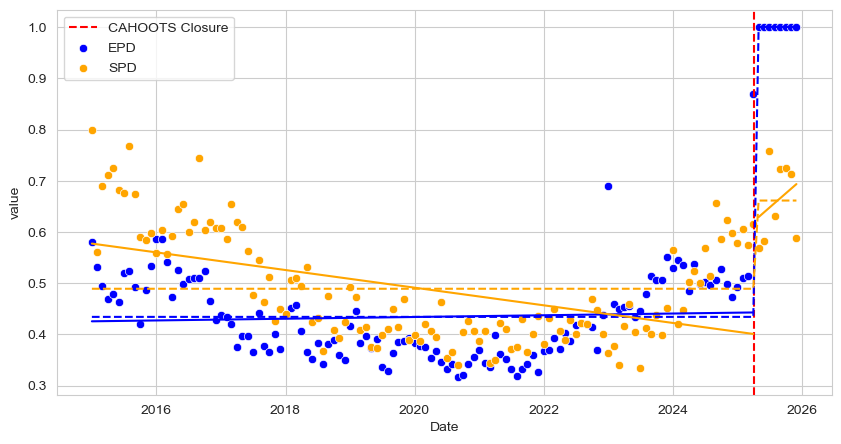

In [375]:
plt.figure(figsize = (10,5))

plt.axvline(x = CAHOOTS_closure, color = "red", linestyle = "--", label = "CAHOOTS Closure")

sns.scatterplot(data = EPD_WELFARE_CHECKS_PROP, x = "Date", y = "value", label = "EPD", color = "blue")
sns.scatterplot(data = SPD_WELFARE_CHECKS_PROP, x = "Date", y = "value", label = "SPD", color = "orange")

sns.lineplot(data = EPD_WELFARE_CHECKS_PROP, x = "Date", y = "prediction", linestyle = "--", color = "blue")
sns.lineplot(data = SPD_WELFARE_CHECKS_PROP, x = "Date", y = "prediction", linestyle = "--", color = "orange")

plt.plot(EPD_WELFARE_CHECK_PROP_PRE["Date_numeric"], EPD_WELFARE_CHECK_PROP_PRE["prediction"], color = "blue")
plt.plot(EPD_WELFARE_CHECK_PROP_POST["Date_numeric"], EPD_WELFARE_CHECK_PROP_POST["prediction"], color = "blue")

plt.plot(SPD_WELFARE_CHECK_PROP_PRE["Date_numeric"], SPD_WELFARE_CHECK_PROP_PRE["prediction"], color = "orange")
plt.plot(SPD_WELFARE_CHECK_PROP_POST["Date_numeric"], SPD_WELFARE_CHECK_PROP_POST["prediction"], color = "orange")

## volume

In [376]:
EPD_SPD_WELFARE_CHECK_VOLUME = EPD_SPD_VOLUME_TYPES[EPD_SPD_VOLUME_TYPES["call type"] == "CHECK WELFARE"]

In [377]:
#subset by pre and post

EPD_WELFARE_CHECK_VOLUME_PRE, EPD_WELFARE_CHECK_VOLUME_POST, SPD_WELFARE_CHECK_VOLUME_PRE, SPD_WELFARE_CHECK_VOLUME_POST = pre_post_split(EPD_SPD_WELFARE_CHECK_VOLUME)

In [378]:
model_EPD_WELFARE_CHECK_VOLUME_PRE, model_EPD_WELFARE_CHECK_VOLUME_POST, model_SPD_WELFARE_CHECK_VOLUME_PRE, model_SPD_WELFARE_CHECK_VOLUME_POST = pre_post_predictions(EPD_WELFARE_CHECK_VOLUME_PRE,
                                                                                                                                                EPD_WELFARE_CHECK_VOLUME_POST,
                                                                                                                                                SPD_WELFARE_CHECK_VOLUME_PRE,
                                                                                                                                                SPD_WELFARE_CHECK_VOLUME_POST)

In [379]:
#DID WELFARE CHECK VOLUME

EPD_SPD_WELFARE_CHECK_model = fit_DID(EPD_SPD_WELFARE_CHECK_VOLUME, summary=True)
EPD_SPD_WELFARE_CHECK_VOLUME["prediction"] = EPD_SPD_WELFARE_CHECK_model.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     269.2
Date:                Fri, 29 May 2026   Prob (F-statistic):           2.01e-79
Time:                        11:10:53   Log-Likelihood:                -1455.9
No. Observations:                 264   AIC:                             2920.
Df Residuals:                     260   BIC:                             2934.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept      126.3710      5.437     23.243   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/968866732.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_WELFARE_CHECK_VOLUME["prediction"] = EPD_SPD_WELFARE_CHECK_model.predict()


In [444]:
EPD_SPD_WELFARE_CHECK_model._results.pvalues

array([2.02785307e-65, 2.89217839e-65, 1.27638118e-01, 3.57697801e-12])

In [380]:
#calculate differences
EPD_SPD_WELFARE_CHECK_VOLUME_RESULTS = EPD_SPD_WELFARE_CHECK_VOLUME.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_WELFARE_CHECK_VOLUME_RESULTS = EPD_SPD_WELFARE_CHECK_VOLUME_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
EPD_SPD_WELFARE_CHECK_VOLUME_RESULTS["difference"] = (EPD_SPD_WELFARE_CHECK_VOLUME_RESULTS[0] - EPD_SPD_WELFARE_CHECK_VOLUME_RESULTS[1]) * -1

EPD_SPD_WELFARE_CHECK_VOLUME_RESULTS

post,0,1,difference
variable,,,
EPD_VOLUME,304.725806,566.375,261.649194
SPD_VOLUME,126.370968,160.125,33.754032


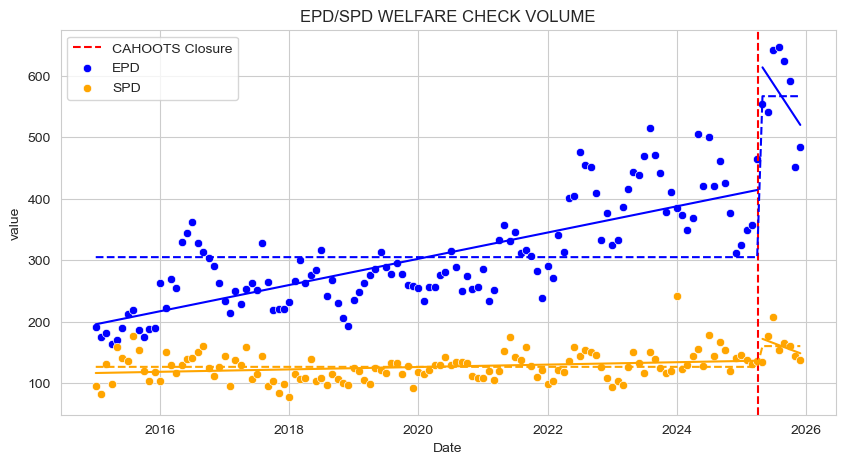

In [382]:
plot_models(EPD_SPD_WELFARE_CHECK_VOLUME,
            EPD_WELFARE_CHECK_VOLUME_PRE,
            EPD_WELFARE_CHECK_VOLUME_POST,
            SPD_WELFARE_CHECK_VOLUME_PRE,
            SPD_WELFARE_CHECK_VOLUME_POST,
            "EPD",
            "SPD",
            "EPD/SPD WELFARE CHECK VOLUME")

# SUICIDAL SUBJECT

## PROPORTION

In [385]:
EPD_SPD_SUICIDAL_PROP = EPD_SPD_PROP_TYPES[EPD_SPD_PROP_TYPES["call type"] == "SUICIDAL SUBJECT"]
EPD_SPD_SUICIDAL_PROP

,Date,Date_numeric,post,treated,call type,variable,value
9,2015-01-01,16436.0,0,1,SUICIDAL SUBJECT,EPD_PROP,0.739130
21,2015-02-01,16467.0,0,1,SUICIDAL SUBJECT,EPD_PROP,0.695122
33,2015-03-01,16495.0,0,1,SUICIDAL SUBJECT,EPD_PROP,0.755102
45,2015-04-01,16526.0,0,1,SUICIDAL SUBJECT,EPD_PROP,0.691489
57,2015-05-01,16556.0,0,1,SUICIDAL SUBJECT,EPD_PROP,0.781513
...,...,...,...,...,...,...,...
1532,2025-08-01,20301.0,1,0,SUICIDAL SUBJECT,SPD_PROP,0.650000
1544,2025-09-01,20332.0,1,0,SUICIDAL SUBJECT,SPD_PROP,0.600000
1556,2025-10-01,20362.0,1,0,SUICIDAL SUBJECT,SPD_PROP,0.666667
1568,2025-11-01,20393.0,1,0,SUICIDAL SUBJECT,SPD_PROP,0.687500


In [387]:
EPD_SUCICIDAL_PROP_PRE, EPD_SUCICIDAL_PROP_POST, SPD_SUCICIDAL_PROP_PRE, SPD_SUCICIDAL_PROP_POST = pre_post_split(EPD_SPD_SUICIDAL_PROP)

In [388]:
model_EPD_SUICIDAL_PROP_PRE, model_EPD_SUICIDAL_PROP_POST, model_SPD_SUICIDAL_PROP_PRE, model_SPD_SUICIDAL_PROP_POST = pre_post_predictions(EPD_SUCICIDAL_PROP_PRE,
                                                                                                                                            EPD_SUCICIDAL_PROP_POST,
                                                                                                                                            SPD_SUCICIDAL_PROP_PRE,
                                                                                                                                            SPD_SUCICIDAL_PROP_POST)

In [389]:
#DID SUICIDAL SUBJECT PROP

EPD_SPD_SUICIDAL_model = fit_DID(EPD_SPD_SUICIDAL_PROP, summary=True)
EPD_SPD_SUICIDAL_PROP["prediction"] = EPD_SPD_SUICIDAL_model.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     7.313
Date:                Fri, 29 May 2026   Prob (F-statistic):           0.000100
Time:                        11:15:52   Log-Likelihood:                 180.74
No. Observations:                 264   AIC:                            -353.5
Df Residuals:                     260   BIC:                            -339.2
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.5446      0.011     49.319   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/682320491.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_SUICIDAL_PROP["prediction"] = EPD_SPD_SUICIDAL_model.predict()


In [390]:
#calculate differences
EPD_SPD_SUICIDAL_PROP_RESULTS = EPD_SPD_SUICIDAL_PROP.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_SUICIDAL_PROP_RESULTS = EPD_SPD_SUICIDAL_PROP_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
EPD_SPD_SUICIDAL_PROP_RESULTS["difference"] = (EPD_SPD_SUICIDAL_PROP_RESULTS[0] - EPD_SPD_SUICIDAL_PROP_RESULTS[1]) * -1

EPD_SPD_SUICIDAL_PROP_RESULTS

post,0,1,difference
variable,,,
EPD_PROP,0.524443,0.728414,0.203971
SPD_PROP,0.544578,0.584765,0.040188


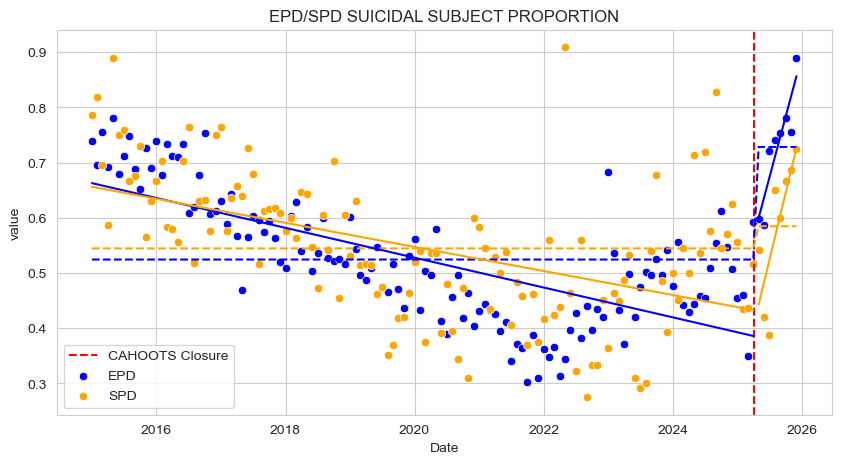

In [393]:
plot_models(EPD_SPD_SUICIDAL_PROP,
            EPD_SUCICIDAL_PROP_PRE,
            EPD_SUCICIDAL_PROP_POST,
            SPD_SUCICIDAL_PROP_PRE,
            SPD_SUCICIDAL_PROP_POST, 
            "EPD",
            "SPD",
            "EPD/SPD SUICIDAL SUBJECT PROPORTION")

In [440]:
MCSLC_PROP_TYPES = MCSLC_PROP_TYPES[MCSLC_PROP_TYPES["Date"] > dt.datetime(2024,1,1)]

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.502
Model:                            OLS   Adj. R-squared:                  0.466
Method:                 Least Squares   F-statistic:                     14.10
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.69e-06
Time:                        13:04:57   Log-Likelihood:                 45.893
No. Observations:                  46   AIC:                            -83.79
Df Residuals:                      42   BIC:                            -76.47
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.0599      0.024      2.483   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/3257391095.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  MCSLC_SUICIDAL_PROP["prediction"] = MCSLC_SUICIDAL_model.predict()


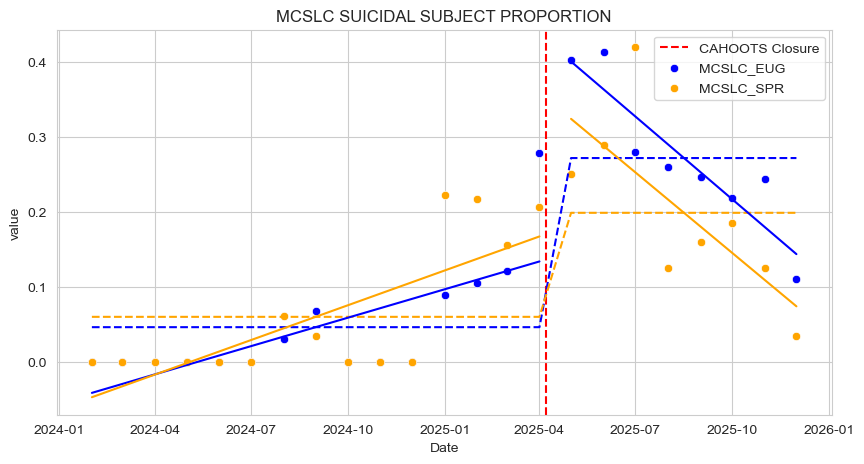

In [442]:
MCSLC_SUICIDAL_PROP = MCSLC_PROP_TYPES[MCSLC_PROP_TYPES["call type"] == "SUICIDAL SUBJECT"]
MCSLC_SUICIDAL_PROP
MCSLC_EUG_SUICIDAL_PROP_PRE, MCSLC_EUG_SUICIDAL_PROP_POST, MCSLC_SPR_SUICIDAL_PROP_PRE, MCSLC_SPR_SUICIDAL_PROP_POST = pre_post_split(MCSLC_SUICIDAL_PROP)
model_MCSLC_EUG_SUICIDAL_PROP_PRE, model_MCSLC_EUG_SUICIDAL_PROP_POST, model_MCSLC_SPR_SUICIDAL_PROP_PRE, model_MCSLC_SPR_SUICIDAL_PROP_POST = pre_post_predictions(MCSLC_EUG_SUICIDAL_PROP_PRE,
                                                                                                                                            MCSLC_EUG_SUICIDAL_PROP_POST,
                                                                                                                                            MCSLC_SPR_SUICIDAL_PROP_PRE,
                                                                                                                                            MCSLC_SPR_SUICIDAL_PROP_POST)
#DID SUICIDAL SUBJECT PROP

MCSLC_SUICIDAL_model = fit_DID(MCSLC_SUICIDAL_PROP, summary=True)
MCSLC_SUICIDAL_PROP["prediction"] = MCSLC_SUICIDAL_model.predict()
#calculate differences
MCSLC_SUICIDAL_PROP_RESULTS = MCSLC_SUICIDAL_PROP.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
MCSLC_SUICIDAL_PROP_RESULTS = MCSLC_SUICIDAL_PROP_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
MCSLC_SUICIDAL_PROP_RESULTS["difference"] = (MCSLC_SUICIDAL_PROP_RESULTS[0] - MCSLC_SUICIDAL_PROP_RESULTS[1]) * -1

MCSLC_SUICIDAL_PROP_RESULTS
plot_models(MCSLC_SUICIDAL_PROP,
            MCSLC_EUG_SUICIDAL_PROP_PRE,
            MCSLC_EUG_SUICIDAL_PROP_POST,
            MCSLC_SPR_SUICIDAL_PROP_PRE,
            MCSLC_SPR_SUICIDAL_PROP_POST, 
            "MCSLC_EUG",
            "MCSLC_SPR",
            "MCSLC SUICIDAL SUBJECT PROPORTION")

## VOLUME

In [394]:
EPD_SPD_SUICIDAL_VOLUME = EPD_SPD_VOLUME_TYPES[EPD_SPD_VOLUME_TYPES["call type"] == "SUICIDAL SUBJECT"]
EPD_SPD_SUICIDAL_VOLUME

,Date,Date_numeric,post,treated,call type,variable,value
9,2015-01-01,16436.0,0,1,SUICIDAL SUBJECT,EPD_VOLUME,68.0
21,2015-02-01,16467.0,0,1,SUICIDAL SUBJECT,EPD_VOLUME,57.0
33,2015-03-01,16495.0,0,1,SUICIDAL SUBJECT,EPD_VOLUME,74.0
45,2015-04-01,16526.0,0,1,SUICIDAL SUBJECT,EPD_VOLUME,65.0
57,2015-05-01,16556.0,0,1,SUICIDAL SUBJECT,EPD_VOLUME,93.0
...,...,...,...,...,...,...,...
1532,2025-08-01,20301.0,1,0,SUICIDAL SUBJECT,SPD_VOLUME,26.0
1544,2025-09-01,20332.0,1,0,SUICIDAL SUBJECT,SPD_VOLUME,15.0
1556,2025-10-01,20362.0,1,0,SUICIDAL SUBJECT,SPD_VOLUME,18.0
1568,2025-11-01,20393.0,1,0,SUICIDAL SUBJECT,SPD_VOLUME,22.0


In [395]:
EPD_SUCICIDAL_VOLUME_PRE, EPD_SUCICIDAL_VOLUME_POST, SPD_SUCICIDAL_VOLUME_PRE, SPD_SUCICIDAL_VOLUME_POST = pre_post_split(EPD_SPD_SUICIDAL_VOLUME)

In [396]:
model_EPD_SUICIDAL_VOLUME_PRE, model_EPD_SUICIDAL_VOLUME_POST, model_SPD_SUICIDAL_VOLUME_PRE, model_SPD_SUICIDAL_VOLUME_POST = pre_post_predictions(EPD_SUCICIDAL_VOLUME_PRE,
                                                                                                                                            EPD_SUCICIDAL_VOLUME_POST,
                                                                                                                                            SPD_SUCICIDAL_VOLUME_PRE,
                                                                                                                                            SPD_SUCICIDAL_VOLUME_POST)

In [397]:
#DID SUICIDAL SUBJECT VOLUME

EPD_SPD_SUICIDAL_VOLUME_model = fit_DID(EPD_SPD_SUICIDAL_VOLUME, summary=True)
EPD_SPD_SUICIDAL_VOLUME["prediction"] = EPD_SPD_SUICIDAL_VOLUME_model.predict()

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     442.4
Date:                Fri, 29 May 2026   Prob (F-statistic):          8.54e-102
Time:                        12:08:12   Log-Likelihood:                -1097.9
No. Observations:                 264   AIC:                             2204.
Df Residuals:                     260   BIC:                             2218.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       17.8145      1.401     12.716   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/1274564381.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_SUICIDAL_VOLUME["prediction"] = EPD_SPD_SUICIDAL_VOLUME_model.predict()


In [398]:
#calculate differences
EPD_SPD_SUICIDAL_VOLUME_RESULTS = EPD_SPD_SUICIDAL_VOLUME.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_SUICIDAL_VOLUME_RESULTS = EPD_SPD_SUICIDAL_VOLUME_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
EPD_SPD_SUICIDAL_VOLUME_RESULTS["difference"] = (EPD_SPD_SUICIDAL_VOLUME_RESULTS[0] - EPD_SPD_SUICIDAL_VOLUME_RESULTS[1]) * -1

EPD_SPD_SUICIDAL_VOLUME_RESULTS

post,0,1,difference
variable,,,
EPD_VOLUME,86.403226,104.625,18.221774
SPD_VOLUME,17.814516,17.875,0.060484


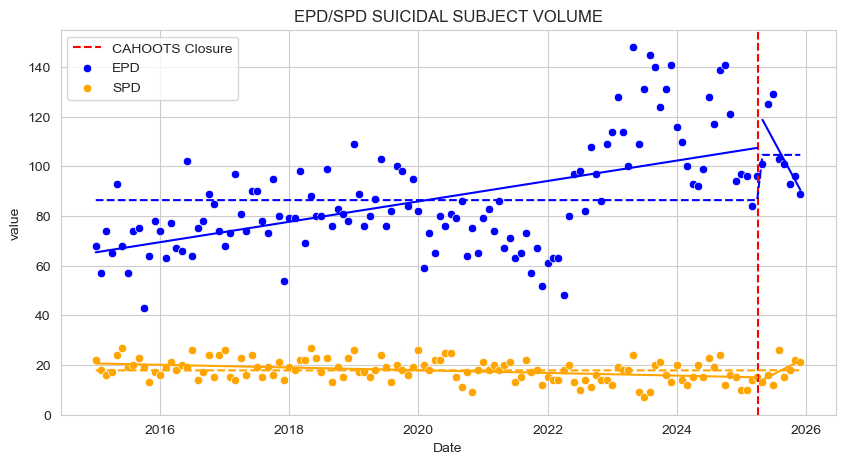

In [400]:
plot_models(EPD_SPD_SUICIDAL_VOLUME,
            EPD_SUCICIDAL_VOLUME_PRE,
            EPD_SUCICIDAL_VOLUME_POST,
            SPD_SUCICIDAL_VOLUME_PRE,
            SPD_SUCICIDAL_VOLUME_POST, 
            "EPD",
            "SPD",
            "EPD/SPD SUICIDAL SUBJECT VOLUME")

# INTOXICATED SUBJECT

## PROP

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     24.10
Date:                Fri, 29 May 2026   Prob (F-statistic):           8.61e-14
Time:                        12:12:06   Log-Likelihood:                 127.42
No. Observations:                 264   AIC:                            -246.8
Df Residuals:                     260   BIC:                            -232.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.4289      0.014     31.743   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/2820213108.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_INTOXICATED_PROP["prediction"] = EPD_SPD_INTOXICATED_model.predict()


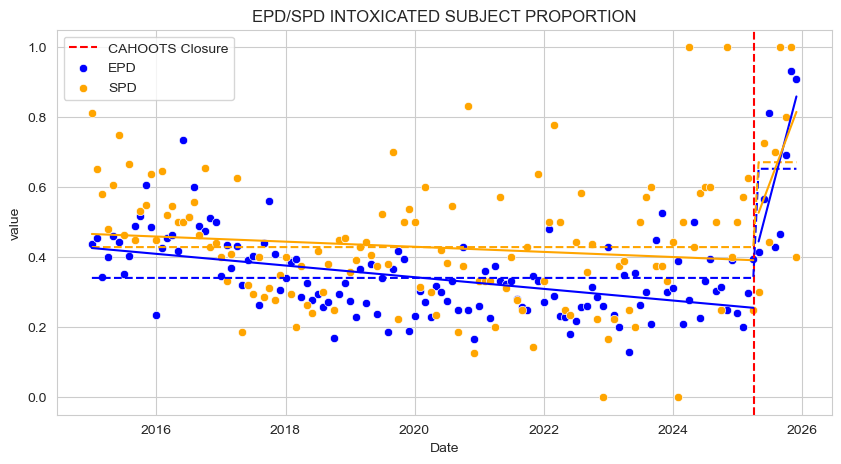

In [401]:
EPD_SPD_INTOXICATED_PROP = EPD_SPD_PROP_TYPES[EPD_SPD_PROP_TYPES["call type"] == "INTOXICATED SUBJECT"]
EPD_SPD_INTOXICATED_PROP
EPD_INTOXICATED_PROP_PRE, EPD_INTOXICATED_PROP_POST, SPD_INTOXICATED_PROP_PRE, SPD_INTOXICATED_PROP_POST = pre_post_split(EPD_SPD_INTOXICATED_PROP)
model_EPD_INTOXICATED_PROP_PRE, model_EPD_INTOXICATED_PROP_POST, model_SPD_INTOXICATED_PROP_PRE, model_SPD_INTOXICATED_PROP_POST = pre_post_predictions(EPD_INTOXICATED_PROP_PRE,
                                                                                                                                            EPD_INTOXICATED_PROP_POST,
                                                                                                                                            SPD_INTOXICATED_PROP_PRE,
                                                                                                                                            SPD_INTOXICATED_PROP_POST)
#DID INTOXICATED SUBJECT PROP

EPD_SPD_INTOXICATED_model = fit_DID(EPD_SPD_INTOXICATED_PROP, summary=True)
EPD_SPD_INTOXICATED_PROP["prediction"] = EPD_SPD_INTOXICATED_model.predict()
#calculate differences
EPD_SPD_INTOXICATED_PROP_RESULTS = EPD_SPD_INTOXICATED_PROP.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_INTOXICATED_PROP_RESULTS = EPD_SPD_INTOXICATED_PROP_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
EPD_SPD_INTOXICATED_PROP_RESULTS["difference"] = (EPD_SPD_INTOXICATED_PROP_RESULTS[0] - EPD_SPD_INTOXICATED_PROP_RESULTS[1]) * -1

EPD_SPD_INTOXICATED_PROP_RESULTS
plot_models(EPD_SPD_INTOXICATED_PROP,
            EPD_INTOXICATED_PROP_PRE,
            EPD_INTOXICATED_PROP_POST,
            SPD_INTOXICATED_PROP_PRE,
            SPD_INTOXICATED_PROP_POST, 
            "EPD",
            "SPD",
            "EPD/SPD INTOXICATED SUBJECT PROPORTION")

## VOLUME

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.228
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     25.58
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.56e-14
Time:                        12:19:07   Log-Likelihood:                -843.90
No. Observations:                 264   AIC:                             1696.
Df Residuals:                     260   BIC:                             1710.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        7.2419      0.535     13.528   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/4139496228.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_INTOXICATED_VOLUME["prediction"] = EPD_SPD_INTOXICATED_model.predict()


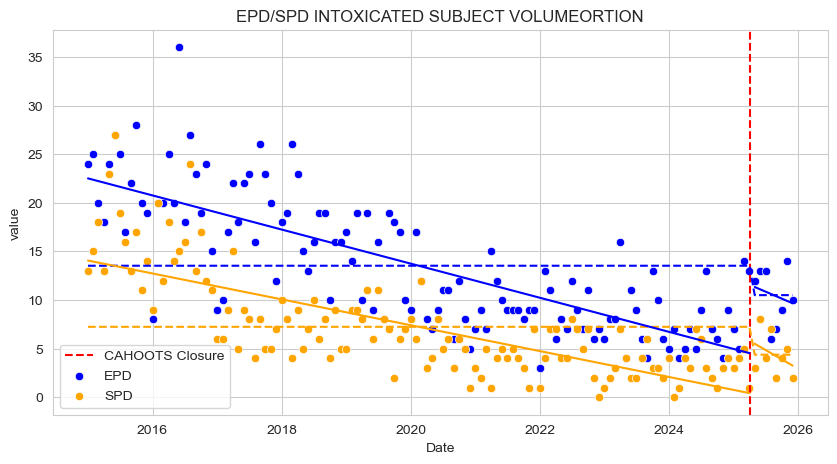

In [404]:
EPD_SPD_INTOXICATED_VOLUME = EPD_SPD_VOLUME_TYPES[EPD_SPD_VOLUME_TYPES["call type"] == "INTOXICATED SUBJECT"]
EPD_SPD_INTOXICATED_VOLUME
EPD_INTOXICATED_VOLUME_PRE, EPD_INTOXICATED_VOLUME_POST, SPD_INTOXICATED_VOLUME_PRE, SPD_INTOXICATED_VOLUME_POST = pre_post_split(EPD_SPD_INTOXICATED_VOLUME)
model_EPD_INTOXICATED_VOLUME_PRE, model_EPD_INTOXICATED_VOLUME_POST, model_SPD_INTOXICATED_VOLUME_PRE, model_SPD_INTOXICATED_VOLUME_POST = pre_post_predictions(EPD_INTOXICATED_VOLUME_PRE,
                                                                                                                                            EPD_INTOXICATED_VOLUME_POST,
                                                                                                                                            SPD_INTOXICATED_VOLUME_PRE,
                                                                                                                                            SPD_INTOXICATED_VOLUME_POST)
#DID INTOXICATED SUBJECT VOLUME

EPD_SPD_INTOXICATED_model = fit_DID(EPD_SPD_INTOXICATED_VOLUME, summary=True)
EPD_SPD_INTOXICATED_VOLUME["prediction"] = EPD_SPD_INTOXICATED_model.predict()
#calculate differences
EPD_SPD_INTOXICATED_VOLUME_RESULTS = EPD_SPD_INTOXICATED_VOLUME.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_INTOXICATED_VOLUME_RESULTS = EPD_SPD_INTOXICATED_VOLUME_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
EPD_SPD_INTOXICATED_VOLUME_RESULTS["difference"] = (EPD_SPD_INTOXICATED_VOLUME_RESULTS[0] - EPD_SPD_INTOXICATED_VOLUME_RESULTS[1]) * -1

EPD_SPD_INTOXICATED_VOLUME_RESULTS
plot_models(EPD_SPD_INTOXICATED_VOLUME,
            EPD_INTOXICATED_VOLUME_PRE,
            EPD_INTOXICATED_VOLUME_POST,
            SPD_INTOXICATED_VOLUME_PRE,
            SPD_INTOXICATED_VOLUME_POST, 
            "EPD",
            "SPD",
            "EPD/SPD INTOXICATED SUBJECT VOLUMEORTION")

# TRANSPORT

## PROPORTION

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.934
Method:                 Least Squares   F-statistic:                     1235.
Date:                Fri, 29 May 2026   Prob (F-statistic):          1.86e-153
Time:                        12:17:15   Log-Likelihood:                 226.49
No. Observations:                 264   AIC:                            -445.0
Df Residuals:                     260   BIC:                            -430.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.8273      0.009     89.097   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/3886004199.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_TRANSPORT_PROP["prediction"] = EPD_SPD_TRANSPORT_model.predict()


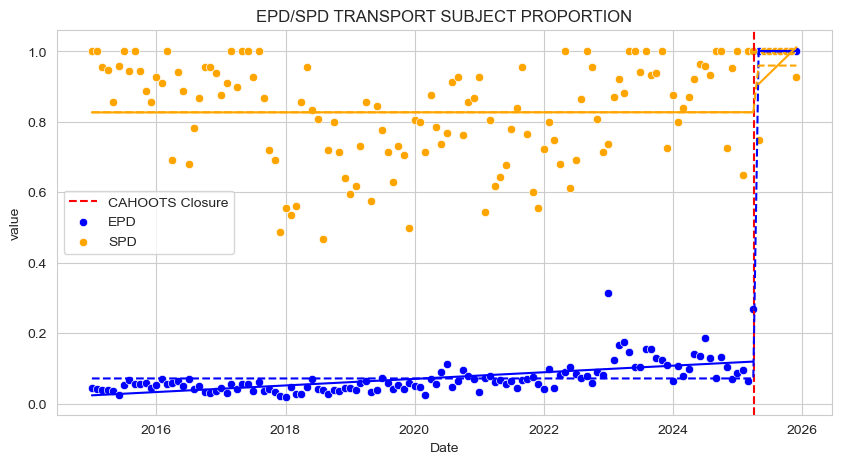

In [403]:
EPD_SPD_TRANSPORT_PROP = EPD_SPD_PROP_TYPES[EPD_SPD_PROP_TYPES["call type"] == "TRANSPORT"]
EPD_SPD_TRANSPORT_PROP
EPD_SUCICIDAL_PROP_PRE, EPD_SUCICIDAL_PROP_POST, SPD_SUCICIDAL_PROP_PRE, SPD_SUCICIDAL_PROP_POST = pre_post_split(EPD_SPD_TRANSPORT_PROP)
model_EPD_TRANSPORT_PROP_PRE, model_EPD_TRANSPORT_PROP_POST, model_SPD_TRANSPORT_PROP_PRE, model_SPD_TRANSPORT_PROP_POST = pre_post_predictions(EPD_SUCICIDAL_PROP_PRE,
                                                                                                                                            EPD_SUCICIDAL_PROP_POST,
                                                                                                                                            SPD_SUCICIDAL_PROP_PRE,
                                                                                                                                            SPD_SUCICIDAL_PROP_POST)
#DID TRANSPORT SUBJECT PROP

EPD_SPD_TRANSPORT_model = fit_DID(EPD_SPD_TRANSPORT_PROP, summary=True)
EPD_SPD_TRANSPORT_PROP["prediction"] = EPD_SPD_TRANSPORT_model.predict()
#calculate differences
EPD_SPD_TRANSPORT_PROP_RESULTS = EPD_SPD_TRANSPORT_PROP.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_TRANSPORT_PROP_RESULTS = EPD_SPD_TRANSPORT_PROP_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
EPD_SPD_TRANSPORT_PROP_RESULTS["difference"] = (EPD_SPD_TRANSPORT_PROP_RESULTS[0] - EPD_SPD_TRANSPORT_PROP_RESULTS[1]) * -1

EPD_SPD_TRANSPORT_PROP_RESULTS
plot_models(EPD_SPD_TRANSPORT_PROP,
            EPD_SUCICIDAL_PROP_PRE,
            EPD_SUCICIDAL_PROP_POST,
            SPD_SUCICIDAL_PROP_PRE,
            SPD_SUCICIDAL_PROP_POST, 
            "EPD",
            "SPD",
            "EPD/SPD TRANSPORT SUBJECT PROPORTION")

## VOLUME

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.110
Model:                            OLS   Adj. R-squared:                  0.100
Method:                 Least Squares   F-statistic:                     10.75
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.10e-06
Time:                        12:21:42   Log-Likelihood:                -805.27
No. Observations:                 264   AIC:                             1619.
Df Residuals:                     260   BIC:                             1633.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       17.6290      0.462     38.119   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/1281945801.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_TRANSPORT_VOLUME["prediction"] = EPD_SPD_TRANSPORT_model.predict()


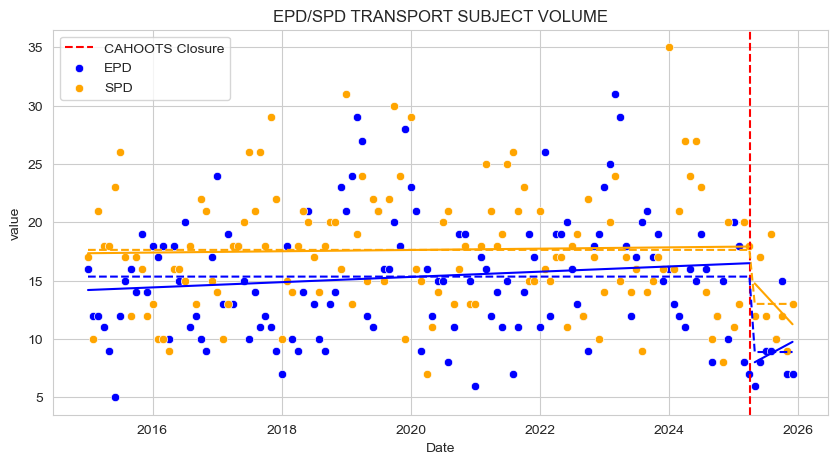

In [406]:
EPD_SPD_TRANSPORT_VOLUME = EPD_SPD_VOLUME_TYPES[EPD_SPD_VOLUME_TYPES["call type"] == "TRANSPORT"]
EPD_SPD_TRANSPORT_VOLUME
EPD_SUCICIDAL_VOLUME_PRE, EPD_SUCICIDAL_VOLUME_POST, SPD_SUCICIDAL_VOLUME_PRE, SPD_SUCICIDAL_VOLUME_POST = pre_post_split(EPD_SPD_TRANSPORT_VOLUME)
model_EPD_TRANSPORT_VOLUME_PRE, model_EPD_TRANSPORT_VOLUME_POST, model_SPD_TRANSPORT_VOLUME_PRE, model_SPD_TRANSPORT_VOLUME_POST = pre_post_predictions(EPD_SUCICIDAL_VOLUME_PRE,
                                                                                                                                            EPD_SUCICIDAL_VOLUME_POST,
                                                                                                                                            SPD_SUCICIDAL_VOLUME_PRE,
                                                                                                                                            SPD_SUCICIDAL_VOLUME_POST)
#DID TRANSPORT SUBJECT VOLUME

EPD_SPD_TRANSPORT_model = fit_DID(EPD_SPD_TRANSPORT_VOLUME, summary=True)
EPD_SPD_TRANSPORT_VOLUME["prediction"] = EPD_SPD_TRANSPORT_model.predict()
#calculate differences
EPD_SPD_TRANSPORT_VOLUME_RESULTS = EPD_SPD_TRANSPORT_VOLUME.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_TRANSPORT_VOLUME_RESULTS = EPD_SPD_TRANSPORT_VOLUME_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
EPD_SPD_TRANSPORT_VOLUME_RESULTS["difference"] = (EPD_SPD_TRANSPORT_VOLUME_RESULTS[0] - EPD_SPD_TRANSPORT_VOLUME_RESULTS[1]) * -1

EPD_SPD_TRANSPORT_VOLUME_RESULTS
plot_models(EPD_SPD_TRANSPORT_VOLUME,
            EPD_SUCICIDAL_VOLUME_PRE,
            EPD_SUCICIDAL_VOLUME_POST,
            SPD_SUCICIDAL_VOLUME_PRE,
            SPD_SUCICIDAL_VOLUME_POST, 
            "EPD",
            "SPD",
            "EPD/SPD TRANSPORT SUBJECT VOLUME")

# PUBLIC ASSIST

## prop

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.770
Model:                            OLS   Adj. R-squared:                  0.767
Method:                 Least Squares   F-statistic:                     290.2
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.19e-82
Time:                        12:24:48   Log-Likelihood:                 297.28
No. Observations:                 264   AIC:                            -586.6
Df Residuals:                     260   BIC:                            -572.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1862      0.007     26.225   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/3411103876.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_ASSIST_PROP["prediction"] = EPD_SPD_ASSIST_model.predict()


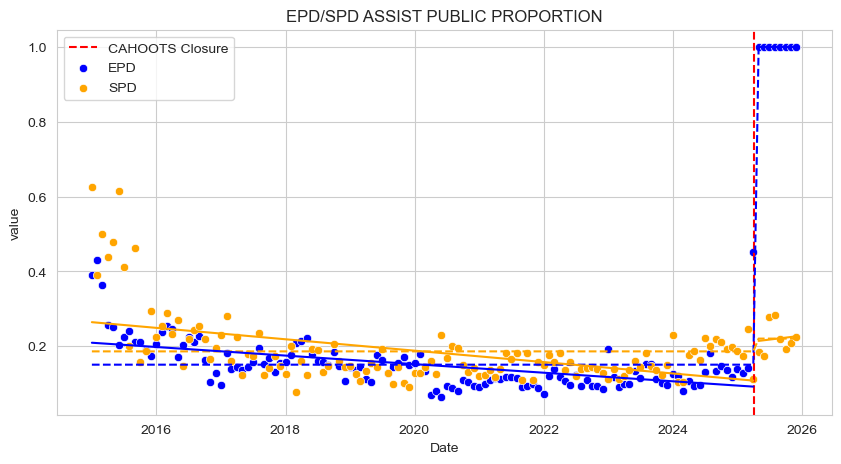

In [410]:
EPD_SPD_ASSIST_PROP = EPD_SPD_PROP_TYPES[EPD_SPD_PROP_TYPES["call type"] == "ASSIST PUBLIC"]
EPD_SPD_ASSIST_PROP
EPD_SUCICIDAL_PROP_PRE, EPD_SUCICIDAL_PROP_POST, SPD_SUCICIDAL_PROP_PRE, SPD_SUCICIDAL_PROP_POST = pre_post_split(EPD_SPD_ASSIST_PROP)
model_EPD_ASSIST_PROP_PRE, model_EPD_ASSIST_PROP_POST, model_SPD_ASSIST_PROP_PRE, model_SPD_ASSIST_PROP_POST = pre_post_predictions(EPD_SUCICIDAL_PROP_PRE,
                                                                                                                                            EPD_SUCICIDAL_PROP_POST,
                                                                                                                                            SPD_SUCICIDAL_PROP_PRE,
                                                                                                                                            SPD_SUCICIDAL_PROP_POST)
#DID ASSIST SUBJECT PROP

EPD_SPD_ASSIST_model = fit_DID(EPD_SPD_ASSIST_PROP, summary=True)
EPD_SPD_ASSIST_PROP["prediction"] = EPD_SPD_ASSIST_model.predict()
#calculate differences
EPD_SPD_ASSIST_PROP_RESULTS = EPD_SPD_ASSIST_PROP.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_ASSIST_PROP_RESULTS = EPD_SPD_ASSIST_PROP_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
EPD_SPD_ASSIST_PROP_RESULTS["difference"] = (EPD_SPD_ASSIST_PROP_RESULTS[0] - EPD_SPD_ASSIST_PROP_RESULTS[1]) * -1

EPD_SPD_ASSIST_PROP_RESULTS
plot_models(EPD_SPD_ASSIST_PROP,
            EPD_SUCICIDAL_PROP_PRE,
            EPD_SUCICIDAL_PROP_POST,
            SPD_SUCICIDAL_PROP_PRE,
            SPD_SUCICIDAL_PROP_POST, 
            "EPD",
            "SPD",
            "EPD/SPD ASSIST PUBLIC PROPORTION")

## VOLUME

                            OLS Regression Results                            
Dep. Variable:                  value   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.727
Method:                 Least Squares   F-statistic:                     234.4
Date:                Fri, 29 May 2026   Prob (F-statistic):           1.28e-73
Time:                        12:46:44   Log-Likelihood:                -1113.4
No. Observations:                 264   AIC:                             2235.
Df Residuals:                     260   BIC:                             2249.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       24.7177      1.486     16.637   

/var/folders/t2/pl2qyl8n2nv37kwtf23bq4x00000gn/T/ipykernel_67354/3664429610.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  EPD_SPD_ASSIST_VOLUME["prediction"] = EPD_SPD_ASSIST_model.predict()


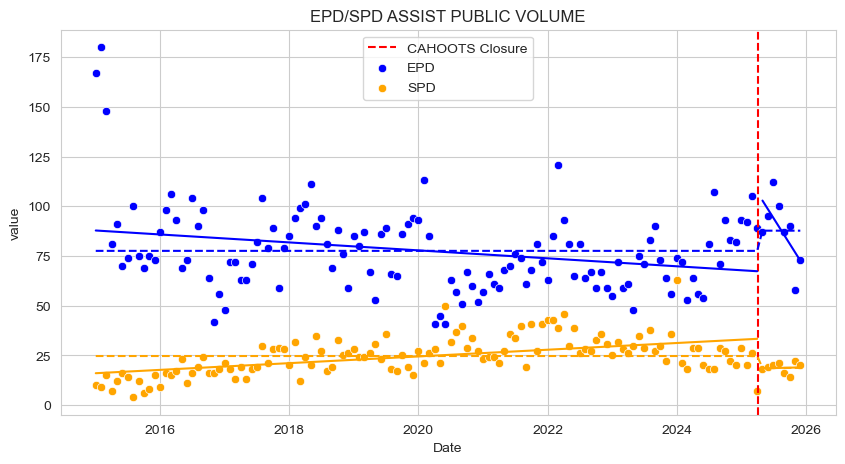

In [437]:
EPD_SPD_ASSIST_VOLUME = EPD_SPD_VOLUME_TYPES[EPD_SPD_VOLUME_TYPES["call type"] == "ASSIST PUBLIC"]
EPD_SPD_ASSIST_VOLUME
EPD_ASSIST_VOLUME_PRE, EPD_ASSIST_VOLUME_POST, SPD_ASSIST_VOLUME_PRE, SPD_ASSIST_VOLUME_POST = pre_post_split(EPD_SPD_ASSIST_VOLUME)
model_EPD_ASSIST_VOLUME_PRE, model_EPD_ASSIST_VOLUME_POST, model_SPD_ASSIST_VOLUME_PRE, model_SPD_ASSIST_VOLUME_POST = pre_post_predictions(EPD_ASSIST_VOLUME_PRE,
                                                                                                                                            EPD_ASSIST_VOLUME_POST,
                                                                                                                                            SPD_ASSIST_VOLUME_PRE,
                                                                                                                                            SPD_ASSIST_VOLUME_POST)
#DID ASSIST SUBJECT VOLUME

EPD_SPD_ASSIST_model = fit_DID(EPD_SPD_ASSIST_VOLUME, summary=True)
EPD_SPD_ASSIST_VOLUME["prediction"] = EPD_SPD_ASSIST_model.predict()
#calculate differences
EPD_SPD_ASSIST_VOLUME_RESULTS = EPD_SPD_ASSIST_VOLUME.groupby(["treated", "post", "variable"])["prediction"].value_counts().reset_index().drop(columns="count")
EPD_SPD_ASSIST_VOLUME_RESULTS = EPD_SPD_ASSIST_VOLUME_RESULTS.pivot_table(index="variable", columns="post", values="prediction")
EPD_SPD_ASSIST_VOLUME_RESULTS["difference"] = (EPD_SPD_ASSIST_VOLUME_RESULTS[0] - EPD_SPD_ASSIST_VOLUME_RESULTS[1]) * -1

EPD_SPD_ASSIST_VOLUME_RESULTS
plot_models(EPD_SPD_ASSIST_VOLUME,
            EPD_ASSIST_VOLUME_PRE,
            EPD_ASSIST_VOLUME_POST,
            SPD_ASSIST_VOLUME_PRE,
            SPD_ASSIST_VOLUME_POST, 
            "EPD",
            "SPD",
            "EPD/SPD ASSIST PUBLIC VOLUME")

In [456]:
EUG_TYPES

,yr,agency,service,inci_id,calltime,case_id,callsource,call type,closecode,closed_as,...,MCIT Departure Date & Time,Reason for Dispatch #2,Reason for Dispatch #3,Reason for Dispatch #4,Reason for Dispatch #5,Disposition,Minutes: Request → Dispatch,Minutes: Dispatch → Arrival,Minutes: Arrival → Engagement,Minutes: Arrival → Departure
0,2015.0,EPD,LAW,15000001,2015-01-01 00:00:00.000,NaN,SELF,OTHER,ASST,ASSISTED,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2015.0,EPD,LAW,15000002,2015-01-01 00:00:44.000,NaN,SELF,OTHER,RSLV,RESOLVED,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2015.0,CAHOOTS_EUG,LAW,15000003,2015-01-01 00:01:05.000,NaN,PHONE,CHECK WELFARE,ASST,ASSISTED,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2015.0,EPD,LAW,15000007,2015-01-01 00:03:16.000,NaN,W911,OTHER,PCHK,PATROL CHECK,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2015.0,EPD,LAW,15000010,2015-01-01 00:03:34.000,NaN,SELF,OTHER,ADVI,ADVISED,...,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3625,NaN,MCSLC_EUG,NaN,14295,NaN,NaN,NaN,OTHER,NaN,NaN,...,2025-11-20 06:02:00,Needing social/mental health services,NaN,NaN,NaN,Sobering/Detox Facility,109.0,10.0,0.0,40.0
3626,NaN,MCSLC_EUG,NaN,14404,NaN,NaN,NaN,OTHER,NaN,NaN,...,2025-09-07 00:57:00,Adult Social/interpersonal problems,Substance use,NaN,NaN,Sobering/Detox Facility,8.0,11.0,1.0,25.0
3627,NaN,MCSLC_EUG,NaN,14495,NaN,NaN,NaN,OTHER,NaN,NaN,...,2025-11-10 05:17:00,Difficulty functioning,Substance use,NaN,NaN,Sobering/Detox Facility,6.0,11.0,0.0,41.0
3628,NaN,MCSLC_EUG,NaN,14628,NaN,NaN,NaN,OTHER,NaN,NaN,...,2025-10-07 04:05:00,NaN,NaN,NaN,NaN,Sobering/Detox Facility,18.0,12.0,2.0,47.0


In [457]:
EUG_TYPES_VOLUME

,Date,call type,agency,calls,treated
0,2015-01-01,ASSIST PUBLIC,CAHOOTS_EUG,262,1
1,2015-01-01,ASSIST PUBLIC,EPD,167,1
2,2015-01-01,CHECK WELFARE,CAHOOTS_EUG,138,1
3,2015-01-01,CHECK WELFARE,EPD,191,1
4,2015-01-01,INTOXICATED SUBJECT,CAHOOTS_EUG,31,1
...,...,...,...,...,...
1574,2025-12-01,OTHER,EPD,7843,1
1575,2025-12-01,OTHER,MCSLC_EUG,138,1
1576,2025-12-01,SUICIDAL SUBJECT,EPD,89,1
1577,2025-12-01,SUICIDAL SUBJECT,MCSLC_EUG,11,1


---
---
---

# ALTERNATIVE VISUALIZATIONS

Text(0.5, 1.0, 'SPRINGFIELD CALL VOLUMES BY TYPE')

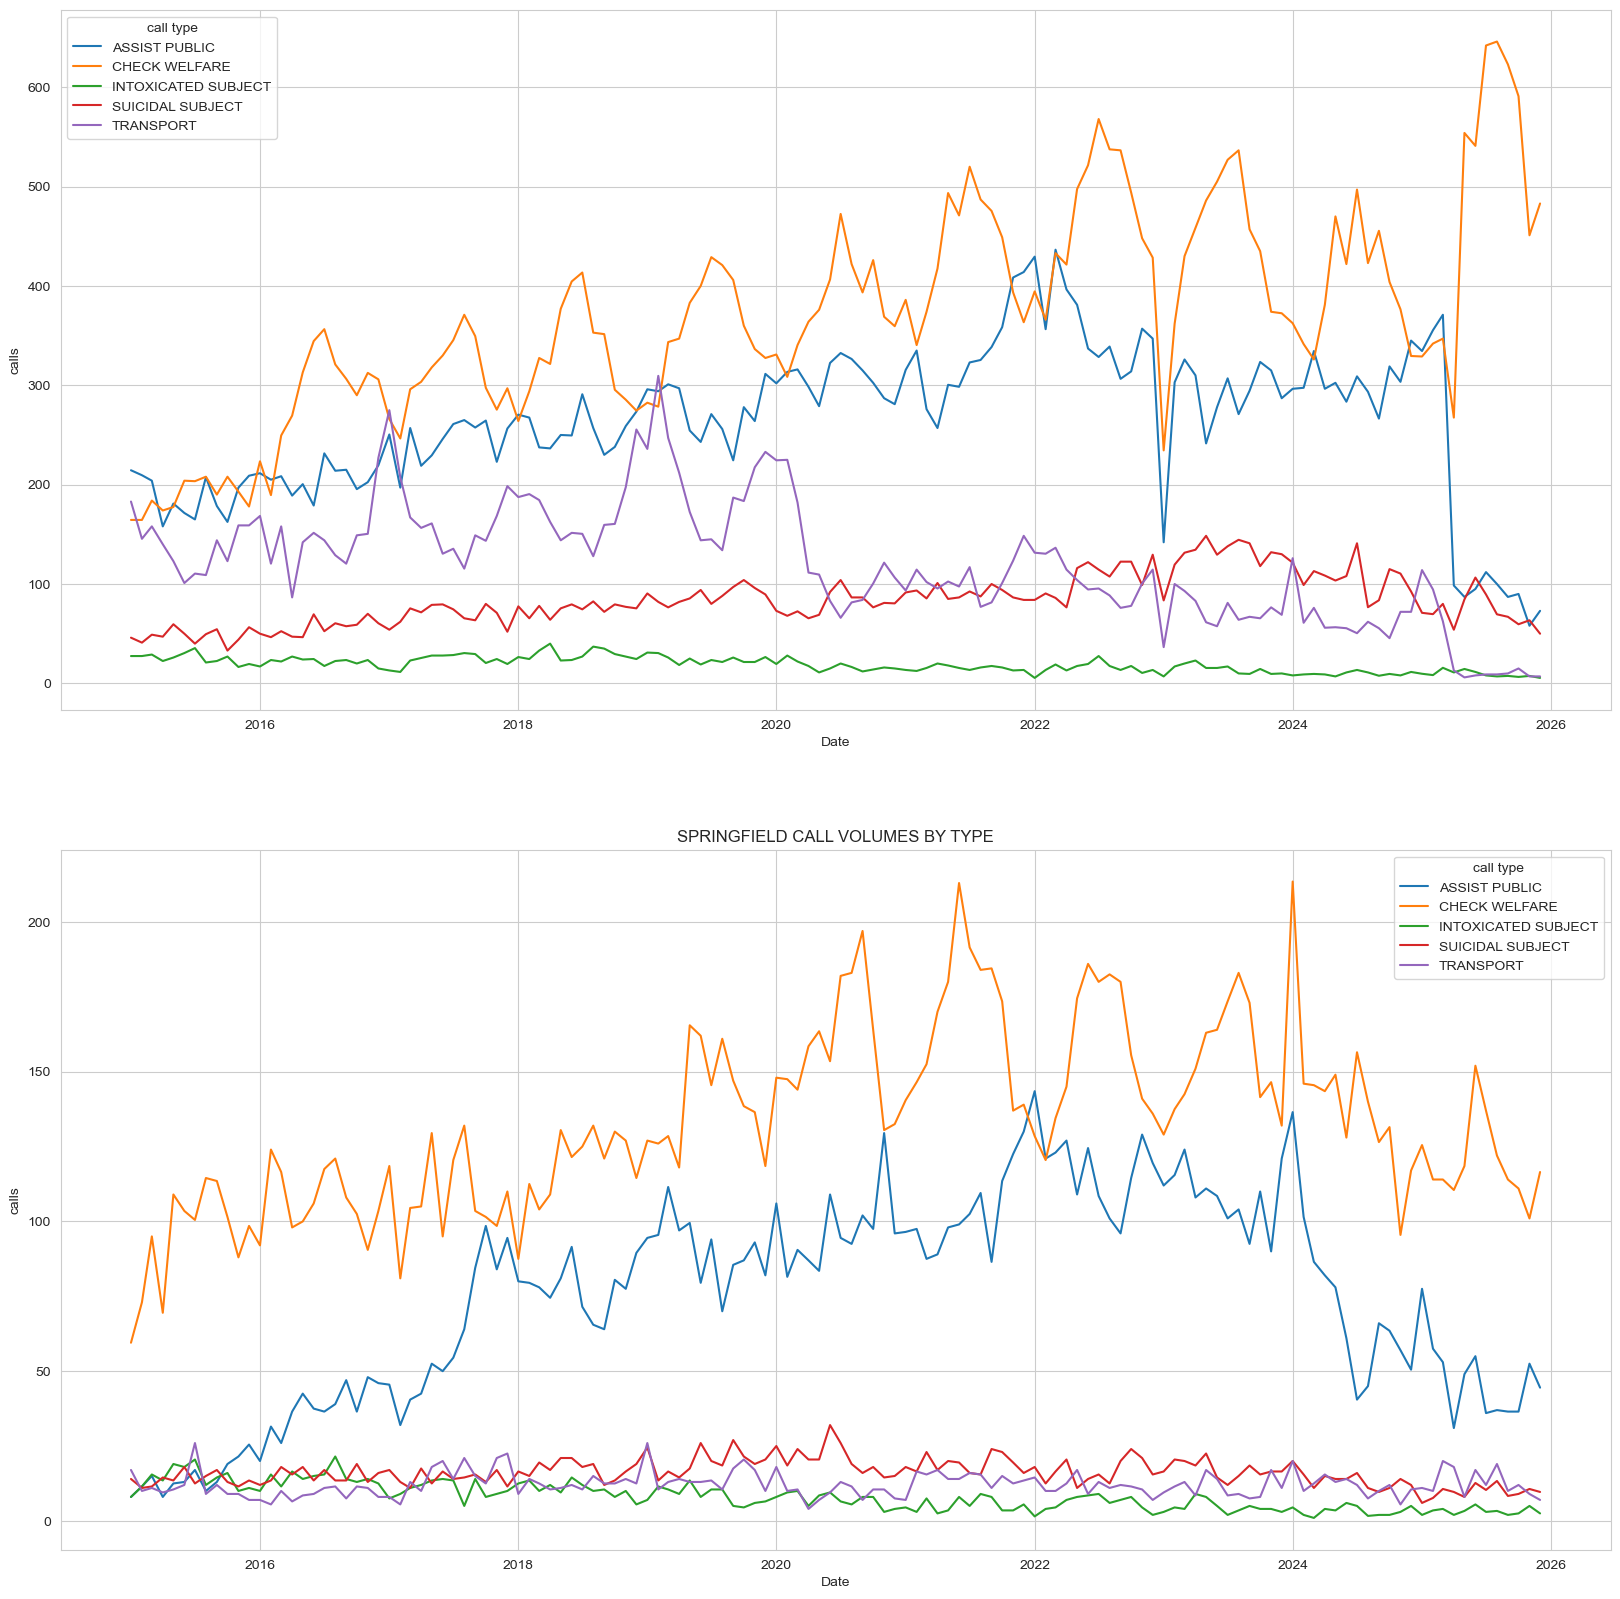

In [469]:
fig, axes = plt.subplots(2, 1, figsize=(20, 20))

sns.lineplot(data=EUG_TYPES_VOLUME[EUG_TYPES_VOLUME["call type"] != "OTHER"], x = "Date", y = "calls", hue = "call type", errorbar=None, ax = axes[0])
plt.title("EUGENE CALL VOLUMES BY TYPE")

sns.lineplot(data=SPR_TYPES_VOLUME[SPR_TYPES_VOLUME["call type"] != "OTHER"], x = "Date", y = "calls", hue = "call type", errorbar=None, ax = axes[1])
plt.title("SPRINGFIELD CALL VOLUMES BY TYPE")